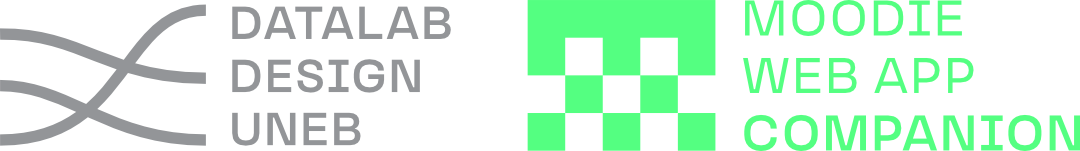

desenvolvido por [Elias Bitencourt](https://eliasbitencourt.com) | [Datalab Design](https://datalabdesign.org) - UNEB BAHIA BRASIL

##MOODIE WEB APP COMPANION • Módulo para extração e processamento de features de visão computacional para análise e exploração no [MOODIE WEB](https://www.moodie.datalabdesign.org)

MOODIE Web Companion é um notebook em Google Colab criado para preparar, anotar e exportar corpora de imagens para o MOODIE Web. Ele funciona como a etapa Python da pipeline: organiza projetos, descompacta imagens, associa metadados, permite amostragem, extrai features visuais com modelos de visão computacional e gera um pacote .moodie otimizado para análise no navegador.

O Companion existe porque a extração de embeddings com modelos de visão computacional ainda é pesada demais para ser executada integralmente no navegador. O MOODIE Web consegue operar com descritores superficiais extraídos do lado do cliente, como cor, brilho, contraste e bordas, mas análises mais densas exigem vetores pré-computados. O Companion produz esses vetores, compacta as matrizes quando necessário e exporta tudo em um formato que o MOODIE Web consegue ler diretamente.

O Companion não substitui o web app. Ele prepara o corpus para que a análise possa ser feita na interface web, com menor dependência de programação durante a etapa exploratória.

O MOODIE ainda está em fase de testes e com acesso restrito. Se você acredita que ele pode ser útil nas suas pesquisas, entre em contato com o autor.

##Como citar
Bitencourt, E. (2026). MOODIE: Modular Observational & Operational Design Image Explorer [Web app and Python companion]. Datalab Design, Universidade do Estado da Bahia. https://moodie.datalabdesign.org

[GITHUB](https://github.com/datalabdesign/moodie)

#BLOCO 01 Preparando o ambiente

In [ ]:
# @title Instalando dependências do MOODIE
# 13 março 2026
# 14 março 2026
#
# Mudanças desta versão
# - Corrige o problema de ambiente inconsistente que gerava erro em jax/jaxlib/flax
#   ("module 'jax._src.interpreters.pxla' has no attribute 'JitGlobalCppCacheKeys'").
# - Corrige a lógica de instalação: agora o módulo verifica PRESENÇA + VERSÃO,
#   em vez de checar apenas se o pacote existe.
# - Força ajuste conjunto de transformers + huggingface_hub para evitar incompatibilidades
#   e reduzir risco de warnings/deprecações que depois contaminam o módulo #07.
# - Remove pacotes opcionais conflitantes (jax, jaxlib, flax) antes do smoke test,
#   porque eles não são necessários para a pipeline principal do MOODIE e estavam
#   contaminando imports de tensorflow/keras/transformers em alguns ambientes.
# - Torna o smoke test mais seguro: não importa tensorflow/keras/flax nessa etapa.
# - Corrige um bug do logo: BytesIO agora é importado corretamente.
# - Corrige a lógica do botão: evita múltiplos callbacks ao reexecutar a célula.
# - Corrige o fluxo da barra de progresso para não “fingir” instalação em 0 segundos.
# - Limpa a interface final: exibe apenas
#     "MOODIE Instalado em ... "
#     "Tudo pronto, vamos começar!"
# - Remove prints de debug na interface, mas mantém robustez interna.
#
# Problemas endereçados
# 1) Presença de pacotes incompatíveis entre si, sobretudo jax/jaxlib/flax.
# 2) Ambiente preservando transformers/huggingface_hub fora da faixa prevista.
# 3) Import tests excessivamente agressivos para a etapa de instalação.
# 4) Falha silenciosa no carregamento do logo por ausência de BytesIO.
# 5) Instalação aparentemente “instantânea” sem execução real do pipeline.
# 6) Risco de warning/deprecação do huggingface_hub afetar os módulos posteriores.

#@markdown > Antes de começar, o MOODIE precisa instalar umas bibliotecas e preparar tudo para que sua experiência seja mais suave.<br> Aperta o botão e deixa que ele cuida de tudo pra você!

import os
import sys
import io
import re
import ast
import time
import base64
import logging
import warnings
import subprocess
import contextlib
import importlib
import importlib.util
from io import BytesIO
from datetime import datetime
from pathlib import Path  # [AJUSTE 15-04-2026] necessário porque Path é usado depois

import ast
import shutil
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
from PIL import Image

# [AJUSTE 14-03-2026] silenciamento base do ambiente
os.environ.update({
    "TF_CPP_MIN_LOG_LEVEL": "3",
    "TRANSFORMERS_VERBOSITY": "error",
    "HF_HUB_DISABLE_PROGRESS_BARS": "1",
    "NO_ALBUMENTATIONS_UPDATE": "1",
    "PIP_PROGRESS_BAR": "off",
    "TOKENIZERS_PARALLELISM": "false",
})

for _log in ("tensorflow", "transformers", "huggingface_hub", "jax", "flax"):
    logging.getLogger(_log).setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

LOGO_BASE64 = """
...
"""

try:
    _logo_bytes = base64.b64decode(LOGO_BASE64) if LOGO_BASE64.strip() else None
    GLOBAL_LOGO = Image.open(BytesIO(_logo_bytes)).convert("RGBA") if _logo_bytes else None
except Exception:
    GLOBAL_LOGO = None


def ensure_project_dir():
    global project_dir, project_name

    if 'project_dir' not in globals():
        # [AJUSTE 14-03-2026] mantém fallback, mas sem poluir interface do usuário
        project_dir = os.path.join(os.getcwd(), 'MOODIE_temp')

    # [AJUSTE 01-04-2026]
    # Estrutura persistente da pipeline:
    # - datasets/ guarda apenas o par ATIVO do projeto (PKL completo + CSV leve)
    # - datasets/backups/pkl guarda o PKL anterior à próxima modificação
    # - datasets/backups/csv guarda o CSV leve anterior à próxima modificação
    # - reports/ guarda relatórios TXT dos módulos
    # - imagens/ guarda o corpus visual do projeto
    base_dirs = [
        os.path.join(project_dir, "datasets"),
        os.path.join(project_dir, "datasets", "backups"),
        os.path.join(project_dir, "datasets", "backups", "pkl"),
        os.path.join(project_dir, "datasets", "backups", "csv"),
        os.path.join(project_dir, "reports"),
        os.path.join(project_dir, "imagens"),
    ]

    for sd in base_dirs:
        os.makedirs(sd, exist_ok=True)

    if 'project_name' not in globals() or not project_name:
        project_name = "moodie_temp"

# ---------------
# Helper de interface
# ---------------

UI_W = "700px"
LABEL_W = "700px"
FIELD_W = "700px"
BUTTON_W = "160px"

# [AJUSTE 15-04-2026] barra sempre ocupa a largura útil do painel
_BAR_W = widgets.Layout(width="calc(100% - 2px)")

# [AJUSTE 15-04-2026] bloco de status acima da barra, no mesmo padrão da pipeline
_STATUS_W = widgets.Layout(width="calc(100% - 2px)", margin="0 0 6px 0")


def field_block(label, widget, container_width=None):
    # [AJUSTE 15-04-2026]
    # Preserva atributos importantes do layout original do widget
    # e permite usar blocos compactos em grids.
    current_layout = getattr(widget, "layout", None)

    widget.description = ""
    widget.style = {"description_width": "0px"}

    current_width = getattr(current_layout, "width", None) if current_layout else None
    current_height = getattr(current_layout, "height", None) if current_layout else None
    current_display = getattr(current_layout, "display", None) if current_layout else None
    current_margin = getattr(current_layout, "margin", None) if current_layout else None
    current_min_height = getattr(current_layout, "min_height", None) if current_layout else None
    current_max_height = getattr(current_layout, "max_height", None) if current_layout else None

    widget.layout = widgets.Layout(
        width=current_width or "calc(100% - 2px)",
        height=current_height,
        min_height=current_min_height,
        max_height=current_max_height,
        display=current_display,
        margin=current_margin
    )

    return widgets.VBox(
        [
            widgets.HTML(f"<div style='font-weight:600; margin:0 0 6px 0;'>{label}</div>"),
            widget
        ],
        layout=widgets.Layout(
            width=container_width or UI_W,
            overflow="hidden",
            margin="0 0 12px 0"
        )
    )


def make_grid(items, columns=2, gap="12px 16px"):
    # [AJUSTE 15-04-2026]
    # Grid reutilizável para campos compactos.
    if isinstance(columns, int):
        template = " ".join(["1fr"] * max(1, columns))
    else:
        template = columns

    return widgets.GridBox(
        list(items),
        layout=widgets.Layout(
            width=UI_W,
            grid_template_columns=template,
            grid_gap=gap,
            align_items="flex-start"
        )
    )

# [AJUSTE 15-04-2026]
# Painel de progresso no padrão do restante da pipeline:
# texto do estágio em cima + barra abaixo
def build_install_progress_panel(total_steps: int):
    status_html = widgets.HTML(
        value="<div style='font-weight:600; margin:0 0 6px 0;'>Aguardando início…</div>",
        layout=_STATUS_W
    )

    progress_bar = widgets.IntProgress(
        value=0,
        min=0,
        max=max(int(total_steps), 1),
        description="",  # [AJUSTE 15-04-2026] sem texto embutido na barra
        style={"description_width": "0px"},
        layout=_BAR_W
    )
    progress_bar.bar_style = "info"

    panel = widgets.VBox(
        [status_html, progress_bar],
        layout=widgets.Layout(width=UI_W, overflow="hidden", margin="8px 0 0 0")
    )

    return status_html, progress_bar, panel


# [AJUSTE 15-04-2026]
# Atualiza o estado do progresso sem usar description da barra
def set_install_progress(status_html, progress_bar, step_index, total_steps, message,
                         *, done=False, error=False):
    step_index = max(0, min(int(step_index), int(total_steps)))

    status_html.value = (
        f"<div style='font-weight:600; margin:0 0 6px 0;'>"
        f"{message} <span style='font-weight:400; opacity:.75;'>({step_index}/{total_steps})</span>"
        f"</div>"
    )

    progress_bar.max = max(int(total_steps), 1)
    progress_bar.value = step_index

    if error:
        progress_bar.bar_style = "danger"
    elif done:
        progress_bar.bar_style = "success"
    else:
        progress_bar.bar_style = "info"

# [AJUSTE 15-04-2026]
# Helpers gerais reutilizáveis pela pipeline inteira

def make_output():
    return widgets.Output(
        layout=widgets.Layout(width=UI_W)
    )


def make_button(description, button_style="info", tooltip=None, width=None, disabled=False):
    return widgets.Button(
        description=description,
        button_style=button_style,
        tooltip=tooltip or "",
        disabled=disabled,
        layout=widgets.Layout(width=width or BUTTON_W)
    )


def make_action_row(*items):
    return widgets.HBox(
        list(items),
        layout=widgets.Layout(width=UI_W, margin="0 0 10px 0")
    )


def make_status_html(message):
    return widgets.HTML(
        value=f"<div style='font-weight:600; margin:0 0 6px 0;'>{message}</div>",
        layout=widgets.Layout(width="calc(100% - 2px)", margin="0 0 6px 0")
    )


def build_progress_panel(initial_message="Aguardando ação...", max_value=1.0, value=0.0):
    status_html = make_status_html(initial_message)

    progress_bar = widgets.FloatProgress(
        value=value,
        min=0.0,
        max=max_value,
        description="",
        style={"description_width": "0px"},
        layout=_BAR_W
    )
    progress_bar.bar_style = "info"
    progress_bar.layout.display = "none"

    panel = widgets.VBox(
        [status_html, progress_bar],
        layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 10px 0")
    )

    return status_html, progress_bar, panel


def set_progress_state(status_html, progress_bar, message=None, value=None,
                       *, show_bar=True, done=False, error=False):
    if message is not None:
        status_html.value = (
            f"<div style='font-weight:600; margin:0 0 6px 0;'>{message}</div>"
        )

    if value is not None:
        progress_bar.value = value

    progress_bar.layout.display = "" if show_bar else "none"

    if error:
        progress_bar.bar_style = "danger"
    elif done:
        progress_bar.bar_style = "success"
    else:
        progress_bar.bar_style = "info"


def set_block_visibility(widget, visible=True):
    widget.layout.display = "" if visible else "none"

# -----------------------------------------------------------------------------
# CACHE BASE DO MOODIE
# compatível com os módulos já existentes
# -----------------------------------------------------------------------------

_IMG_PAT = re.compile(r'^[^/\\<>:"|?*]+\.(?:jpe?g|png|gif|tiff?|bmp|webp)$', re.I)

if "_MOODIE_CACHE" not in globals() or not isinstance(globals().get("_MOODIE_CACHE"), dict):
    _MOODIE_CACHE = {
        "image_col": None,
        "image_cols": [],

        "visual_feature_cols": [],
        "text_feature_cols": [],
        "text_content_cols": [],

        "label_cols": [],
        "score_cols": [],
        "caption_cols": [],

        "all_feature_cols": [],
        "preview_exclude_cols": [],

        "dataset_path": None,
        "dataset_format": None,
        "dataset_preview_path": None,
        "dataset_base_name": None,

        # -------------------------------------------------
        # NOVO · cache para regimes analíticos
        # -------------------------------------------------
        "regime_rule_registry": [],
        "regime_atomic_cols": [],
        "regime_feature_cols": [],
        "regime_signature_cols": [],
        "context_feature_cols": [],
        "performance_feature_cols": [],
    }


def _moodie_unique_keep_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x is None:
            continue
        sx = str(x)
        if sx not in seen:
            seen.add(sx)
            out.append(x)
    return out


def _moodie_safe_sample(series, n=8):
    try:
        vals = series.dropna()
        if vals.empty:
            return []
        return vals.iloc[:n].tolist()
    except Exception:
        return []


def detect_image_columns(df: pd.DataFrame,
                         min_match_ratio: float = 0.90,
                         sample_size: int = 250) -> list[str]:
    if df is None or df.empty:
        return []

    good = []
    for col in df.columns:
        if not pd.api.types.is_string_dtype(df[col]):
            continue

        sample = df[col].dropna().astype(str).head(sample_size)
        if sample.empty or sample.nunique() < 1:
            continue

        bad = sample.str.contains(r'[/\\]|http|<|>', case=False, regex=True)
        if bad.any():
            continue

        if sample.str.match(_IMG_PAT).mean() >= min_match_ratio:
            good.append(col)

    return good


def _looks_like_image_name_value(s: str) -> bool:
    if not isinstance(s, str):
        return False
    s = str(s).strip().lower()
    s = s.split("?")[0].split("#")[0]
    return s.endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))


def _is_visual_feature_colname(col_name: str) -> bool:
    col = str(col_name).strip()

    known_models = {
        "MobileNetV2", "VGG16", "ResNet50", "InceptionV3",
        "EffNetB0", "ViT16_1k", "ViT_GPT2", "BLIP"
    }

    if any(col == f"{m}_features" for m in known_models):
        return True

    if col.endswith("_features") and not col.endswith("_content_features"):
        return True

    return False


def _is_text_feature_colname(col_name: str) -> bool:
    col = str(col_name).strip()

    pattern_native = re.compile(
        r"^(MiniLMMultilingual|MPNetMultilingual|E5Multilingual|BGEM3)_.+_content_features$"
    )
    if pattern_native.match(col):
        return True

    if col.endswith("_content_features"):
        return True

    return False


def _is_text_content_colname(col_name: str) -> bool:
    return str(col_name).strip().endswith("_content_text")


def _is_label_colname(col_name: str) -> bool:
    lc = str(col_name).strip().lower()
    return lc.endswith("_labels") or lc in {"gender_label", "age_label", "age_class"}


def _is_score_colname(col_name: str) -> bool:
    return str(col_name).strip().lower().endswith("_scores")


def _is_caption_colname(col_name: str) -> bool:
    lc = str(col_name).strip().lower()
    if "caption" in lc:
        return True
    if lc in {"vit_gpt2_labels", "blip_labels"}:
        return True
    return False


def _looks_like_numeric_vector_value(v):
    if v is None:
        return False

    if isinstance(v, (list, tuple, pd.Series)):
        try:
            arr = np.asarray(v, dtype=float)
            return arr.ndim == 1 and arr.size >= 8
        except Exception:
            return False

    if isinstance(v, np.ndarray):
        try:
            arr = np.asarray(v, dtype=float)
            return arr.ndim == 1 and arr.size >= 8
        except Exception:
            return False

    if isinstance(v, str):
        s = v.strip()
        if not s or not (s.startswith("[") and s.endswith("]")):
            return False
        try:
            parsed = ast.literal_eval(s)
            arr = np.asarray(parsed, dtype=float)
            return arr.ndim == 1 and arr.size >= 8
        except Exception:
            return False

    return False


def _detect_vectorish_columns_from_content(df: pd.DataFrame, candidate_cols=None, sample_n=6, min_hits=3):
    if df is None or df.empty:
        return []

    cols = list(candidate_cols) if candidate_cols is not None else list(df.columns)
    detected = []

    for c in cols:
        samples = _moodie_safe_sample(df[c], n=sample_n)
        if not samples:
            continue

        hits = 0
        for v in samples:
            if _looks_like_numeric_vector_value(v):
                hits += 1

        if hits >= min_hits:
            detected.append(c)

    return detected


def _sync_moodie_cache_globals():
    global _MOODIE_IMG_COLS, _MOODIE_VISUAL_FEATURE_COLS
    global _MOODIE_TEXT_FEATURE_COLS, _MOODIE_TEXT_CONTENT_COLS
    global _MOODIE_REGIME_FEATURE_COLS, _MOODIE_REGIME_SIGNATURE_COLS
    global _MOODIE_CONTEXT_FEATURE_COLS, _MOODIE_PERFORMANCE_FEATURE_COLS
    global _MOODIE_REGIME_ATOMIC_COLS, _MOODIE_REGIME_RULES

    _MOODIE_IMG_COLS = list(_MOODIE_CACHE.get("image_cols", []))
    _MOODIE_VISUAL_FEATURE_COLS = list(_MOODIE_CACHE.get("visual_feature_cols", []))
    _MOODIE_TEXT_FEATURE_COLS = list(_MOODIE_CACHE.get("text_feature_cols", []))
    _MOODIE_TEXT_CONTENT_COLS = list(_MOODIE_CACHE.get("text_content_cols", []))

    # -------------------------------------------------
    # NOVO · sincronização dos caches de regime
    # -------------------------------------------------
    _MOODIE_REGIME_ATOMIC_COLS = list(_MOODIE_CACHE.get("regime_atomic_cols", []))
    _MOODIE_REGIME_FEATURE_COLS = list(_MOODIE_CACHE.get("regime_feature_cols", []))
    _MOODIE_REGIME_SIGNATURE_COLS = list(_MOODIE_CACHE.get("regime_signature_cols", []))
    _MOODIE_CONTEXT_FEATURE_COLS = list(_MOODIE_CACHE.get("context_feature_cols", []))
    _MOODIE_PERFORMANCE_FEATURE_COLS = list(_MOODIE_CACHE.get("performance_feature_cols", []))

    globals()["global_image_col"] = _MOODIE_CACHE.get("image_col", None)

    if _MOODIE_CACHE.get("dataset_path") is not None:
        globals()["global_dataset_path"] = _MOODIE_CACHE["dataset_path"]

    if _MOODIE_CACHE.get("dataset_format") is not None:
        globals()["global_dataset_format"] = _MOODIE_CACHE["dataset_format"]

    globals()["global_dataset_preview_path"] = _MOODIE_CACHE.get("dataset_preview_path", None)
    globals()["global_dataset_base_name"] = _MOODIE_CACHE.get("dataset_base_name", None)

    # -------------------------------------------------
    # NOVO · expõe regras e listas para os módulos
    # -------------------------------------------------
    globals()["_MOODIE_REGIME_RULES"] = list(_MOODIE_CACHE.get("regime_rule_registry", []))
    globals()["global_context_feature_cols"] = list(_MOODIE_CACHE.get("context_feature_cols", []))
    globals()["global_performance_feature_cols"] = list(_MOODIE_CACHE.get("performance_feature_cols", []))

def ensure_moodie_cache(df=None, refresh=False):
    global _MOODIE_CACHE

    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        _sync_moodie_cache_globals()
        return _MOODIE_CACHE

    cols = list(df.columns)

    # imagem
    detected_img_cols = []

    try:
        detected_img_cols = detect_image_columns(df) or []
    except Exception:
        detected_img_cols = []

    if not detected_img_cols:
        for c in df.columns:
            smp = df[c].dropna().astype(str).head(20)
            if smp.empty:
                continue
            if smp.map(_looks_like_image_name_value).any():
                detected_img_cols.append(c)

    if not detected_img_cols:
        try:
            obj_cols = list(df.select_dtypes(include=["object", "string"]).columns)
            detected_img_cols = obj_cols if obj_cols else list(df.columns)
        except Exception:
            detected_img_cols = list(df.columns)

    detected_img_cols = _moodie_unique_keep_order(detected_img_cols)

    prev_image_col = _MOODIE_CACHE.get("image_col", None)
    current_global_image_col = globals().get("global_image_col", None)

    if prev_image_col in detected_img_cols:
        image_col = prev_image_col
    elif current_global_image_col in detected_img_cols:
        image_col = current_global_image_col
    elif "image_name_original" in detected_img_cols:
        image_col = "image_name_original"
    elif "image_name" in detected_img_cols:
        image_col = "image_name"
    elif "image" in detected_img_cols:
        image_col = "image"
    else:
        image_col = detected_img_cols[0] if detected_img_cols else None

    # -------------------------------------------------
    # features já existentes por nome
    # -------------------------------------------------
    visual_feature_cols = [c for c in cols if _is_visual_feature_colname(c)]
    text_feature_cols = [c for c in cols if _is_text_feature_colname(c)]
    text_content_cols = [c for c in cols if _is_text_content_colname(c)]
    label_cols = [c for c in cols if _is_label_colname(c)]
    score_cols = [c for c in cols if _is_score_colname(c)]
    caption_cols = [c for c in cols if _is_caption_colname(c)]

    # -------------------------------------------------
    # NOVO · colunas de regime por padrão de nome
    # -------------------------------------------------
    regime_atomic_cols = [c for c in cols if str(c).startswith("prep__")]
    regime_feature_cols = [c for c in cols if re.match(r"^regime__.+__features$", str(c))]
    regime_signature_cols = [c for c in cols if re.match(r"^regime__.+__signature$", str(c))]

    context_feature_cols = [
        c for c in regime_feature_cols
        if str(c).startswith("regime__contexto__")
    ]

    performance_feature_cols = [
        c for c in regime_feature_cols
        if str(c).startswith("regime__desempenho__")
    ]

    # fallback heurístico leve para features externas
    already_features = (
        set(visual_feature_cols)
        | set(text_feature_cols)
        | set(regime_feature_cols)
    )
    candidate_probe = [c for c in cols if c not in already_features]

    heuristic_features = _detect_vectorish_columns_from_content(
        df=df,
        candidate_cols=candidate_probe,
        sample_n=6,
        min_hits=3
    )

    for c in heuristic_features:
        lc = str(c).lower()
        if c in regime_feature_cols:
            continue
        if ("content" in lc) or ("text" in lc):
            text_feature_cols.append(c)
        elif str(c).startswith("regime__") and str(c).endswith("__features"):
            regime_feature_cols.append(c)
        else:
            visual_feature_cols.append(c)

    visual_feature_cols = _moodie_unique_keep_order(visual_feature_cols)
    text_feature_cols = _moodie_unique_keep_order(text_feature_cols)
    text_content_cols = _moodie_unique_keep_order(text_content_cols)
    label_cols = _moodie_unique_keep_order(label_cols)
    score_cols = _moodie_unique_keep_order(score_cols)
    caption_cols = _moodie_unique_keep_order(caption_cols)

    regime_atomic_cols = _moodie_unique_keep_order(regime_atomic_cols)
    regime_feature_cols = _moodie_unique_keep_order(regime_feature_cols)
    regime_signature_cols = _moodie_unique_keep_order(regime_signature_cols)
    context_feature_cols = _moodie_unique_keep_order(context_feature_cols)
    performance_feature_cols = _moodie_unique_keep_order(performance_feature_cols)

    all_feature_cols = _moodie_unique_keep_order(
        visual_feature_cols + text_feature_cols + regime_feature_cols
    )

    preview_exclude_cols = list(all_feature_cols)

    _MOODIE_CACHE["image_col"] = image_col
    _MOODIE_CACHE["image_cols"] = detected_img_cols

    _MOODIE_CACHE["visual_feature_cols"] = visual_feature_cols
    _MOODIE_CACHE["text_feature_cols"] = text_feature_cols
    _MOODIE_CACHE["text_content_cols"] = text_content_cols

    _MOODIE_CACHE["label_cols"] = label_cols
    _MOODIE_CACHE["score_cols"] = score_cols
    _MOODIE_CACHE["caption_cols"] = caption_cols

    _MOODIE_CACHE["regime_atomic_cols"] = regime_atomic_cols
    _MOODIE_CACHE["regime_feature_cols"] = regime_feature_cols
    _MOODIE_CACHE["regime_signature_cols"] = regime_signature_cols
    _MOODIE_CACHE["context_feature_cols"] = context_feature_cols
    _MOODIE_CACHE["performance_feature_cols"] = performance_feature_cols

    _MOODIE_CACHE["all_feature_cols"] = all_feature_cols
    _MOODIE_CACHE["preview_exclude_cols"] = preview_exclude_cols

    _sync_moodie_cache_globals()
    return _MOODIE_CACHE


def refresh_moodie_cache(df=None):
    return ensure_moodie_cache(df=df, refresh=True)


def moodie_cache_img_cols_from_global_df():
    if "global_df" not in globals():
        raise RuntimeError("global_df ainda não foi definido para detectar colunas de imagem.")

    cache = refresh_moodie_cache(global_df)
    return list(cache.get("image_cols", []))


def ensure_moodie_image_cache(df=None):
    cache = ensure_moodie_cache(df=df, refresh=False)
    return list(cache.get("image_cols", []))


def ensure_moodie_visual_feature_cache(df=None):
    cache = ensure_moodie_cache(df=df, refresh=False)
    return list(cache.get("visual_feature_cols", []))


def ensure_moodie_text_feature_cache(df=None):
    cache = ensure_moodie_cache(df=df, refresh=False)
    return list(cache.get("text_feature_cols", []))


def ensure_moodie_text_content_cache(df=None):
    cache = ensure_moodie_cache(df=df, refresh=False)
    return list(cache.get("text_content_cols", []))


def moodie_register_image_column(image_col, candidate_cols=None):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    if image_col is not None:
        _MOODIE_CACHE["image_col"] = image_col

    if candidate_cols is not None:
        _MOODIE_CACHE["image_cols"] = _moodie_unique_keep_order(list(candidate_cols))
    else:
        current = list(_MOODIE_CACHE.get("image_cols", []))
        if image_col is not None:
            _MOODIE_CACHE["image_cols"] = _moodie_unique_keep_order([image_col] + current)

    _sync_moodie_cache_globals()
    return list(_MOODIE_CACHE.get("image_cols", []))


def moodie_register_visual_feature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("visual_feature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["visual_feature_cols"] = merged
    _MOODIE_CACHE["all_feature_cols"] = _moodie_unique_keep_order(
        merged + list(_MOODIE_CACHE.get("text_feature_cols", []))
    )
    _MOODIE_CACHE["preview_exclude_cols"] = list(_MOODIE_CACHE["all_feature_cols"])

    _sync_moodie_cache_globals()
    return merged


def moodie_register_text_feature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("text_feature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["text_feature_cols"] = merged
    _MOODIE_CACHE["all_feature_cols"] = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("visual_feature_cols", [])) + merged
    )
    _MOODIE_CACHE["preview_exclude_cols"] = list(_MOODIE_CACHE["all_feature_cols"])

    _sync_moodie_cache_globals()
    return merged


def moodie_register_text_content_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("text_content_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["text_content_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_label_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("label_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["label_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_score_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("score_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["score_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_caption_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("caption_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["caption_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_dataset_paths(dataset_path=None, dataset_format=None, preview_path=None, base_name=None):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    if dataset_path is not None:
        _MOODIE_CACHE["dataset_path"] = dataset_path
    if dataset_format is not None:
        _MOODIE_CACHE["dataset_format"] = dataset_format

    _MOODIE_CACHE["dataset_preview_path"] = preview_path

    if base_name is not None:
        _MOODIE_CACHE["dataset_base_name"] = base_name

    _sync_moodie_cache_globals()
    return {
        "dataset_path": _MOODIE_CACHE.get("dataset_path"),
        "dataset_format": _MOODIE_CACHE.get("dataset_format"),
        "dataset_preview_path": _MOODIE_CACHE.get("dataset_preview_path"),
        "dataset_base_name": _MOODIE_CACHE.get("dataset_base_name"),
    }


def moodie_get_image_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("image_cols", []))


def moodie_get_main_image_column(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return cache.get("image_col", None)


def moodie_get_visual_feature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("visual_feature_cols", []))


def moodie_get_text_feature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("text_feature_cols", []))


def moodie_get_text_content_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("text_content_cols", []))

#NOVO

def moodie_register_regime_atomic_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("regime_atomic_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["regime_atomic_cols"] = merged
    _sync_moodie_cache_globals()
    return merged


def moodie_register_regime_feature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("regime_feature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["regime_feature_cols"] = merged

    _MOODIE_CACHE["all_feature_cols"] = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("visual_feature_cols", []))
        + list(_MOODIE_CACHE.get("text_feature_cols", []))
        + merged
    )
    _MOODIE_CACHE["preview_exclude_cols"] = list(_MOODIE_CACHE["all_feature_cols"])

    _sync_moodie_cache_globals()
    return merged


def moodie_register_regime_signature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("regime_signature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["regime_signature_cols"] = merged
    _sync_moodie_cache_globals()
    return merged


def moodie_register_context_feature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("context_feature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["context_feature_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_performance_feature_columns(cols):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    merged = _moodie_unique_keep_order(
        list(_MOODIE_CACHE.get("performance_feature_cols", [])) + list(cols or [])
    )
    _MOODIE_CACHE["performance_feature_cols"] = merged

    _sync_moodie_cache_globals()
    return merged


def moodie_register_regime_rules(rules):
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)

    _MOODIE_CACHE["regime_rule_registry"] = copy.deepcopy(list(rules or []))
    _sync_moodie_cache_globals()
    return list(_MOODIE_CACHE.get("regime_rule_registry", []))


def moodie_get_regime_atomic_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("regime_atomic_cols", []))


def moodie_get_regime_feature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("regime_feature_cols", []))


def moodie_get_regime_signature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("regime_signature_cols", []))


def moodie_get_context_feature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("context_feature_cols", []))


def moodie_get_performance_feature_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("performance_feature_cols", []))


def moodie_get_regime_rules():
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)
    return list(_MOODIE_CACHE.get("regime_rule_registry", []))

#FIM novo


def moodie_get_preview_exclude_columns(df=None, refresh=False):
    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    return list(cache.get("preview_exclude_cols", []))


def moodie_get_preview_columns(df=None, refresh=False, keep_first_image_col=True):
    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return []

    cache = refresh_moodie_cache(df) if refresh else ensure_moodie_cache(df)
    exclude = set(cache.get("preview_exclude_cols", []))
    img_col = cache.get("image_col", None)

    out = []
    if keep_first_image_col and img_col in df.columns:
        out.append(img_col)

    for c in df.columns:
        if c == img_col:
            continue
        if c in exclude:
            continue
        out.append(c)

    return out


def moodie_build_preview_df(df=None, refresh=False, keep_first_image_col=True):
    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return pd.DataFrame()

    preview_cols = moodie_get_preview_columns(
        df=df,
        refresh=refresh,
        keep_first_image_col=keep_first_image_col
    )

    if not preview_cols:
        return df.head(0).copy()

    return df[preview_cols].copy()

def _moodie_safe_slug(name: str) -> str:
    name = str(name or "dataset").strip()
    name = re.sub(r"\s+", "_", name)
    name = re.sub(r"[^A-Za-z0-9_\-]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name or "dataset"

MOODIE_MODULE_NAMES = {
    "mod_03": "set_directories",
    "mod_04": "image_extraction",
    "mod_05": "import",
    "mod_06": "corpus_sampling",
    "mod_07": "color_map",
    "mod_08": "json_enrich",
    "mod_09": "img_features",
    "mod_10": "txt_features",
    "mod_11": "corpus_deduplication",
    "mod_12": "contextual_features",
    "mod_13": "corpus_viz",
    "mod_14": "recomendation",
}


def moodie_get_module_name(module_key=None, fallback=None):
    """
    Resolve o nome legível do módulo a partir de uma chave central.
    """
    if module_key and module_key in MOODIE_MODULE_NAMES:
        return MOODIE_MODULE_NAMES[module_key]
    return fallback or "Modulo"


def moodie_make_dataset_base_name(module_key=None, module_name=None, project_name=None):
    """
    Gera o nome-base padronizado do dataset ativo:

    dataset_<project_name>_<modulo>
    """
    proj = _moodie_safe_slug(project_name or globals().get("project_name", "projeto"))
    mod_name = moodie_get_module_name(module_key=module_key, fallback=module_name)
    mod_slug = _moodie_safe_slug(mod_name)

    return f"dataset_{proj}_{mod_slug}"


def moodie_make_report_header(module_key=None, module_name=None, project_name=None, project_dir=None):
    """
    Cabeçalho padronizado para todos os reports.
    """
    mod_name = moodie_get_module_name(module_key=module_key, fallback=module_name)
    proj_name = project_name or globals().get("project_name", "(sem nome)")
    proj_dir = project_dir or globals().get("project_dir", None)

    lines = [
        f"MOODIE Report - Modulo {mod_name}",
        f"Projeto: {proj_name}",
    ]

    if proj_dir:
        lines.append(f"Diretório: {moodie_short_dir(proj_dir)}")

    lines.append("")
    return "\n".join(lines)

def moodie_get_active_dataset_paths():
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)
    return {
        "dataset_path": _MOODIE_CACHE.get("dataset_path"),
        "dataset_format": _MOODIE_CACHE.get("dataset_format"),
        "dataset_preview_path": _MOODIE_CACHE.get("dataset_preview_path"),
        "dataset_base_name": _MOODIE_CACHE.get("dataset_base_name"),
    }


def moodie_backup_active_dataset_pair(reason=None):
    """
    [AJUSTE 01-04-2026]
    Move o par ATIVO imediatamente anterior para backup:
    - PKL completo em datasets/backups/pkl/
    - CSV leve em datasets/backups/csv/

    Importante:
    - move, não copia
    - libera datasets/ para manter apenas o par mais recente
    """
    ensure_project_dir()

    active = moodie_get_active_dataset_paths()
    current_pkl = active.get("dataset_path")
    current_csv = active.get("dataset_preview_path")
    current_name = active.get("dataset_base_name") or Path(str(current_pkl or current_csv or "dataset")).stem

    timestamp = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")
    suffix = _moodie_safe_slug(reason) if reason else "backup"

    pkl_backup_path = None
    csv_backup_path = None

    pkl_backup_dir = os.path.join(project_dir, "datasets", "backups", "pkl")
    csv_backup_dir = os.path.join(project_dir, "datasets", "backups", "csv")

    os.makedirs(pkl_backup_dir, exist_ok=True)
    os.makedirs(csv_backup_dir, exist_ok=True)

    if current_pkl and os.path.exists(current_pkl):
        pkl_backup_path = os.path.join(
            pkl_backup_dir,
            f"{_moodie_safe_slug(current_name)}__{suffix}__{timestamp}.pkl"
        )
        shutil.move(current_pkl, pkl_backup_path)

    if current_csv and os.path.exists(current_csv):
        csv_backup_path = os.path.join(
            csv_backup_dir,
            f"{_moodie_safe_slug(current_name)}__{suffix}__{timestamp}.csv"
        )
        shutil.move(current_csv, csv_backup_path)

    return {
        "backup_pkl_path": pkl_backup_path,
        "backup_csv_path": csv_backup_path,
    }

def moodie_short_path(path, project_dir=None, project_name=None):
    """
    Encurta um caminho absoluto para exibição amigável na interface.

    Exemplo:
    /.../Teste_Moodie_Texto_5/datasets/dataset_x.pkl
    -> Teste_Moodie_Texto_5/datasets/dataset_x.pkl
    """
    if not path:
        return None

    try:
        path = os.path.abspath(str(path))
    except Exception:
        return str(path)

    proj_dir = project_dir or globals().get("project_dir", None)

    if proj_dir:
        try:
            proj_dir = os.path.abspath(str(proj_dir))
            rel = os.path.relpath(path, proj_dir)
            if not rel.startswith(".."):
                root_name = os.path.basename(proj_dir.rstrip("/\\"))
                return f"{root_name}/{rel}" if rel != "." else f"{root_name}/"
        except Exception:
            pass

    return os.path.basename(path)


def moodie_short_dir(path, project_dir=None, project_name=None):
    """
    Variante para diretórios, garantindo barra final na exibição.
    """
    short = moodie_short_path(path, project_dir=project_dir, project_name=project_name)
    if not short:
        return None
    return short.rstrip("/\\") + "/"


def moodie_print_project_context(project_name=None, project_dir=None):
    """
    Bloco curto e padronizado para outputs de módulos.
    """
    proj_name = project_name or globals().get("project_name", "(sem nome)")
    proj_dir = project_dir or globals().get("project_dir", None)

    print(f"Projeto: {proj_name}")
    if proj_dir:
        print(f"Diretório: {moodie_short_dir(proj_dir)}")


def moodie_write_module_report(module_name=None, report_text=None, report_dir=None,
                               file_stem=None, module_key=None):
    """
    Escreve relatório TXT do módulo com padrão:

    report_<modulo>_<projeto>_<timestamp>.txt
    """
    ensure_project_dir()

    if not report_text:
        return None

    resolved_module_name = moodie_get_module_name(module_key=module_key, fallback=module_name)
    module_slug = _moodie_safe_slug(resolved_module_name)
    project_slug = _moodie_safe_slug(globals().get("project_name", "projeto"))
    timestamp = datetime.now().strftime("%d_%m_%Y_%H_%M_%S")

    target_dir = report_dir or os.path.join(project_dir, "reports")
    os.makedirs(target_dir, exist_ok=True)

    path = os.path.join(
        target_dir,
        f"report_{module_slug}_{project_slug}_{timestamp}.txt"
    )

    full_text = report_text
    if not str(report_text).startswith("MOODIE Report - Modulo "):
        header = moodie_make_report_header(
            module_key=module_key,
            module_name=resolved_module_name
        )
        full_text = header + str(report_text)

    with open(path, "w", encoding="utf-8") as f:
        f.write(str(full_text))

    return path

def moodie_save_module_package(df=None, package_dir=None, base_name=None, image_col=None,
                               save_pkl=True, save_preview_csv=True, report_text=None,
                               module_name=None):
    """
    [AJUSTE 01-04-2026]
    Salva um pacote autocontido de módulo:
    - PKL completo
    - CSV leve
    - report TXT opcional
    Não altera o dataset ativo do projeto.
    """
    ensure_project_dir()

    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return {
            "pkl_path": None,
            "csv_path": None,
            "report_path": None,
        }

    refresh_moodie_cache(df)

    safe_name = _moodie_safe_slug(base_name or globals().get("project_name", "moodie_temp"))
    target_dir = package_dir or os.path.join(project_dir, "reports")
    os.makedirs(target_dir, exist_ok=True)

    pkl_path = None
    csv_path = None
    report_path = None

    if save_pkl:
        pkl_path = os.path.join(target_dir, f"{safe_name}.pkl")
        df.to_pickle(pkl_path)

    if save_preview_csv:
        preview_df = moodie_build_preview_df(df=df, refresh=False, keep_first_image_col=True)

        if image_col and image_col in df.columns and image_col not in preview_df.columns:
            preview_df = df[[image_col] + [c for c in preview_df.columns if c != image_col]].copy()

        csv_path = os.path.join(target_dir, f"{safe_name}.csv")
        preview_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    if report_text:
        report_path = moodie_write_module_report(
            module_name=module_name or "Modulo",
            report_text=report_text,
            report_dir=target_dir
        )

    return {
        "pkl_path": pkl_path,
        "csv_path": csv_path,
        "report_path": report_path,
    }

def moodie_save_dataset_bundle(df=None, base_name=None, save_pkl=True, save_preview_csv=True,
                               backup_current=True, backup_reason=None, report_text=None,
                               report_dir=None, module_name=None, module_key=None):
    """
    Persistência central do estado ATIVO da pipeline:
    - antes de sobrescrever, move o par anterior para backup
    - salva o novo PKL completo em datasets/<nome>.pkl
    - salva o novo CSV leve em datasets/<nome>.csv
    - mantém em datasets/ apenas o par ativo do projeto
    - atualiza cache e globais com os caminhos ativos
    - opcionalmente grava relatório TXT do módulo
    """
    ensure_project_dir()

    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return {
            "dataset_path": None,
            "dataset_format": None,
            "dataset_preview_path": None,
            "backup_pkl_path": None,
            "backup_csv_path": None,
            "report_path": None,
        }

    refresh_moodie_cache(df)

    safe_name = _moodie_safe_slug(
        base_name or moodie_make_dataset_base_name(
            module_key=module_key,
            module_name=module_name
        )
    )

    datasets_dir = os.path.join(project_dir, "datasets")
    os.makedirs(datasets_dir, exist_ok=True)

    backup_info = {
        "backup_pkl_path": None,
        "backup_csv_path": None,
    }

    if backup_current:
        backup_info = moodie_backup_active_dataset_pair(reason=backup_reason or safe_name)

    dataset_path = None
    dataset_format = None
    dataset_preview_path = None

    if save_pkl:
        dataset_path = os.path.join(datasets_dir, f"{safe_name}.pkl")
        df.to_pickle(dataset_path)
        dataset_format = "pkl"

    if save_preview_csv:
        preview_df = moodie_build_preview_df(df=df, refresh=False, keep_first_image_col=True)
        dataset_preview_path = os.path.join(datasets_dir, f"{safe_name}.csv")
        preview_df.to_csv(dataset_preview_path, index=False, encoding="utf-8-sig")

    if not save_pkl and save_preview_csv:
        dataset_path = dataset_preview_path
        dataset_format = "csv"

    moodie_register_dataset_paths(
        dataset_path=dataset_path,
        dataset_format=dataset_format,
        preview_path=dataset_preview_path,
        base_name=safe_name
    )

    report_path = None
    if report_text:
        report_path = moodie_write_module_report(
            module_name=module_name,
            module_key=module_key,
            report_text=report_text,
            report_dir=report_dir
        )

    return {
        "dataset_path": dataset_path,
        "dataset_format": dataset_format,
        "dataset_preview_path": dataset_preview_path,
        "backup_pkl_path": backup_info.get("backup_pkl_path"),
        "backup_csv_path": backup_info.get("backup_csv_path"),
        "report_path": report_path,
    }

def moodie_finalize_dataset_update(df=None, image_col=None, visual_feature_cols=None,
                                   text_feature_cols=None, text_content_cols=None,
                                   label_cols=None, score_cols=None, caption_cols=None,
                                   base_name=None, save_pkl=True, save_preview_csv=True,
                                   backup_current=True, backup_reason=None,
                                   report_text=None, report_dir=None,
                                   module_name=None, module_key=None):
    """
    Função de alto nível para os módulos da pipeline:
    - atualiza global_df
    - sincroniza cache de imagem/features/rótulos
    - salva o novo estado ativo do projeto
    - opcionalmente faz backup do estado anterior
    - opcionalmente grava relatório TXT do módulo
    """
    if df is None:
        df = globals().get("global_df", None)

    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return {
            "dataset_path": None,
            "dataset_format": None,
            "dataset_preview_path": None,
            "backup_pkl_path": None,
            "backup_csv_path": None,
            "report_path": None,
        }

    globals()["global_df"] = df

    refresh_moodie_cache(df)

    if image_col is not None:
        moodie_register_image_column(image_col)

    if visual_feature_cols:
        moodie_register_visual_feature_columns(visual_feature_cols)

    if text_feature_cols:
        moodie_register_text_feature_columns(text_feature_cols)

    if text_content_cols:
        moodie_register_text_content_columns(text_content_cols)

    if label_cols:
        moodie_register_label_columns(label_cols)

    if score_cols:
        moodie_register_score_columns(score_cols)

    if caption_cols:
        moodie_register_caption_columns(caption_cols)

    refresh_moodie_cache(globals()["global_df"])

    return moodie_save_dataset_bundle(
        df=globals()["global_df"],
        base_name=base_name,
        save_pkl=save_pkl,
        save_preview_csv=save_preview_csv,
        backup_current=backup_current,
        backup_reason=backup_reason or base_name,
        report_text=report_text,
        report_dir=report_dir,
        module_name=module_name,
        module_key=module_key
    )

def moodie_debug_cache():
    ensure_moodie_cache(globals().get("global_df", None), refresh=False)
    return {
        "image_col": _MOODIE_CACHE.get("image_col"),
        "image_cols": list(_MOODIE_CACHE.get("image_cols", [])),
        "visual_feature_cols": list(_MOODIE_CACHE.get("visual_feature_cols", [])),
        "text_feature_cols": list(_MOODIE_CACHE.get("text_feature_cols", [])),
        "text_content_cols": list(_MOODIE_CACHE.get("text_content_cols", [])),
        "regime_atomic_cols": list(_MOODIE_CACHE.get("regime_atomic_cols", [])),
        "regime_feature_cols": list(_MOODIE_CACHE.get("regime_feature_cols", [])),
        "regime_signature_cols": list(_MOODIE_CACHE.get("regime_signature_cols", [])),
        "context_feature_cols": list(_MOODIE_CACHE.get("context_feature_cols", [])),
        "performance_feature_cols": list(_MOODIE_CACHE.get("performance_feature_cols", [])),
        "dataset_path": _MOODIE_CACHE.get("dataset_path"),
        "dataset_format": _MOODIE_CACHE.get("dataset_format"),
        "dataset_preview_path": _MOODIE_CACHE.get("dataset_preview_path"),
        "dataset_base_name": _MOODIE_CACHE.get("dataset_base_name"),
        "regime_rule_registry": copy.deepcopy(_MOODIE_CACHE.get("regime_rule_registry", [])),
    }


def _pkg_version(dist_name: str):
    try:
        from importlib.metadata import version
        return version(dist_name)
    except Exception:
        return None


def _invalidate_import_caches():
    # [AJUSTE 14-03-2026] importante após uninstall/install no mesmo runtime
    importlib.invalidate_caches()


def _purge_modules(prefixes):
    # [AJUSTE 14-03-2026] remove módulos já carregados em memória para evitar estado fantasma
    to_delete = []
    for name in list(sys.modules.keys()):
        for p in prefixes:
            if name == p or name.startswith(f"{p}."):
                to_delete.append(name)
                break
    for name in to_delete:
        sys.modules.pop(name, None)


def _module_exists(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


def _ensure_packaging():
    # [AJUSTE 14-03-2026] isolamento da dependência de versionamento
    try:
        from packaging.requirements import Requirement
        from packaging.version import Version
        return Requirement, Version
    except Exception:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "packaging"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        from packaging.requirements import Requirement
        from packaging.version import Version
        return Requirement, Version


def _need_install(spec: str, import_name: str):
    Requirement, Version = _ensure_packaging()

    req = Requirement(spec)
    dist_name = req.name
    mod_ok = importlib.util.find_spec(import_name) is not None
    ver = _pkg_version(dist_name)

    if (not mod_ok) or (ver is None):
        return True

    try:
        return Version(ver) not in req.specifier
    except Exception:
        return True


def _pip_install(specs, *, upgrade=True):
    if not specs:
        return
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "--prefer-binary"]
    if upgrade:
        cmd.append("--upgrade")
    cmd.extend(specs)
    subprocess.check_call(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    _invalidate_import_caches()


def _pip_uninstall(pkgs):
    if not pkgs:
        return
    cmd = [sys.executable, "-m", "pip", "uninstall", "-y", *pkgs]
    subprocess.check_call(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    _invalidate_import_caches()


def choose_torch_spec() -> list[str]:
    # [AJUSTE 14-03-2026] mantém a lógica, mas evita reinstalar desnecessariamente
    found = importlib.util.find_spec("torch")
    if found:
        try:
            import torch
            _, Version = _ensure_packaging()
            if Version(torch.__version__.split("+")[0]) >= Version("2.1.0"):
                return []
        except Exception:
            pass

    try:
        subprocess.check_output(["nvidia-smi", "-L"], stderr=subprocess.DEVNULL)
        has_cuda = True
    except Exception:
        has_cuda = False

    extra_index = "https://download.pytorch.org/whl/torch_stable.html"

    if has_cuda:
        return ["torch==2.1.2+cu118", "torchvision==0.16.2+cu118", "-f", extra_index]
    return ["torch==2.1.2+cpu", "torchvision==0.16.2+cpu", "-f", extra_index]


# [AJUSTE 16-03-2026]
# - Adiciona dependências para o módulo 08 de embeddings textuais.
# - sentencepiece é necessária para tokenizers/modelos multilíngues usados por E5/BGE e derivados.
# - protobuf reduz risco de falhas em tokenizers/configs em alguns ambientes do Colab.
# - safetensors melhora compatibilidade no carregamento de checkpoints do Hugging Face.
PACKAGE_SPECS = [
    {"spec": "ImageHash>=4.3,<5", "import_name": "imagehash"},
    {"spec": "colorthief>=0.2,<0.3", "import_name": "colorthief"},
    {"spec": "pillow>=10,<12", "import_name": "PIL"},
    {"spec": "distinctipy>=1.3,<2", "import_name": "distinctipy"},
    {"spec": "bokeh>=3,<4", "import_name": "bokeh"},
    {"spec": "umap-learn>=0.5,<0.6", "import_name": "umap"},
    {"spec": "hdbscan>=0.8,<0.9", "import_name": "hdbscan"},
    {"spec": "rasterfairy>=1.0,<2", "import_name": "rasterfairy"},
    {"spec": "timm==0.9.12", "import_name": "timm"},
    {"spec": "transformers>=4.40,<4.41", "import_name": "transformers"},
    {"spec": "huggingface_hub>=0.23,<1.0", "import_name": "huggingface_hub"},
    {"spec": "sentencepiece>=0.1.99,<0.3", "import_name": "sentencepiece"},
    {"spec": "protobuf>=4.25,<6", "import_name": "google.protobuf"},
    {"spec": "safetensors>=0.4,<0.6", "import_name": "safetensors"},
    {"spec": "insightface==0.7.3", "import_name": "insightface"},
    {"spec": "opencv-python>=4.8,<5", "import_name": "cv2"},
    {"spec": "onnxruntime>=1.17,<2", "import_name": "onnxruntime"},
    {"spec": "deepface>=0.0.91,<1.0", "import_name": "deepface"},
]

CONFLICT_PKGS = ["jax", "jaxlib", "flax"]


def _needs_hf_alignment():
    # [AJUSTE 14-03-2026] verificação explícita do par transformers + huggingface_hub
    return (
        _need_install("transformers>=4.40,<4.41", "transformers")
        or _need_install("huggingface_hub>=0.23,<1.0", "huggingface_hub")
    )


def _collect_install_specs():
    specs = []

    torch_specs = choose_torch_spec()
    if torch_specs:
        specs.extend(torch_specs)

    # [AJUSTE 14-03-2026] se HF estiver desalinhado, força reinstalação do par
    hf_force = _needs_hf_alignment()

    for item in PACKAGE_SPECS:
        if item["import_name"] in ("transformers", "huggingface_hub"):
            if hf_force:
                specs.append(item["spec"])
            continue

        if _need_install(item["spec"], item["import_name"]):
            specs.append(item["spec"])

    # insere o par HF no fim para consolidar o ambiente
    if hf_force:
        specs.extend([
            "huggingface_hub>=0.23,<1.0",
            "transformers>=4.40,<4.41",
        ])

    # [AJUSTE 14-03-2026] remove duplicatas preservando ordem
    seen = set()
    uniq = []
    for s in specs:
        if s not in seen:
            uniq.append(s)
            seen.add(s)
    return uniq


def _cleanup_conflicts():
    installed = [p for p in CONFLICT_PKGS if _module_exists(p)]
    if installed:
        _pip_uninstall(installed)
        _purge_modules(CONFLICT_PKGS)


def _reset_hf_modules_if_needed():
    # [AJUSTE 14-03-2026] se o par HF será reinstalado, limpamos os módulos já carregados
    if _needs_hf_alignment():
        _purge_modules(["transformers", "huggingface_hub"])


def _smoke_imports():
    # [AJUSTE 14-03-2026] smoke test leve e silencioso
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        import imagehash
        import colorthief
        import umap
        import hdbscan
        import distinctipy
        import bokeh
        import timm
        import transformers
        import onnxruntime
        import cv2
        import deepface
        import PIL
        import torch


def _preload_light_configs():
    # [AJUSTE 14-03-2026] preload leve e protegido
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        try:
            from transformers import AutoConfig
            _ = AutoConfig.from_pretrained(
                "nlpconnect/vit-gpt2-image-captioning",
                trust_remote_code=False
            )
        except Exception:
            pass


# [AJUSTE 15-04-2026] botão com largura padronizada
install_btn = widgets.Button(
    description="Instalar MOODIE",
    button_style="success",
    layout=widgets.Layout(width=BUTTON_W)
)

# [AJUSTE 15-04-2026] output com largura da interface
out = widgets.Output(
    layout=widgets.Layout(width=UI_W)
)

# [AJUSTE 15-04-2026] painel geral no mesmo enquadramento visual dos módulos
install_ui = widgets.VBox(
    [
        widgets.HBox(
            [install_btn],
            layout=widgets.Layout(width=UI_W, margin="0 0 10px 0")
        ),
        out
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(install_ui)

def on_install(_):
    # [AJUSTE 15-04-2026]
    # - separa status textual da barra
    # - mantém a barra no padrão visual da pipeline
    # - evita description embutido na IntProgress
    # - informa o estágio atual sem deformar a barra

    t0 = time.perf_counter()
    install_btn.disabled = True
    out.clear_output(wait=True)

    steps = [
        "Limpando conflitos…",
        "Ajustando ambiente…",
        "Instalando dependências…",
        "Testando bibliotecas…",
        "Carregando configs leves…",
        "Preparando diretórios…",
        "Inicializando cache…",
    ]
    total_steps = len(steps)

    try:
        specs_to_install = _collect_install_specs()

        status_html, progress_bar, progress_panel = build_install_progress_panel(total_steps)

        with out:
            display(progress_panel)

        set_install_progress(
            status_html, progress_bar, 0, total_steps,
            "Iniciando instalação…"
        )

        # Etapa 1
        set_install_progress(
            status_html, progress_bar, 0, total_steps,
            steps[0]
        )
        try:
            _cleanup_conflicts()
        except Exception:
            pass
        set_install_progress(
            status_html, progress_bar, 1, total_steps,
            steps[0]
        )

        # Etapa 2
        set_install_progress(
            status_html, progress_bar, 1, total_steps,
            steps[1]
        )
        _reset_hf_modules_if_needed()
        set_install_progress(
            status_html, progress_bar, 2, total_steps,
            steps[1]
        )

        # Etapa 3
        if specs_to_install:
            install_msg = f"{steps[2]} ({len(specs_to_install)} pacote(s))"
        else:
            install_msg = "Dependências já estão alinhadas…"

        set_install_progress(
            status_html, progress_bar, 2, total_steps,
            install_msg
        )

        if specs_to_install:
            _pip_install(specs_to_install, upgrade=True)
            _purge_modules([
                "transformers", "huggingface_hub",
                "jax", "jaxlib", "flax"
            ])
            _invalidate_import_caches()

        set_install_progress(
            status_html, progress_bar, 3, total_steps,
            steps[2]
        )

        # Etapa 4
        set_install_progress(
            status_html, progress_bar, 3, total_steps,
            steps[3]
        )
        _smoke_imports()
        set_install_progress(
            status_html, progress_bar, 4, total_steps,
            steps[3]
        )

        # Etapa 5
        set_install_progress(
            status_html, progress_bar, 4, total_steps,
            steps[4]
        )
        _preload_light_configs()
        set_install_progress(
            status_html, progress_bar, 5, total_steps,
            steps[4]
        )

        # Etapa 6
        set_install_progress(
            status_html, progress_bar, 5, total_steps,
            steps[5]
        )
        ensure_project_dir()
        set_install_progress(
            status_html, progress_bar, 6, total_steps,
            steps[5]
        )

        # Etapa 7
        set_install_progress(
            status_html, progress_bar, 6, total_steps,
            steps[6]
        )
        ensure_moodie_cache(df=globals().get("global_df", None), refresh=False)
        set_install_progress(
            status_html, progress_bar, 7, total_steps,
            "Concluído",
            done=True
        )

        elapsed = time.perf_counter() - t0
        mins = int(elapsed // 60)
        secs = int(elapsed % 60)

        out.clear_output(wait=True)
        with out:
            print(f"MOODIE Instalado em {mins} min {secs} s.")
            print("Tudo pronto, vamos começar!")

    except Exception as e:
        out.clear_output(wait=True)
        with out:
            print("A instalação do MOODIE não foi concluída.")
            print(f"Erro: {e}")
        raise

    finally:
        install_btn.disabled = False

# [AJUSTE 14-03-2026] evita callbacks duplicados ao reexecutar a célula
try:
    install_btn._click_handlers.callbacks = []
except Exception:
    pass

install_btn.on_click(on_install)

In [ ]:
# @title Conectando ao Google Drive (Opcional)
#@markdown > O MOODIE funciona melhor se você estiver conectado ao seu google drive.<br>
#@markdown Isso evita que arquivos muito pesados tornem o processo ainda mais lento.<br>
#@markdown Mas, se você preferir trabalhar com os arquivos fazendo upload, também é uma opção.
#@markdown É só seguir para o módulo 03.

import os
import importlib
import ipywidgets as widgets
from IPython.display import display, clear_output

# [AJUSTE 15-04-2026]
# Mantém compatibilidade com o padrão visual criado no módulo #01
try:
    UI_W
except NameError:
    UI_W = "700px"

try:
    BUTTON_W
except NameError:
    BUTTON_W = "160px"

# [AJUSTE 15-04-2026]
# Flag global de conexão
drive_connected = globals().get("drive_connected", False)

# [AJUSTE 15-04-2026]
# Área de status e output com largura padronizada
connect_status = widgets.HTML(
    value="<div style='font-weight:600; margin:0 0 6px 0;'>Drive ainda não conectado.</div>",
    layout=widgets.Layout(width="calc(100% - 2px)", margin="0 0 6px 0")
)

connect_output = widgets.Output(
    layout=widgets.Layout(width=UI_W)
)

# [AJUSTE 15-04-2026]
# Botão no mesmo padrão dimensional da pipeline
connect_button = widgets.Button(
    description="Conectar Google Drive",
    button_style="info",
    layout=widgets.Layout(width=BUTTON_W)
)

# [AJUSTE 15-04-2026]
# Se já estiver conectado em reexecuções, preserva o estado visual
if drive_connected:
    connect_button.description = "Drive Conectado"
    connect_button.button_style = "success"
    connect_button.disabled = True
    connect_status.value = "<div style='font-weight:600; margin:0 0 6px 0;'>Google Drive já está conectado.</div>"


def on_connect_clicked(_):
    global drive_connected

    connect_button.disabled = True
    connect_button.description = "Conectando..."
    connect_button.button_style = "warning"
    connect_status.value = (
        "<div style='font-weight:600; margin:0 0 6px 0;'>"
        "Aguardando autenticação do Google Drive…"
        "</div>"
    )

    connect_output.clear_output(wait=True)

    with connect_output:
        if importlib.util.find_spec("google.colab") is None:
            print("Este notebook não está rodando no Google Colab. Pule esta etapa.")
            connect_button.description = "Conectar Google Drive"
            connect_button.button_style = "info"
            connect_button.disabled = False
            connect_status.value = (
                "<div style='font-weight:600; margin:0 0 6px 0;'>"
                "Google Colab não detectado. Você pode seguir para o módulo 03."
                "</div>"
            )
            return

        try:
            from google.colab import drive

            # [AJUSTE 15-04-2026]
            # force_remount=False evita remontagem desnecessária em boa parte dos casos
            drive.mount("/content/drive", force_remount=False)

            drive_connected = True
            globals()["drive_connected"] = True

            print("Google Drive conectado com sucesso.")

            connect_button.description = "Drive Conectado"
            connect_button.button_style = "success"
            connect_button.disabled = True
            connect_status.value = (
                "<div style='font-weight:600; margin:0 0 6px 0;'>"
                "Google Drive conectado com sucesso."
                "</div>"
            )

        except Exception as e:
            print(f"Erro ao conectar o Google Drive: {e}")

            connect_button.description = "Conectar Google Drive"
            connect_button.button_style = "info"
            connect_button.disabled = False
            connect_status.value = (
                "<div style='font-weight:600; margin:0 0 6px 0;'>"
                "Não foi possível concluir a conexão com o Google Drive."
                "</div>"
            )


# [AJUSTE 15-04-2026]
# Evita callbacks duplicados ao reexecutar a célula
try:
    connect_button._click_handlers.callbacks = []
except Exception:
    pass

connect_button.on_click(on_connect_clicked)

# [AJUSTE 15-04-2026]
# Painel visual alinhado ao padrão do módulo #01
drive_ui = widgets.VBox(
    [
        widgets.HBox(
            [connect_button],
            layout=widgets.Layout(width=UI_W, margin="0 0 10px 0")
        ),
        connect_status,
        connect_output
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(drive_ui)

In [ ]:
# @title Criando diretórios de trabalho (Opcional)
#@markdown >Agora vamos começar a organizar nosso ambiente de trabalho!
#@markdown >1. Se você já se conectou ao google drive, marque SIM. Se prefere trabalhar fazendo uploads, marque NÃO.
#@markdown 2. Se você já tem uma pasta no seu drive ou no ambiente do Google Colab, marque "Diretório existente". Mas se quiser começar um novo projeto, marque "Novo diretório".
#@markdown 3. Se você marcou "Novo diretório", basta informar o nome da pasta onde quer salvar os trabalhos e indicar o caminho dessa pasta.
#@markdown 4. Agora digite o nome do seu projeto. Ele será usado para customizar os nomes dos arquivos que o MOODIE vai salvar.
#@markdown 5. Escreva uma nota mental sobre o que é o seu projeto. O MOODIE salvará um arquivo de registro com as informações organizadas.

import os
import json
import time
import glob
import ipywidgets as widgets
from IPython.display import display, clear_output

if 'drive_connected' not in globals():
    drive_connected = False

# -----------------------------------------------------------------------------
# CACHE GLOBAL DO PROJETO
# -----------------------------------------------------------------------------

def _sort_files_by_mtime_desc(paths):
    paths = [p for p in paths if os.path.exists(p)]
    return sorted(paths, key=lambda p: os.path.getmtime(p), reverse=True)


def _resolve_active_dataset_pair(datasets_dir):
    """
    [AJUSTE 01-04-2026]
    Resolve o par ativo do projeto dentro de datasets/.
    Regra:
    - datasets/ deve conter apenas o par ativo do projeto
    - se houver PKL e CSV homônimos, eles formam o par preferencial
    - se houver apenas um dos dois, ele ainda pode ser tratado como ativo
    """
    if not os.path.isdir(datasets_dir):
        return {
            "active_dataset_path": None,
            "active_preview_path": None,
            "active_dataset_format": None,
            "active_dataset_base_name": None,
            "active_pkl_files": [],
            "active_csv_files": [],
            "json_files": [],
        }

    active_pkl_files = _sort_files_by_mtime_desc(glob.glob(os.path.join(datasets_dir, "*.pkl")))
    active_csv_files = _sort_files_by_mtime_desc(glob.glob(os.path.join(datasets_dir, "*.csv")))
    json_files = _sort_files_by_mtime_desc(glob.glob(os.path.join(datasets_dir, "*.json")))

    pkl_map = {os.path.splitext(os.path.basename(p))[0]: p for p in active_pkl_files}
    csv_map = {os.path.splitext(os.path.basename(p))[0]: p for p in active_csv_files}

    common_bases = []
    for base in pkl_map.keys():
        if base in csv_map:
            try:
                mtime = max(os.path.getmtime(pkl_map[base]), os.path.getmtime(csv_map[base]))
            except Exception:
                mtime = 0
            common_bases.append((base, mtime))

    common_bases = sorted(common_bases, key=lambda x: x[1], reverse=True)

    active_dataset_path = None
    active_preview_path = None
    active_dataset_format = None
    active_dataset_base_name = None

    if common_bases:
        active_dataset_base_name = common_bases[0][0]
        active_dataset_path = pkl_map[active_dataset_base_name]
        active_preview_path = csv_map[active_dataset_base_name]
        active_dataset_format = "pkl"
    elif active_pkl_files:
        active_dataset_path = active_pkl_files[0]
        active_dataset_base_name = os.path.splitext(os.path.basename(active_dataset_path))[0]
        active_preview_path = csv_map.get(active_dataset_base_name, None)
        active_dataset_format = "pkl"
    elif active_csv_files:
        active_preview_path = active_csv_files[0]
        active_dataset_base_name = os.path.splitext(os.path.basename(active_preview_path))[0]
        active_dataset_path = pkl_map.get(active_dataset_base_name, None)
        active_dataset_format = "pkl" if active_dataset_path else "csv"

    return {
        "active_dataset_path": active_dataset_path,
        "active_preview_path": active_preview_path,
        "active_dataset_format": active_dataset_format,
        "active_dataset_base_name": active_dataset_base_name,
        "active_pkl_files": active_pkl_files,
        "active_csv_files": active_csv_files,
        "json_files": json_files,
    }


def _scan_project_assets(project_folder):
    """
    [AJUSTE 01-04-2026]
    Varre o projeto segundo a arquitetura atual da pipeline:
    - datasets/ guarda apenas o par ativo (PKL completo + CSV leve)
    - datasets/backups/pkl guarda PKLs anteriores
    - datasets/backups/csv guarda CSVs leves anteriores
    """
    datasets_dir = os.path.join(project_folder, "datasets")
    backups_dir = os.path.join(datasets_dir, "backups")
    backups_pkl_dir = os.path.join(backups_dir, "pkl")
    backups_csv_dir = os.path.join(backups_dir, "csv")
    images_dir = os.path.join(project_folder, "imagens")
    reports_dir = os.path.join(project_folder, "reports")

    resolved_active = _resolve_active_dataset_pair(datasets_dir)

    backup_csv_files = []
    backup_pkl_files = []
    image_files = []

    if os.path.isdir(backups_csv_dir):
        backup_csv_files.extend(glob.glob(os.path.join(backups_csv_dir, "*.csv")))

    if os.path.isdir(backups_pkl_dir):
        backup_pkl_files.extend(glob.glob(os.path.join(backups_pkl_dir, "*.pkl")))

    if os.path.isdir(images_dir):
        for root, _, files in os.walk(images_dir):
            for f in files:
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif")):
                    image_files.append(os.path.join(root, f))

    backup_csv_files = _sort_files_by_mtime_desc(backup_csv_files)
    backup_pkl_files = _sort_files_by_mtime_desc(backup_pkl_files)
    image_files = _sort_files_by_mtime_desc(image_files)

    return {
        "project_dir": project_folder,
        "images_dir": images_dir,
        "datasets_dir": datasets_dir,
        "backups_dir": backups_dir,
        "backups_pkl_dir": backups_pkl_dir,
        "backups_csv_dir": backups_csv_dir,
        "reports_dir": reports_dir,
        "active_csv_files": resolved_active["active_csv_files"],
        "active_pkl_files": resolved_active["active_pkl_files"],
        "backup_csv_files": backup_csv_files,
        "backup_pkl_files": backup_pkl_files,
        "json_files": resolved_active["json_files"],
        "image_files": image_files,
        "active_dataset_path": resolved_active["active_dataset_path"],
        "active_preview_path": resolved_active["active_preview_path"],
        "active_dataset_format": resolved_active["active_dataset_format"],
        "active_dataset_base_name": resolved_active["active_dataset_base_name"],
        "has_images_dir": os.path.isdir(images_dir),
        "has_dataset_dir": os.path.isdir(datasets_dir),
        "has_images": len(image_files) > 0,
        "has_csv": len(resolved_active["active_csv_files"]) > 0,
        "has_json": len(resolved_active["json_files"]) > 0,
        "has_pkl": len(resolved_active["active_pkl_files"]) > 0,
        "has_backups_csv": len(backup_csv_files) > 0,
        "has_backups_pkl": len(backup_pkl_files) > 0,
        "last_scan_ts": time.strftime("%d_%m_%Y_%H_%M_%S"),
    }

def _update_project_cache(project_folder, project_name="", project_description=""):
    global MOODIE_PROJECT_CACHE

    cache = _scan_project_assets(project_folder)
    cache["project_name"] = project_name
    cache["project_description"] = project_description

    MOODIE_PROJECT_CACHE = cache

    globals()["project_dir"] = cache["project_dir"]
    globals()["project_name"] = project_name if project_name else globals().get("project_name", "")
    globals()["global_project_cache"] = cache

    return cache

def _save_project_cache_file(project_folder, cache):
    """
    Salva um JSON interno de cache do projeto para reuso e auditoria leve.
    """
    try:
        reports_dir = os.path.join(project_folder, "reports")
        os.makedirs(reports_dir, exist_ok=True)
        cache_path = os.path.join(reports_dir, "_moodie_project_cache.json")
        with open(cache_path, "w", encoding="utf-8") as f:
            json.dump(cache, f, ensure_ascii=False, indent=2)
        globals()["global_project_cache_path"] = cache_path
        return cache_path
    except Exception:
        return None

def _load_project_cache_file(project_folder):
    """
    [AJUSTE 01-04-2026]
    Lê o cache interno do projeto, se existir.
    """
    cache_path = os.path.join(project_folder, "reports", "_moodie_project_cache.json")
    if not os.path.exists(cache_path):
        return None

    try:
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

#Novos helpers [15.04.2026]

def _load_project_readme_metadata(project_folder):
    """
    Tenta recuperar nome e descrição do projeto a partir do README do projeto.
    Prioriza o README mais recente com prefixo README_.
    """
    pattern = os.path.join(project_folder, "README_*.txt")
    readmes = _sort_files_by_mtime_desc(glob.glob(pattern))

    if not readmes:
        return None

    readme_path = readmes[0]

    try:
        with open(readme_path, "r", encoding="utf-8") as f:
            text = f.read()
    except Exception:
        return None

    project_name = ""
    project_description = ""

    for line in text.splitlines():
        line_stripped = line.strip()

        if line_stripped.startswith("Nome do Projeto:"):
            project_name = line_stripped.split("Nome do Projeto:", 1)[1].strip()

        elif line_stripped.startswith("Descrição do Projeto:"):
            project_description = line_stripped.split("Descrição do Projeto:", 1)[1].strip()

    return {
        "project_name": project_name,
        "project_description": project_description,
        "readme_path": readme_path
    }


def _resolve_existing_project_metadata(project_folder):
    """
    Resolve metadados do projeto existente com esta prioridade:
    1. cache interno do projeto
    2. README do projeto
    3. nome da pasta como fallback
    """
    cache_data = _load_project_cache_file(project_folder)
    readme_data = _load_project_readme_metadata(project_folder)

    project_name = ""
    project_description = ""

    if cache_data:
        project_name = str(cache_data.get("project_name", "") or "").strip()
        project_description = str(cache_data.get("project_description", "") or "").strip()

    if not project_name and readme_data:
        project_name = str(readme_data.get("project_name", "") or "").strip()

    if not project_description and readme_data:
        project_description = str(readme_data.get("project_description", "") or "").strip()

    if not project_name:
        project_name = os.path.basename(os.path.abspath(project_folder.rstrip("/\\")))

    return {
        "project_name": project_name,
        "project_description": project_description,
        "cache_data": cache_data,
        "readme_data": readme_data
    }



def _sync_project_cache_to_pipeline(cache):
    """
    [AJUSTE 01-04-2026]
    Sincroniza o cache do projeto com as globais da pipeline.
    """
    if not cache:
        return

    globals()["global_project_cache"] = cache
    globals()["global_project_cache_path"] = os.path.join(
        cache["reports_dir"],
        "_moodie_project_cache.json"
    )

    if cache.get("project_dir"):
        globals()["project_dir"] = cache["project_dir"]

    if cache.get("project_name"):
        globals()["project_name"] = cache["project_name"]

    if cache.get("project_description") is not None:
        globals()["global_project_description"] = cache["project_description"]

    try:
        moodie_register_dataset_paths(
            dataset_path=cache.get("active_dataset_path"),
            dataset_format=cache.get("active_dataset_format"),
            preview_path=cache.get("active_preview_path"),
            base_name=cache.get("active_dataset_base_name"),
        )
    except Exception:
        if cache.get("active_dataset_path") is not None:
            globals()["global_dataset_path"] = cache["active_dataset_path"]
        if cache.get("active_dataset_format") is not None:
            globals()["global_dataset_format"] = cache["active_dataset_format"]
        globals()["global_dataset_preview_path"] = cache.get("active_preview_path", None)
        globals()["global_dataset_base_name"] = cache.get("active_dataset_base_name", None)


def refresh_project_cache():
    """
    [AJUSTE 01-04-2026]
    Revarre o projeto corrente, atualiza o cache global
    e sincroniza imediatamente com a pipeline.
    """
    if "project_dir" not in globals() or not project_dir or not os.path.isdir(project_dir):
        return None

    cache = _update_project_cache(
        project_folder=project_dir,
        project_name=globals().get("project_name", ""),
        project_description=globals().get("global_project_description", "")
    )
    _save_project_cache_file(project_dir, cache)
    _sync_project_cache_to_pipeline(cache)
    return cache

# -----------------------------------------------------------------------------
# WIDGETS
# -----------------------------------------------------------------------------

# [AJUSTE 15-04-2026]
# Fallbacks mínimos para manter compatibilidade com o ambiente.
# field_block agora deve vir sempre do módulo #01.
try:
    UI_W
except NameError:
    UI_W = "700px"

try:
    BUTTON_W
except NameError:
    BUTTON_W = "160px"

default_connected = 'Sim' if drive_connected else 'Não'

# [AJUSTE 15-04-2026]
# Status textual separado do output, no mesmo padrão dos módulos anteriores
dir_status = widgets.HTML(
    value="<div style='font-weight:600; margin:0 0 6px 0;'>Defina o diretório do projeto para continuar.</div>",
    layout=widgets.Layout(width="calc(100% - 2px)", margin="0 0 6px 0")
)

connection_status = widgets.RadioButtons(
    options=['Sim', 'Não'],
    value=default_connected,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
connection_status_block = field_block("Está conectado ao Google Drive?", connection_status)

directory_choice = widgets.RadioButtons(
    options=['Novo diretório', 'Diretório existente'],
    value='Novo diretório',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
directory_choice_block = field_block("Opção", directory_choice)

folder_input = widgets.Text(
    value='',
    placeholder='Digite o nome da nova pasta',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
folder_input_block = field_block("Nome da pasta", folder_input)

specific_path_input = widgets.Text(
    value='',
    placeholder='Opcional: caminho específico onde criar a pasta',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
specific_path_input_block = field_block("Caminho específico", specific_path_input)

existing_folder_input = widgets.Text(
    value='',
    placeholder='Digite o caminho do diretório existente',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
existing_folder_input_block = field_block("Diretório existente", existing_folder_input)

project_name_input = widgets.Text(
    value='',
    placeholder='Digite o nome do projeto',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
project_name_input_block = field_block("Nome do projeto", project_name_input)

project_description_input = widgets.Textarea(
    value='',
    placeholder='Digite uma breve descrição do projeto',
    layout=widgets.Layout(width="calc(100% - 2px)", height='150px')
)
project_description_input_block = field_block("Descrição do projeto", project_description_input)

# [AJUSTE 15-04-2026]
# Esses campos só fazem sentido ao criar um novo diretório.
new_project_meta_group = widgets.VBox(
    [project_name_input_block, project_description_input_block],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0")
)

# [AJUSTE 15-04-2026]
# Agrupamentos para ocultar/exibir blocos inteiros, não apenas widgets crus
new_dir_group = widgets.VBox(
    [folder_input_block, specific_path_input_block],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0")
)

existing_dir_group = widgets.VBox(
    [existing_folder_input_block],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0")
)

confirm_button = widgets.Button(
    description='Confirmar',
    button_style="info",
    layout=widgets.Layout(width=BUTTON_W)
)

dir_output = widgets.Output(
    layout=widgets.Layout(width=UI_W)
)

def update_directory_fields(change):
    # [AJUSTE 15-04-2026]
    # Novo diretório: mostra nome/descrição.
    # Diretório existente: oculta esses campos, pois os metadados serão inferidos.
    if change['new'] == 'Novo diretório':
        new_dir_group.layout.display = ''
        existing_dir_group.layout.display = 'none'
        new_project_meta_group.layout.display = ''
    else:
        new_dir_group.layout.display = 'none'
        existing_dir_group.layout.display = ''
        new_project_meta_group.layout.display = 'none'

directory_choice.observe(update_directory_fields, names='value')
update_directory_fields({'new': directory_choice.value})

# -----------------------------------------------------------------------------
# ÁRVORE
# -----------------------------------------------------------------------------

TREE_PLAN = {
    "datasets"              : "Par ativo do projeto (PKL completo + CSV leve)",
    "datasets/backups/pkl"  : "Backup do PKL anterior à última modificação",
    "datasets/backups/csv"  : "Backup do CSV leve anterior à última modificação",
    "reports"               : "Relatórios TXT/HTML e cache interno do projeto",
    "imagens"               : "Imagens originais ou copiadas",
    "duplicatas"            : "Resultados da deduplicação",
    "clustering_manual"     : "Saídas do cluster manual",
    "color_map"             : "Mapas perceptuais",
    "corpus_imagewall"      : "Parede de miniaturas do corpus",
    "recomendacao_system"   : "Rodadas de recomendação",
}

_MAX_KEY = max(len(k) for k in TREE_PLAN)

def _tree_lines(d, prefix=""):
    last = list(d)[-1]
    for k in d:
        conn = "└── " if k == last else "├── "
        yield f"{prefix}{conn}{k:<{_MAX_KEY}} → {d[k]}"
        if isinstance(d[k], dict):
            subp = prefix + ("    " if k == last else "│   ")
            yield from _tree_lines(d[k], subp)

TREE_TXT = "\n".join(_tree_lines(TREE_PLAN))

# -----------------------------------------------------------------------------
# CALLBACK
# -----------------------------------------------------------------------------

def on_confirm_clicked(_):
    global project_name, project_dir

    # [AJUSTE 15-04-2026]
    # Estado intermediário do botão e status visual separado do output
    confirm_button.disabled = True
    confirm_button.description = "Processando..."
    confirm_button.button_style = "warning"

    dir_status.value = (
        "<div style='font-weight:600; margin:0 0 6px 0;'>"
        "Preparando diretório do projeto…"
        "</div>"
    )

    dir_output.clear_output(wait=True)

    try:
        with dir_output:
            if connection_status.value == 'Sim':
                base_path = '/content/drive/MyDrive'
            else:
                base_path = '/content'

            if directory_choice.value == 'Novo diretório':
                folder_name = folder_input.value.strip()
                if folder_name == '':
                    print("Por favor, informe o nome da nova pasta.")
                    dir_status.value = (
                        "<div style='font-weight:600; margin:0 0 6px 0;'>"
                        "Falta informar o nome da pasta."
                        "</div>"
                    )
                    return

                specific_path = specific_path_input.value.strip()
                if specific_path:
                    if not specific_path.startswith('/'):
                        specific_path = os.path.join(base_path, specific_path)
                    new_base = specific_path
                else:
                    new_base = base_path

                project_folder = os.path.join(new_base, folder_name)

                if not os.path.exists(project_folder):
                    os.makedirs(project_folder)
                    print(f"Pasta principal criada: {project_folder}")
                else:
                    print(f"Pasta principal já existe: {project_folder}")

                project_name = project_name_input.value.strip()
                project_description = project_description_input.value.strip()

            else:
                # [AJUSTE 15-04-2026]
                # Para diretório existente, não usa mais inputs manuais.
                # Recupera metadados automaticamente do cache/README.
                project_folder = existing_folder_input.value.strip()

                if project_folder == '':
                    print("Por favor, informe o caminho do diretório existente.")
                    dir_status.value = (
                        "<div style='font-weight:600; margin:0 0 6px 0;'>"
                        "Falta informar o diretório existente."
                        "</div>"
                    )
                    return

                if not os.path.exists(project_folder):
                    print(f"O diretório especificado não existe: {project_folder}")
                    dir_status.value = (
                        "<div style='font-weight:600; margin:0 0 6px 0;'>"
                        "O diretório informado não foi encontrado."
                        "</div>"
                    )
                    return

                print(f"Utilizando diretório existente: {project_folder}")

                metadata = _resolve_existing_project_metadata(project_folder)

                project_name = metadata["project_name"]
                project_description = metadata["project_description"]

                print(f"Projeto identificado automaticamente: {project_name or '(não identificado)'}")
                print(f"Descrição recuperada: {project_description or '(sem descrição)'}")

                if metadata.get("readme_data") and metadata["readme_data"].get("readme_path"):
                    print(f"README identificado: {moodie_short_path(metadata['readme_data']['readme_path'])}")

            globals()["project_dir"] = project_folder
            globals()["project_name"] = project_name
            globals()["global_project_description"] = project_description

            ensure_project_dir()

            cache = _update_project_cache(
                project_folder=project_folder,
                project_name=project_name,
                project_description=project_description
            )
            cache_path = _save_project_cache_file(project_folder, cache)
            _sync_project_cache_to_pipeline(cache)

            tree_str = (
                f"Nome do Projeto: {project_name or '(não informado)'}\n\n"
                f"Descrição do Projeto: {project_description or '(sem descrição)'}\n\n"
                f"Estrutura planejada de diretórios:\n\n"
                f"{project_folder}/\n{TREE_TXT}\n\n"
                "O diretório datasets guarda apenas o par ativo do projeto.\n"
                "Os backups do estado anterior ficam em datasets/backups/pkl e datasets/backups/csv.\n"
                "Pastas específicas de módulos serão criadas automaticamente quando necessário.\n\n"
                "OBS: relatórios e pacotes de módulo recebem carimbo de data para facilitar rastreio.\n"
            )
            print(tree_str)

            readme_path = os.path.join(project_folder, f"README_{project_name or 'projeto'}.txt")
            with open(readme_path, "w", encoding="utf-8") as f:
                f.write(tree_str)

            report_text = (
                moodie_make_report_header(module_key="mod_03") +
                "Ação executada: definição ou carregamento do diretório de trabalho\n\n"
                f"Nome do projeto: {project_name or '(não informado)'}\n"
                f"Diretório do projeto: {moodie_short_dir(project_folder)}\n"
                f"Descrição: {project_description or '(sem descrição)'}\n"
            )

            report_path = moodie_write_module_report(
                module_key="mod_03",
                report_text=report_text,
                report_dir=os.path.join(project_folder, "reports")
            )

            print(f"README salvo em: {moodie_short_path(readme_path)}")
            if cache_path:
                print(f"Cache interno do projeto salvo em: {moodie_short_path(cache_path)}")

            print(f"Relatório do módulo: {moodie_short_path(report_path)}")

            print("Resumo do cache atual:")
            print(f"- images_dir: {moodie_short_dir(cache['images_dir'])}")
            print(f"- datasets_dir: {moodie_short_dir(cache['datasets_dir'])}")
            print(f"- backups_pkl_dir: {moodie_short_dir(cache['backups_pkl_dir'])}")
            print(f"- backups_csv_dir: {moodie_short_dir(cache['backups_csv_dir'])}")
            print(f"- imagens detectadas: {len(cache['image_files'])}")
            print(f"- CSVs ativos detectados: {len(cache['active_csv_files'])}")
            print(f"- PKLs ativos detectados: {len(cache['active_pkl_files'])}")
            print(f"- backups CSV detectados: {len(cache['backup_csv_files'])}")
            print(f"- backups PKL detectados: {len(cache['backup_pkl_files'])}")

            if cache.get("active_dataset_path"):
                print(f"- dataset ativo: {moodie_short_path(cache['active_dataset_path'])}")
            if cache.get("active_preview_path"):
                print(f"- preview ativo: {moodie_short_path(cache['active_preview_path'])}")
            if cache.get("active_dataset_base_name"):
                print(f"- base_name ativo: {cache['active_dataset_base_name']}")

            print("Este diretório será utilizado para salvar os arquivos do projeto.")

            dir_status.value = (
                "<div style='font-weight:600; margin:0 0 6px 0;'>"
                "Diretório do projeto configurado com sucesso."
                "</div>"
            )

    except Exception as e:
        dir_status.value = (
            "<div style='font-weight:600; margin:0 0 6px 0;'>"
            "Não foi possível concluir a configuração do diretório."
            "</div>"
        )
        with dir_output:
            print(f"Erro: {e}")
        raise

    finally:
        confirm_button.disabled = False
        confirm_button.description = "Confirmar"
        confirm_button.button_style = "info"


# [AJUSTE 15-04-2026]
# Evita callbacks duplicados ao reexecutar a célula
try:
    confirm_button._click_handlers.callbacks = []
except Exception:
    pass

confirm_button.on_click(on_confirm_clicked)

# [AJUSTE 15-04-2026]
# Painel final no mesmo enquadramento visual dos módulos #01 e #02
dir_ui = widgets.VBox(
    [
        connection_status_block,
        directory_choice_block,
        new_dir_group,
        existing_dir_group,
        new_project_meta_group,
        widgets.HBox(
            [confirm_button],
            layout=widgets.Layout(width=UI_W, margin="0 0 10px 0")
        ),
        dir_status,
        dir_output
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(dir_ui)

#BLOCO 02 Inserindo dados

In [ ]:
# @title Descompactar imagens (Obrigatório)
# @markdown * Se o seu arquivo possui mais de 5MB, opte por fornecer o caminho do seu arquivo ZIP. Arquivos muito pesados podem demorar mais para processar via upload direto
# 11 dezembro - cria dataset com o caminho das imagens e também acrescenta etapa de validação e tratamento de imagens com erro
# 17 março 2026 - integração com cache do projeto existente

import os
import shutil
import zipfile
import time
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
from io import BytesIO
import pandas as pd


# -----------------------------------------------------------------------------
# HELPERS DE CACHE / PROJETO
# -----------------------------------------------------------------------------

def _get_project_images_dir():
    if "MOODIE_PROJECT_CACHE" in globals():
        cache = globals()["MOODIE_PROJECT_CACHE"]
        if cache.get("images_dir"):
            return cache["images_dir"]

    if "project_dir" in globals() and project_dir:
        return os.path.join(project_dir, "imagens")

    return "./images/"


def _refresh_project_cache_after_images():
    try:
        refresh_project_cache()
    except Exception:
        pass


def _default_existing_images_path():
    images_dir = _get_project_images_dir()
    if os.path.isdir(images_dir):
        return images_dir
    return ""


def _project_has_existing_images():
    try:
        cache = refresh_project_cache()
        if cache:
            return bool(cache.get("has_images", False))
    except Exception:
        pass

    images_dir = _get_project_images_dir()
    if os.path.isdir(images_dir):
        for root, _, files in os.walk(images_dir):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif')):
                    return True
    return False


def _get_active_dataset_info():
    cache = None
    try:
        cache = refresh_project_cache()
    except Exception:
        cache = globals().get("MOODIE_PROJECT_CACHE", None)

    if not cache:
        cache = {}

    dataset_path = cache.get("active_dataset_path") or globals().get("global_dataset_path", None)
    dataset_format = cache.get("active_dataset_format") or globals().get("global_dataset_format", None)
    preview_path = cache.get("active_preview_path") or globals().get("global_dataset_preview_path", None)
    base_name = cache.get("active_dataset_base_name") or globals().get("global_dataset_base_name", None)

    return {
        "dataset_path": dataset_path,
        "dataset_format": dataset_format,
        "preview_path": preview_path,
        "base_name": base_name,
    }


def _load_active_dataset_if_any():
    info = _get_active_dataset_info()
    path = info.get("dataset_path")
    fmt = info.get("dataset_format")

    if path and os.path.exists(path):
        try:
            if fmt == "pkl" or str(path).lower().endswith(".pkl"):
                df = pd.read_pickle(path)
            elif fmt == "csv" or str(path).lower().endswith(".csv"):
                df = pd.read_csv(path)
            else:
                try:
                    df = pd.read_pickle(path)
                except Exception:
                    df = pd.read_csv(path)

            return {
                "df": df,
                "dataset_path": path,
                "dataset_format": fmt,
                "preview_path": info.get("preview_path"),
                "base_name": info.get("base_name"),
            }
        except Exception as e:
            print(f"[AVISO] Não foi possível carregar o dataset ativo existente: {e}")

    return None


def _collect_image_paths_from_folder(folder_path):
    imgs = []
    valid_ext = ('.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif')

    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(valid_ext):
                imgs.append(os.path.join(root, f))

    return sorted(imgs)


def _build_image_only_dataset_from_folder(folder_path):
    imgs = _collect_image_paths_from_folder(folder_path)

    image_names = [os.path.basename(p) for p in imgs]
    return pd.DataFrame({
        "image_name_original": image_names,
        "image": image_names,
        "image_path": imgs,
    })


def _pick_image_column_from_df(df):
    try:
        img_col = moodie_get_main_image_column(df=df, refresh=False)
        if img_col and img_col in df.columns:
            return img_col
    except Exception:
        pass

    for c in ["image_name_original", "image", "image_name", "filename", "file", "path", "image_path"]:
        if c in df.columns:
            return c

    try:
        cols = detect_image_columns(df)
        if cols:
            return cols[0]
    except Exception:
        pass

    return df.columns[0] if len(df.columns) else None


def _resolve_image_matches_for_dataset(df, folder_path, image_col):
    image_paths = _collect_image_paths_from_folder(folder_path)

    basename_map = {}
    for p in image_paths:
        b = os.path.basename(p)
        if b not in basename_map:
            basename_map[b] = p

    resolved_paths = []
    found = 0
    missing = 0

    for val in df[image_col].astype(str):
        base = os.path.basename(val)
        p = basename_map.get(base, None)
        resolved_paths.append(p)
        if p is None:
            missing += 1
        else:
            found += 1

    out = df.copy()
    out["image_path"] = resolved_paths
    return out, found, missing, len(image_paths)


def ensure_image_name_column(df, path_col_candidates=('image_path', 'path', 'filepath', 'file')):
    df = df.copy()

    if 'image_name_original' in df.columns:
        df['image_name_original'] = df['image_name_original'].astype(str).apply(lambda p: os.path.basename(p))
    elif 'image' in df.columns:
        df['image_name_original'] = df['image'].astype(str).apply(lambda p: os.path.basename(p))
    else:
        for col in path_col_candidates:
            if col in df.columns:
                df['image_name_original'] = df[col].astype(str).apply(lambda p: os.path.basename(p))
                break

    if 'image_name_original' not in df.columns:
        df['image_name_original'] = ''

    if 'image' not in df.columns:
        df['image'] = df['image_name_original'].astype(str)

    return df


def _build_module04_report_text(mode, folder_path, total_imgs, image_col,
                                reused_dataset=False, found=None, missing=None):
    lines = []
    lines.append("Ação executada: organização e validação do corpus de imagens")
    lines.append(f"Fonte das imagens: {mode}")
    lines.append(f"Pasta de imagens: {moodie_short_dir(folder_path)}")
    lines.append(f"Total de imagens válidas: {total_imgs}")
    lines.append(f"Coluna principal de imagem: {image_col}")
    lines.append("")

    if reused_dataset:
        lines.append("Resultado:")
        lines.append("- dataset ativo existente reaproveitado")
        if found is not None:
            lines.append(f"- linhas com imagem encontrada: {found}")
        if missing is not None:
            lines.append(f"- linhas sem imagem correspondente: {missing}")
    else:
        lines.append("Resultado:")
        lines.append("- dataset de imagens criado automaticamente a partir da pasta")
        lines.append("- persistência realizada pela arquitetura central da pipeline")

    return "\n".join(lines)


def finalize_image_dataset_from_folder(folder_path, force_rebuild=False):
    """
    [AJUSTE 01-04-2026]
    Comportamento alinhado com a pipeline:
    - se já existe dataset ativo e force_rebuild=False, apenas valida e sincroniza
    - se não existe dataset ativo, ou se force_rebuild=True, cria um novo dataset
      de imagens e persiste usando a arquitetura central
    """
    global extracted_images_paths
    global global_df

    imgs = _collect_image_paths_from_folder(folder_path)

    if not imgs:
        print("Nenhuma imagem válida encontrada na pasta do projeto.")
        return []

    extracted_images_paths = imgs
    active = _load_active_dataset_if_any()

    if active is not None and not force_rebuild:
        df_existing = active["df"].copy()
        df_existing = ensure_image_name_column(df_existing)

        img_col = _pick_image_column_from_df(df_existing)
        if not img_col:
            print("[AVISO] Não foi possível identificar a coluna de imagem do dataset ativo.")
            print("Será criado um dataset de imagens a partir da pasta.")
        else:
            df_existing, found, missing, total_imgs = _resolve_image_matches_for_dataset(
                df_existing,
                folder_path=folder_path,
                image_col=img_col
            )

            global_df = df_existing

            try:
                refresh_moodie_cache(global_df)
            except Exception:
                pass

            try:
                moodie_register_image_column(img_col, candidate_cols=list(global_df.columns))
            except Exception:
                pass

            report_text = _build_module04_report_text(
                mode="pasta de imagens",
                folder_path=folder_path,
                total_imgs=total_imgs,
                image_col=img_col,
                reused_dataset=True,
                found=found,
                missing=missing
            )

            report_path = moodie_write_module_report(
                module_key="mod_04",
                report_text=report_text,
                report_dir=os.path.join(project_dir, "reports")
            )

            _refresh_project_cache_after_images()

            print("Dataset ativo existente reaproveitado.")
            print(f"Linhas do dataset: {len(global_df)}")
            print(f"Imagens disponíveis na pasta: {total_imgs}")
            print(f"Linhas com imagem encontrada: {found}")
            print(f"Linhas sem imagem correspondente: {missing}")
            print(f"Coluna principal de imagem: {img_col}")
            print(f"Relatório do módulo: {moodie_short_path(report_path)}")

            if missing:
                print("[AVISO] Há linhas do dataset ativo sem imagem correspondente na pasta do projeto.")

            return extracted_images_paths

    df_images = _build_image_only_dataset_from_folder(folder_path)
    global_df = df_images

    base_name = moodie_make_dataset_base_name(
        module_key="mod_04",
        project_name=globals().get("project_name", "projeto")
    )

    report_text = _build_module04_report_text(
        mode="pasta de imagens",
        folder_path=folder_path,
        total_imgs=len(df_images),
        image_col="image_name_original",
        reused_dataset=False
    )

    persisted = moodie_finalize_dataset_update(
        df=global_df,
        image_col="image_name_original",
        base_name=base_name,
        save_pkl=True,
        save_preview_csv=True,
        backup_current=bool(active is not None),
        backup_reason="modulo_04_imagens",
        report_text=report_text,
        report_dir=os.path.join(project_dir, "reports"),
        module_key="mod_04"
    )

    _refresh_project_cache_after_images()

    print(f"Dataset criado com {len(df_images)} imagens em {moodie_short_dir(folder_path)}")
    print(f"PKL ativo salvo em: {moodie_short_path(persisted['dataset_path'])}")
    print(f"CSV leve ativo salvo em: {moodie_short_path(persisted['dataset_preview_path'])}")
    if persisted.get("backup_pkl_path"):
        print(f"Backup do PKL anterior: {moodie_short_path(persisted['backup_pkl_path'])}")
    if persisted.get("backup_csv_path"):
        print(f"Backup do CSV anterior: {moodie_short_path(persisted['backup_csv_path'])}")
    if persisted.get("report_path"):
        print(f"Relatório do módulo: {moodie_short_path(persisted['report_path'])}")

    return extracted_images_paths

# -----------------------------------------------------------------------------
# EXTRAÇÃO ZIP
# -----------------------------------------------------------------------------

def extract_zip_modified(input_zip, progress):
    """
    [AJUSTE 15-04-2026]
    Extração segura:
    - não apaga silenciosamente a pasta imagens existente
    - move a pasta anterior para um backup datado dentro de reports/_images_backups/
    - extrai a nova coleção para imagens/
    - usa a barra principal do módulo, sem criar uma segunda barra local
    """
    try:
        extraction_folder = os.path.join(project_dir, "imagens")
    except NameError:
        extraction_folder = './images/'
        print("Aviso: 'project_dir' não definido. Usando './images/' como diretório de extração.")

    if os.path.isdir(extraction_folder) and any(os.scandir(extraction_folder)):
        backup_root = os.path.join(project_dir, "reports", "_images_backups")
        os.makedirs(backup_root, exist_ok=True)

        ts = time.strftime("%d_%m_%Y_%H_%M_%S")
        backup_folder = os.path.join(backup_root, f"imagens_backup_{ts}")
        shutil.move(extraction_folder, backup_folder)
        print(f"Pasta de imagens anterior movida para backup: {moodie_short_dir(backup_folder)}")

    os.makedirs(extraction_folder, exist_ok=True)

    with zipfile.ZipFile(input_zip, 'r') as zip_ref:
        members = [m for m in zip_ref.namelist() if not m.endswith('/') and not m.startswith('__MACOSX')]
        total = len(members)
        converted_count = 0
        extracted_count = 0

        for idx, member in enumerate(members, start=1):
            if progress is not None:
                progress.value = idx / total if total else 1.0

            try:
                data = zip_ref.read(member)
                img = Image.open(BytesIO(data))

                if img.mode not in ('RGB', 'RGBA'):
                    img = img.convert('RGB')

                fmt = (img.format or '').lower()
                if fmt in ('jpeg', 'jpg'):
                    out_ext = '.jpg'
                elif fmt == 'png':
                    out_ext = '.png'
                else:
                    out_ext = '.jpg'
                    converted_count += 1

                base = os.path.basename(member)
                name_no_ext = os.path.splitext(base)[0]
                out_name = name_no_ext + out_ext
                out_path = os.path.join(extraction_folder, out_name)

                if out_ext == '.jpg' and img.mode == 'RGBA':
                    img = img.convert('RGB')

                img.save(out_path)
                extracted_count += 1

            except OSError as e:
                print(f"Imagem inválida ignorada: {member} ({e})")
                continue
            except Exception as e:
                print(f"Erro ao processar '{member}': {e}")
                continue

    if progress is not None:
        progress.value = 1.0

    print(f"Foram extraídas {extracted_count} imagens para '{moodie_short_dir(extraction_folder)}'.")
    if converted_count:
        print(f"Dessas, {converted_count} foram convertidas para JPG.")

    return _collect_image_paths_from_folder(extraction_folder)


# -----------------------------------------------------------------------------
# WIDGETS
# -----------------------------------------------------------------------------

_default_source = 'Pasta existente' if _project_has_existing_images() else 'Descompactar ZIP'

images_source_method = widgets.RadioButtons(
    options=['Pasta existente', 'Descompactar ZIP'],
    value=_default_source,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
images_source_method_block = field_block("Fonte das imagens", images_source_method)

existing_images_folder_input = widgets.Text(
    value=_default_existing_images_path(),
    placeholder='Digite o caminho da pasta com as imagens',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
existing_images_folder_input_block = field_block("Pasta com imagens", existing_images_folder_input)

process_existing_images_button = make_button(
    description='Processar Imagens',
    button_style='info',
    tooltip='Clique para processar a pasta com imagens'
)

existing_status, copy_progress, existing_progress_panel = build_progress_panel(
    "Selecione a pasta com imagens e processe o corpus."
)

output_existing = make_output()

zip_method = widgets.RadioButtons(
    options=['Caminho', 'Upload'],
    value='Caminho',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
zip_method_block = field_block("Método ZIP", zip_method)

zip_path_widget = widgets.Text(
    value='',
    placeholder='Digite o caminho do arquivo ZIP',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
zip_path_widget_block = field_block("Caminho do ZIP", zip_path_widget)

CURRENT_ZIP_UPLOAD = None

def _make_zip_upload_widget():
    return widgets.FileUpload(
        accept='.zip',
        multiple=False,
        description="Fazer Upload do ZIP",
        layout=widgets.Layout(width=BUTTON_W)
    )

zip_upload_widget = _make_zip_upload_widget()
zip_upload_widget_block = field_block("Upload do ZIP", zip_upload_widget)

zip_status, upload_progress, zip_progress_panel = build_progress_panel(
    "Escolha o modo de fornecimento do arquivo ZIP."
)

extract_button = make_button(
    description='Extrair Imagens',
    button_style='info',
    tooltip='Clique para extrair as imagens do arquivo ZIP'
)

output_zip = make_output()

# -----------------------------------------------------------------------------
# CALLBACK PASTA EXISTENTE
# -----------------------------------------------------------------------------

def on_process_existing_images_button_click(_):
    process_existing_images_button.disabled = True
    process_existing_images_button.description = "Processando..."
    process_existing_images_button.button_style = "warning"

    output_existing.clear_output(wait=True)

    try:
        with output_existing:
            ensure_project_dir()

            folder_path = existing_images_folder_input.value.strip()
            if not os.path.isdir(folder_path):
                set_progress_state(
                    existing_status, copy_progress,
                    message="O caminho fornecido não é um diretório válido.",
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("O caminho fornecido não é um diretório ou não existe.")
                return

            dest_folder = os.path.join(project_dir, "imagens")
            os.makedirs(dest_folder, exist_ok=True)

            set_progress_state(
                existing_status, copy_progress,
                message="Verificando pasta de imagens...",
                value=0.10,
                show_bar=True
            )

            if os.path.abspath(folder_path) == os.path.abspath(dest_folder):
                print("As imagens já estão na pasta correta do projeto.")
                total_imagens = 0
                for root, _, files in os.walk(dest_folder):
                    for f in files:
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp', '.gif')):
                            total_imagens += 1

                print(f"Foram encontradas {total_imagens} imagens.")

                set_progress_state(
                    existing_status, copy_progress,
                    message="Validando e organizando imagens já presentes no projeto...",
                    value=0.70,
                    show_bar=True
                )

                finalize_image_dataset_from_folder(dest_folder)

                set_progress_state(
                    existing_status, copy_progress,
                    message="Corpus de imagens processado com sucesso.",
                    value=1.0,
                    show_bar=False,
                    done=True
                )
                return

            image_files = []
            for root, _, files in os.walk(folder_path):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp', '.bmp', '.gif')):
                        image_files.append(os.path.join(root, file))

            if not image_files:
                set_progress_state(
                    existing_status, copy_progress,
                    message="Nenhuma imagem encontrada no diretório informado.",
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("Nenhuma imagem encontrada no diretório fornecido.")
                return

            print(f"Iniciando cópia de {len(image_files)} imagens...")
            set_progress_state(
                existing_status, copy_progress,
                message=f"Copiando {len(image_files)} imagens para o projeto...",
                value=0.0,
                show_bar=True
            )

            total = len(image_files)

            for i, file in enumerate(image_files, start=1):
                try:
                    shutil.copy2(file, dest_folder)
                except Exception as e:
                    print(f"Erro ao copiar {os.path.basename(file)}: {e}")

                set_progress_state(
                    existing_status, copy_progress,
                    value=i / total,
                    show_bar=True
                )
                time.sleep(0.01)

            set_progress_state(
                existing_status, copy_progress,
                message="Finalizando organização do corpus...",
                value=0.92,
                show_bar=True
            )

            print(f"Processo finalizado: {len(image_files)} imagens copiadas para {moodie_short_dir(dest_folder)}")
            finalize_image_dataset_from_folder(dest_folder)

            set_progress_state(
                existing_status, copy_progress,
                message="Corpus de imagens processado com sucesso.",
                value=1.0,
                show_bar=False,
                done=True
            )

    finally:
        process_existing_images_button.disabled = False
        process_existing_images_button.description = "Processar Imagens"
        process_existing_images_button.button_style = "info"


# -----------------------------------------------------------------------------
# LÓGICA DO ZIP
# -----------------------------------------------------------------------------

def _get_latest_uploaded_zip_payload(widget):
    value = widget.value
    if not value:
        return None

    if isinstance(value, dict):
        last_name = list(value.keys())[-1]
        item = value[last_name]
        return {
            "name": last_name,
            "content": item["content"]
        }

    if isinstance(value, (list, tuple)):
        item = value[-1]
        filename = item.get("name") or item.get("metadata", {}).get("name") or "uploaded.zip"
        return {
            "name": filename,
            "content": item["content"]
        }

    return None


def _reset_zip_upload_widget():
    global zip_upload_widget
    new_widget = _make_zip_upload_widget()
    new_widget.observe(check_uploaded_file_size, names='value')
    zip_upload_widget = new_widget

    # preserva o label do bloco e troca apenas o widget
    zip_upload_widget_block.children = (
        zip_upload_widget_block.children[0],
        zip_upload_widget
    )


def check_uploaded_file_size(change):
    global CURRENT_ZIP_UPLOAD

    output_zip.clear_output(wait=True)

    payload = _get_latest_uploaded_zip_payload(zip_upload_widget)

    with output_zip:
        if not payload:
            CURRENT_ZIP_UPLOAD = None
            extract_button.disabled = True
            set_progress_state(
                zip_status, upload_progress,
                message="Nenhum arquivo ZIP carregado.",
                value=0.0,
                show_bar=False
            )
            return

        filename = payload["name"]
        content = payload["content"]
        file_size_mb = len(content) / (1024 * 1024)

        # guarda apenas o upload atual
        CURRENT_ZIP_UPLOAD = {
            "name": filename,
            "content": content,
            "size_mb": file_size_mb
        }

        # limpa o widget visual para evitar acúmulo de uploads anteriores
        _reset_zip_upload_widget()

        if file_size_mb > 7:
            print(f"Aviso: o arquivo ZIP tem {file_size_mb:.2f} MB.")
            print("Evite o modo 'Upload' para arquivos pesados.")
            print("Use o modo 'Caminho' com o arquivo salvo no ambiente do Colab ou no Google Drive.")
            extract_button.disabled = True
            set_progress_state(
                zip_status, upload_progress,
                message=f"Arquivo carregado ({file_size_mb:.2f} MB), mas acima do limite recomendado para upload.",
                value=0.0,
                show_bar=False,
                error=True
            )
        else:
            print(f"Arquivo ZIP '{filename}' carregado ({file_size_mb:.2f} MB).")
            print("Agora você já pode clicar em 'Extrair Imagens'.")
            extract_button.disabled = False
            set_progress_state(
                zip_status, upload_progress,
                message=f"ZIP atual pronto para extração: {filename}",
                value=0.0,
                show_bar=False,
                done=True
            )


zip_upload_widget.observe(check_uploaded_file_size, names='value')


def update_zip_input_method(change):
    if change['new'] == 'Caminho':
        set_block_visibility(zip_path_widget_block, True)
        set_block_visibility(zip_upload_widget_block, False)

        # no modo caminho, o botão pode ser usado
        extract_button.disabled = False

        set_progress_state(
            zip_status, upload_progress,
            message="Informe o caminho do arquivo ZIP.",
            value=0.0,
            show_bar=False
        )
    else:
        set_block_visibility(zip_path_widget_block, False)
        set_block_visibility(zip_upload_widget_block, True)

        # no modo upload, o botão só fica ativo se já houver um upload válido em memória
        extract_button.disabled = CURRENT_ZIP_UPLOAD is None

        if CURRENT_ZIP_UPLOAD is None:
            set_progress_state(
                zip_status, upload_progress,
                message="Selecione um arquivo ZIP e aguarde ele ficar disponível antes de extrair.",
                value=0.0,
                show_bar=False
            )
        else:
            set_progress_state(
                zip_status, upload_progress,
                message=f"ZIP atual pronto para extração: {CURRENT_ZIP_UPLOAD['name']}",
                value=0.0,
                show_bar=False,
                done=True
            )

zip_method.observe(update_zip_input_method, names='value')
update_zip_input_method({'new': zip_method.value})


def on_extract_button_click_modified(_):
    extract_button.disabled = True
    extract_button.description = "Extraindo..."
    extract_button.button_style = "warning"

    output_zip.clear_output(wait=True)

    try:
        with output_zip:
            ensure_project_dir()

            if zip_method.value == 'Caminho':
                zip_path = zip_path_widget.value.strip()
                if not os.path.isfile(zip_path):
                    set_progress_state(
                        zip_status, upload_progress,
                        message="Arquivo ZIP não encontrado no caminho informado.",
                        value=0.0,
                        show_bar=False,
                        error=True
                    )
                    print("Arquivo ZIP não encontrado no caminho fornecido.")
                    return
                file_to_extract = zip_path

            else:
                if CURRENT_ZIP_UPLOAD is None:
                    set_progress_state(
                        zip_status, upload_progress,
                        message="Nenhum arquivo ZIP disponível para extração.",
                        value=0.0,
                        show_bar=False,
                        error=True
                    )
                    print("Faça o upload e aguarde a conclusão antes de extrair.")
                    return

                if CURRENT_ZIP_UPLOAD["size_mb"] > 7:
                    set_progress_state(
                        zip_status, upload_progress,
                        message="O arquivo excede o limite recomendado para upload.",
                        value=0.0,
                        show_bar=False,
                        error=True
                    )
                    print(f"Aviso: o arquivo ZIP tem {CURRENT_ZIP_UPLOAD['size_mb']:.2f} MB.")
                    print("Para arquivos maiores que 7 MB, recomenda-se usar o modo 'Caminho'.")
                    return

                file_to_extract = os.path.join(os.getcwd(), "uploaded_zip.zip")
                with open(file_to_extract, "wb") as f:
                    f.write(CURRENT_ZIP_UPLOAD["content"])

            set_progress_state(
                zip_status, upload_progress,
                message="Extraindo imagens do arquivo ZIP...",
                value=0.0,
                show_bar=True
            )

            global extracted_images_paths
            extracted_images_paths = extract_zip_modified(file_to_extract, upload_progress)

            print(f"Foram extraídas {len(extracted_images_paths)} imagens do arquivo {os.path.basename(file_to_extract)}.")
            print(f"As imagens foram salvas em {moodie_short_dir(os.path.join(project_dir, 'imagens'))}.")

            dest_folder = os.path.join(project_dir, 'imagens')
            set_progress_state(
                zip_status, upload_progress,
                message="Organizando dataset de imagens...",
                value=0.92,
                show_bar=True
            )

            finalize_image_dataset_from_folder(dest_folder, force_rebuild=True)

            set_progress_state(
                zip_status, upload_progress,
                message="Extração concluída com sucesso.",
                value=1.0,
                show_bar=False,
                done=True
            )

    finally:
        extract_button.disabled = False
        extract_button.description = "Extrair Imagens"
        extract_button.button_style = "info"


existing_images_box = widgets.VBox(
    [
        existing_images_folder_input_block,
        make_action_row(process_existing_images_button),
        existing_progress_panel,
        output_existing
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

zip_images_box = widgets.VBox(
    [
        zip_method_block,
        zip_path_widget_block,
        zip_upload_widget_block,
        zip_progress_panel,
        make_action_row(extract_button),
        output_zip
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

# -----------------------------------------------------------------------------
# UI DINÂMICA
# -----------------------------------------------------------------------------

def update_images_source_ui(change):
    if change['new'] == 'Pasta existente':
        set_block_visibility(existing_images_box, True)
        set_block_visibility(zip_images_box, False)
    else:
        set_block_visibility(existing_images_box, False)
        set_block_visibility(zip_images_box, True)

images_source_method.observe(update_images_source_ui, names='value')
update_images_source_ui({'new': images_source_method.value})

try:
    process_existing_images_button._click_handlers.callbacks = []
except Exception:
    pass

try:
    extract_button._click_handlers.callbacks = []
except Exception:
    pass

process_existing_images_button.on_click(on_process_existing_images_button_click)
extract_button.on_click(on_extract_button_click_modified)

mod04_ui = widgets.VBox(
    [
        images_source_method_block,
        existing_images_box,
        zip_images_box
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(mod04_ui)

In [ ]:
# @title Upload e análise da base de dados (Opcional)
# @markdown >- Se você já possui uma base de dados com uma coluna contendo o nome das imagens fornecidas, basta fornecer o arquivo ou o caminho para que o MOODIE conecte as coisas.
# @markdown >- Aceita arquivos CSV, JSON e PKL.
# @markdown >- Se o projeto atual já tiver datasets salvos, você pode carregá-los diretamente por dropdown.
# @markdown >- Para projeto existente, o módulo carrega apenas PKL, preservando features, embeddings e tipos internos.
# @markdown >- Antes de salvar o dataset, você poderá escolher quais colunas manter e qual delas é a coluna de imagem.
# @markdown >- O módulo fará um preview aleatório para conferência antes da confirmação final.

import os
import io
import re
import time
import random
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------------------------------------------------------
# CONFIG BÁSICA
# -----------------------------------------------------------------------------

try:
    UI_W
except NameError:
    UI_W = "700px"

try:
    BUTTON_W
except NameError:
    BUTTON_W = "160px"

def get_timestamp():
    return time.strftime("%d_%m_%y_%H_%M")

# -----------------------------------------------------------------------------
# HELPERS DE PROJETO / CACHE
# -----------------------------------------------------------------------------

def _refresh_project_cache_if_possible():
    try:
        return refresh_project_cache()
    except Exception:
        return globals().get("MOODIE_PROJECT_CACHE", None)


def _get_project_dataset_options(file_type="pkl"):
    """
    [AJUSTE 01-04-2026]
    Lê os datasets disponíveis segundo a arquitetura atual:
    - ativos em datasets/
    - backups em datasets/backups/
    Mostra os ativos primeiro e depois os backups.

    [MODIFICADO]
    Para o modo Projeto existente, este módulo deve usar apenas PKL.
    CSV é tratado como preview/exportação leve, não como dataset funcional.
    """
    cache = _refresh_project_cache_if_possible()
    if not cache:
        return []

    # [MODIFICADO] Projeto existente só deve listar PKL.
    file_type = "pkl"

    active_paths = cache.get("active_pkl_files", [])
    backup_paths = cache.get("backup_pkl_files", [])

    opts = []

    def _label_for_path(p, tag):
        try:
            ts = os.path.getmtime(p)
            stamp = time.strftime('%d/%m/%Y %H:%M:%S', time.localtime(ts))
            return f"[{tag} | PKL COMPLETO] {stamp} — {os.path.basename(p)}"  # [MODIFICADO]
        except Exception:
            return f"[{tag} | PKL COMPLETO] {os.path.basename(p)}"  # [MODIFICADO]

    for p in active_paths:
        opts.append((_label_for_path(p, "ATIVO"), p))

    for p in backup_paths:
        opts.append((_label_for_path(p, "BKP"), p))

    return opts


def _project_has_any_dataset():
    cache = _refresh_project_cache_if_possible()
    if not cache:
        return False

    # [MODIFICADO] Para "Projeto existente", interessa saber se há PKL funcional.
    return bool(
        cache.get("has_pkl")
        or cache.get("has_backups_pkl")
        or cache.get("active_pkl_files")
        or cache.get("backup_pkl_files")
    )

# -----------------------------------------------------------------------------
# LEITURA DE ARQUIVOS
# -----------------------------------------------------------------------------

def _read_csv_preserve_strings(source):
    """
    [NOVO]
    Lê CSV de forma conservadora para evitar inferência automática ruim:
    - preserva IDs e nomes de arquivo como string
    - evita conversão de 'NA', 'None' etc. em NaN
    - evita conversão automática de categorias numéricas
    """
    chunk_list = []
    chunksize = 10000

    for chunk in pd.read_csv(
        source,
        chunksize=chunksize,
        dtype=str,
        keep_default_na=False,
        na_values=[]
    ):
        chunk_list.append(chunk)

    return pd.concat(chunk_list, ignore_index=True)


def _read_table_file(source, file_name_hint=None):
    ext = ""

    if file_name_hint:
        ext = os.path.splitext(str(file_name_hint).lower())[1]

    if not ext and isinstance(source, str):
        ext = os.path.splitext(source.lower())[1]

    if ext == ".pkl":
        return pd.read_pickle(source)

    if ext == ".json":
        try:
            return pd.read_json(source)
        except Exception:
            return pd.read_json(source, lines=True)

    if ext == ".csv":
        return _read_csv_preserve_strings(source)  # [MODIFICADO]

    try:
        return pd.read_pickle(source)
    except Exception:
        pass

    try:
        return _read_csv_preserve_strings(source)  # [MODIFICADO]
    except Exception:
        pass

    try:
        return pd.read_json(source)
    except Exception:
        pass

    try:
        return pd.read_json(source, lines=True)
    except Exception:
        pass

    raise ValueError("Não foi possível ler o arquivo. Use um CSV, JSON ou PKL válido.")

# -----------------------------------------------------------------------------
# HELPERS DE COLUNAS / CACHE DO AMBIENTE
# -----------------------------------------------------------------------------

def _suggest_image_column(columns):
    cols = list(columns)

    priorities = [
        "image_name_original",
        "image_name",
        "image",
        "img",
        "filename",
        "file_name",
        "arquivo",
        "nome_arquivo",
        "path",
        "image_path",
        "img_path"
    ]

    lower_map = {str(c).lower(): c for c in cols}

    for p in priorities:
        if p in lower_map:
            return lower_map[p]

    for c in cols:
        lc = str(c).lower()
        if any(k in lc for k in ["image", "img", "arquivo", "file", "path"]):
            return c

    return cols[0] if cols else None


def _refresh_dataset_cache_summary(df, selected_image_col=None):
    """
    [AJUSTE 01-04-2026]
    Atualiza o cache geral do MOODIE com base no dataframe carregado e
    permite priorizar explicitamente a coluna de imagem escolhida.

    [MODIFICADO]
    Sempre que possível, força refresh do cache para evitar estado antigo.
    """
    try:
        cache = refresh_moodie_cache(df)  # mantém compatibilidade
    except Exception:
        try:
            cache = ensure_moodie_cache(df=df, refresh=True)  # [MODIFICADO]
        except Exception:
            cache = {}

    if selected_image_col:
        try:
            moodie_register_image_column(selected_image_col, candidate_cols=list(cache.get("image_cols", [])))
            cache = ensure_moodie_cache(df=df, refresh=True)  # [MODIFICADO]
        except Exception:
            pass

    return cache


def _print_dataset_cache_summary(cache):
    """
    [AJUSTE 01-04-2026]
    Exibe um resumo curto do que o cache identificou no dataset carregado.
    """
    if not isinstance(cache, dict) or not cache:
        print("\nCache do MOODIE: nenhum resumo disponível.")
        return

    def _fmt_list(values, limit=8):
        vals = list(values or [])
        if not vals:
            return "nenhuma"
        if len(vals) <= limit:
            return ", ".join(map(str, vals))
        return ", ".join(map(str, vals[:limit])) + f" ... (+{len(vals) - limit})"

    print("\nResumo do cache detectado:")
    print(f"- coluna principal de imagem: {cache.get('image_col', None)}")
    print(f"- colunas de imagem: {_fmt_list(cache.get('image_cols', []))}")
    print(f"- features visuais: {_fmt_list(cache.get('visual_feature_cols', []))}")
    print(f"- features de texto: {_fmt_list(cache.get('text_feature_cols', []))}")
    print(f"- colunas de texto-base: {_fmt_list(cache.get('text_content_cols', []))}")
    print(f"- labels: {_fmt_list(cache.get('label_cols', []))}")
    print(f"- scores: {_fmt_list(cache.get('score_cols', []))}")
    print(f"- captions: {_fmt_list(cache.get('caption_cols', []))}")


def _detect_feature_like_columns(df):
    """
    [NOVO]
    Detecta colunas que parecem carregar features/embeddings.
    Não valida o conteúdo profundamente; serve como alerta operacional.
    """
    if df is None or df.empty:
        return []

    feature_cols = []

    for c in df.columns:
        lc = str(c).lower()
        if (
            lc.endswith("_features")
            or "feature" in lc
            or "embedding" in lc
            or lc.endswith("_embeddings")
        ):
            feature_cols.append(c)

    return feature_cols


def _build_import_base_name(source_name=None):
    """
    [AJUSTE 01-04-2026]
    Gera o nome-base do dataset usando a convenção central da pipeline.
    """
    return moodie_make_dataset_base_name(
        module_key="mod_05",
        module_name="import",
        project_name=globals().get("project_name", "projeto")
    )


def _build_module05_report_text(source_name, df_final, img_col, selected_cols):
    """
    [AJUSTE 01-04-2026]
    Report analítico e padronizado do módulo 05.
    """
    header = moodie_make_report_header(
        module_key="mod_05",
        module_name="Importacao e Confirmacao de Dataset",
        project_name=globals().get("project_name", None),
        project_dir=globals().get("project_dir", None)
    )

    lines = [header]
    lines.append(f"Fonte original: {source_name or '(sem nome)'}")
    lines.append(f"Linhas importadas: {df_final.shape[0]}")
    lines.append(f"Colunas salvas: {df_final.shape[1]}")
    lines.append(f"Coluna principal de imagem: {img_col}")
    lines.append("")
    lines.append("Colunas mantidas:")
    for c in selected_cols:
        lines.append(f"- {c}")
    lines.append("")
    lines.append("Persistência realizada segundo a arquitetura central da pipeline:")
    lines.append("- PKL completo salvo como dataset ativo")
    lines.append("- CSV leve salvo como preview ativo")
    lines.append("- backup do estado anterior criado, se já existia dataset ativo")

    return "\n".join(lines)


def _update_global_image_cache(selected_image_col, selected_cols):
    """
    [AJUSTE 01-04-2026]
    Mantém compatibilidade com o código antigo, mas passa a registrar a
    coluna de imagem no cache central do ambiente.
    """
    globals()["global_image_col"] = selected_image_col

    if selected_image_col:
        globals()["_MOODIE_IMG_COLS"] = [selected_image_col]
    else:
        globals()["_MOODIE_IMG_COLS"] = list(selected_cols)

    try:
        moodie_register_image_column(selected_image_col, candidate_cols=list(selected_cols))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# WIDGETS DE ENTRADA
# -----------------------------------------------------------------------------

_default_method = 'Projeto existente' if _project_has_any_dataset() else 'Fornecer caminho'

method_choice = widgets.RadioButtons(
    options=['Projeto existente', 'Upload', 'Fornecer caminho'],
    value=_default_method,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
method_choice_block = field_block("Método de fornecimento", method_choice)

# [MODIFICADO]
# Projeto existente agora usa apenas PKL.
existing_dataset_type = widgets.RadioButtons(
    options=['pkl'],
    value='pkl',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
existing_dataset_type_block = field_block("Tipo no projeto", existing_dataset_type, container_width="100%")

existing_dataset_dropdown = widgets.Dropdown(
    options=[],
    value=None,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
existing_dataset_dropdown_block = field_block("Arquivo do projeto", existing_dataset_dropdown)

upload_widget = widgets.FileUpload(
    accept='.csv,.json,.pkl',
    multiple=False,
    layout=widgets.Layout(width=BUTTON_W)
)
upload_widget_block = field_block("Arquivo", upload_widget)

file_path_input = widgets.Text(
    value='',
    placeholder='Forneça o caminho completo para o arquivo CSV, JSON ou PKL',
    layout=widgets.Layout(width="calc(100% - 2px)")
)
file_path_input_block = field_block("Caminho do arquivo", file_path_input)

analyze_button = make_button(
    description='Ler dataset',
    button_style='info'
)

preview_button = make_button(
    description='Gerar preview',
    button_style='warning'
)

confirm_button = make_button(
    description='Confirmar e salvar',
    button_style='success',
    width='180px'
)

module05_status, module05_progress, module05_progress_panel = build_progress_panel(
    "Selecione como deseja fornecer o dataset."
)

output_upload = make_output()

# [AJUSTE 15-04-2026]
# Área dedicada aos previews de dataframe.
# Fica fora do container estreito da interface para não limitar a largura da tabela.
preview_output = widgets.Output()

column_select = widgets.SelectMultiple(
    options=[],
    value=(),
    layout=widgets.Layout(width="calc(100% - 2px)", height='220px')
)
column_select_block = field_block("Colunas a manter", column_select)

image_col_dropdown = widgets.Dropdown(
    options=[],
    value=None,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
image_col_dropdown_block = field_block("Coluna de imagem", image_col_dropdown, container_width="100%")

preview_rows = widgets.BoundedIntText(
    value=5,
    min=1,
    max=20,
    step=1,
    layout=widgets.Layout(width="calc(100% - 2px)")
)
preview_rows_block = field_block("Linhas do preview", preview_rows, container_width="100%")

source_existing_group = widgets.VBox(
    [
        existing_dataset_type_block,
        existing_dataset_dropdown_block
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

source_upload_group = widgets.VBox(
    [upload_widget_block],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

source_path_group = widgets.VBox(
    [file_path_input_block],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

selection_group = widgets.VBox(
    [
        column_select_block,
        make_grid(
            [image_col_dropdown_block, preview_rows_block],
            columns="1fr 180px"
        ),
        make_action_row(preview_button, confirm_button)
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

set_block_visibility(source_existing_group, False)
set_block_visibility(source_upload_group, False)
set_block_visibility(source_path_group, False)
set_block_visibility(selection_group, False)

# -----------------------------------------------------------------------------
# HELPERS DA INTERFACE
# -----------------------------------------------------------------------------

def _refresh_existing_dataset_dropdown(*_):
    # [MODIFICADO] O tipo do projeto é sempre PKL.
    opts = _get_project_dataset_options("pkl")
    existing_dataset_dropdown.options = opts
    existing_dataset_dropdown.value = opts[0][1] if opts else None


def update_method_fields(change=None):
    value = method_choice.value

    set_block_visibility(source_existing_group, value == 'Projeto existente')
    set_block_visibility(source_upload_group, value == 'Upload')
    set_block_visibility(source_path_group, value == 'Fornecer caminho')

    if value == 'Projeto existente':
        _refresh_existing_dataset_dropdown()
        set_progress_state(
            module05_status, module05_progress,
            message="Selecione um PKL completo já salvo no projeto.",  # [MODIFICADO]
            value=0.0,
            show_bar=False
        )
    elif value == 'Upload':
        set_progress_state(
            module05_status, module05_progress,
            message="Envie um arquivo CSV, JSON ou PKL e depois clique em 'Ler dataset'.",
            value=0.0,
            show_bar=False
        )
    else:
        set_progress_state(
            module05_status, module05_progress,
            message="Informe o caminho do arquivo CSV, JSON ou PKL.",
            value=0.0,
            show_bar=False
        )

method_choice.observe(update_method_fields, names='value')
existing_dataset_type.observe(_refresh_existing_dataset_dropdown, names='value')
update_method_fields()

# -----------------------------------------------------------------------------
# ESTADO INTERNO
# -----------------------------------------------------------------------------

_dataset_import_state = {
    "df_loaded": None,
    "source_name": None,
    "source_path": None,
    "source_ext": None,
    "is_project_existing": False,  # [NOVO]
}

# -----------------------------------------------------------------------------
# ETAPA 1 — LEITURA
# -----------------------------------------------------------------------------

def analyze_dataset(_):
    output_upload.clear_output(wait=True)
    preview_output.clear_output(wait=True)
    set_block_visibility(selection_group, False)

    with output_upload:
        ensure_project_dir()

        file_source = None
        file_name_hint = None
        source_path = None

        set_progress_state(
            module05_status, module05_progress,
            message="Preparando leitura do dataset...",
            value=0.10,
            show_bar=True
        )

        if method_choice.value == 'Projeto existente':
            source_path = existing_dataset_dropdown.value
            if not source_path or not os.path.exists(source_path):
                set_progress_state(
                    module05_status, module05_progress,
                    message="Nenhum PKL válido foi encontrado no projeto.",  # [MODIFICADO]
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("Nenhum PKL válido foi encontrado no projeto.")
                return

            # [NOVO] Proteção: projeto existente deve carregar apenas PKL.
            ext_existing = os.path.splitext(str(source_path).lower())[1]
            if ext_existing != ".pkl":
                set_progress_state(
                    module05_status, module05_progress,
                    message="Projeto existente aceita apenas PKL completo.",
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("Projeto existente aceita apenas PKL completo.")
                print("Use Upload ou Fornecer caminho para importar CSV ou JSON externos.")
                return

            file_source = source_path
            file_name_hint = os.path.basename(source_path)

        elif method_choice.value == 'Upload':
            if not upload_widget.value:
                set_progress_state(
                    module05_status, module05_progress,
                    message="Nenhum arquivo foi enviado ainda.",
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("Nenhum arquivo enviado. Envie um CSV, JSON ou PKL antes de clicar em 'Ler dataset'.")
                return

            uploaded_file = list(upload_widget.value.values())[-1]
            file_name_hint = uploaded_file.get("name", "")
            content = uploaded_file["content"]
            ext = os.path.splitext(file_name_hint.lower())[1]

            if ext == ".pkl":
                tmp_dir = os.path.join(project_dir, "datasets", "_tmp_import")
                os.makedirs(tmp_dir, exist_ok=True)
                source_path = os.path.join(tmp_dir, file_name_hint)
                with open(source_path, "wb") as f:
                    f.write(content)
                file_source = source_path
            else:
                file_source = io.BytesIO(content)

        else:
            provided_path = file_path_input.value.strip()
            if not provided_path or not os.path.exists(provided_path):
                set_progress_state(
                    module05_status, module05_progress,
                    message="Caminho fornecido inválido ou inexistente.",
                    value=0.0,
                    show_bar=False,
                    error=True
                )
                print("Caminho fornecido inválido ou inexistente.")
                return

            source_path = provided_path
            file_source = provided_path
            file_name_hint = os.path.basename(provided_path)

        set_progress_state(
            module05_status, module05_progress,
            message="Lendo arquivo...",
            value=0.35,
            show_bar=True
        )

        try:
            df = _read_table_file(file_source, file_name_hint=file_name_hint)
        except Exception as e:
            set_progress_state(
                module05_status, module05_progress,
                message="Erro ao ler o arquivo.",
                value=0.0,
                show_bar=False,
                error=True
            )
            print(f"Erro ao ler o arquivo: {e}")
            return

        if df is None or df.empty:
            set_progress_state(
                module05_status, module05_progress,
                message="O arquivo foi lido, mas o dataset está vazio.",
                value=0.0,
                show_bar=False,
                error=True
            )
            print("O arquivo foi lido, mas o dataset está vazio.")
            return

        set_progress_state(
            module05_status, module05_progress,
            message="Analisando colunas e preparando seleção...",
            value=0.75,
            show_bar=True
        )

        all_cols = list(df.columns)
        suggested_img_col = _suggest_image_column(all_cols)

        source_ext = os.path.splitext(str(file_name_hint).lower())[1] if file_name_hint else ""

        _dataset_import_state["df_loaded"] = df
        _dataset_import_state["source_name"] = file_name_hint
        _dataset_import_state["source_path"] = source_path
        _dataset_import_state["source_ext"] = source_ext
        _dataset_import_state["is_project_existing"] = method_choice.value == 'Projeto existente'  # [NOVO]
        _dataset_import_state["cache_detected"] = _refresh_dataset_cache_summary(df, selected_image_col=suggested_img_col)

        column_select.options = all_cols
        column_select.value = tuple(all_cols)

        try:
            cached_img_cols = moodie_get_image_columns(df=df, refresh=True)  # [MODIFICADO]
        except Exception:
            cached_img_cols = all_cols

        image_col_dropdown.options = cached_img_cols if cached_img_cols else all_cols
        image_col_dropdown.value = (
            suggested_img_col
            if suggested_img_col in image_col_dropdown.options
            else (image_col_dropdown.options[0] if image_col_dropdown.options else None)
        )

        set_progress_state(
            module05_status, module05_progress,
            message="Dataset carregado. Ajuste as colunas, confira o preview e confirme o salvamento.",
            value=1.0,
            show_bar=False,
            done=True
        )

        print("Dataset carregado com sucesso.")
        print(f"Arquivo detectado: {file_name_hint if file_name_hint else 'arquivo sem nome'}")
        print(f"Tipo detectado: {source_ext or '(não identificado)'}")  # [NOVO]
        print(f"Linhas: {df.shape[0]}")
        print(f"Colunas: {df.shape[1]}")

        # [NOVO] Aviso operacional para CSV/JSON externos.
        feature_like_cols = _detect_feature_like_columns(df)
        if source_ext in [".csv", ".json"] and not feature_like_cols:
            print("")
            print("Aviso: nenhuma coluna de features foi detectada neste arquivo.")
            print("Isso é esperado para datasets iniciais, mas módulos como deduplicação por embeddings dependerão de features extraídas depois.")
            print("Se este arquivo veio do próprio projeto, provavelmente é um CSV leve/preview. Nesse caso, carregue o PKL completo em 'Projeto existente'.")

        _print_dataset_cache_summary(_dataset_import_state.get("cache_detected", {}))

        set_block_visibility(selection_group, True)

# -----------------------------------------------------------------------------
# ETAPA 2 — PREVIEW
# -----------------------------------------------------------------------------

def preview_selected_dataset(_):
    output_upload.clear_output(wait=True)
    preview_output.clear_output(wait=True)

    df_to_show = None

    with output_upload:
        df = _dataset_import_state.get("df_loaded", None)
        if df is None or df.empty:
            print("Nenhum dataset carregado para preview.")
            return

        selected_cols = list(column_select.value)
        if not selected_cols:
            print("Selecione ao menos uma coluna para o preview.")
            return

        img_col = image_col_dropdown.value
        if img_col not in selected_cols:
            print("A coluna de imagem precisa estar incluída entre as colunas selecionadas.")
            return

        df_sel = df[selected_cols].copy()

        n_preview = int(preview_rows.value)
        n_preview = min(n_preview, len(df_sel))

        if n_preview <= 0:
            print("Defina um número válido de linhas para o preview.")
            return

        df_to_show = df_sel.sample(n=n_preview, random_state=random.randint(0, 10_000))

        print("Preview aleatório do dataset selecionado:")

    if df_to_show is not None:
        with preview_output:
            display(df_to_show)

# -----------------------------------------------------------------------------
# ETAPA 3 — CONFIRMAÇÃO
# -----------------------------------------------------------------------------

def confirm_and_save_dataset(_):
    output_upload.clear_output(wait=True)
    preview_output.clear_output(wait=True)

    df_head_to_show = None

    with output_upload:
        ensure_project_dir()

        df = _dataset_import_state.get("df_loaded", None)
        if df is None or df.empty:
            print("Nenhum dataset carregado para salvar.")
            return

        selected_cols = list(column_select.value)
        if not selected_cols:
            print("Selecione ao menos uma coluna para salvar.")
            return

        img_col = image_col_dropdown.value
        if img_col not in selected_cols:
            print("A coluna de imagem precisa estar incluída entre as colunas selecionadas.")
            return

        set_progress_state(
            module05_status, module05_progress,
            message="Preparando salvamento do dataset...",
            value=0.20,
            show_bar=True
        )

        df_final = df[selected_cols].copy()

        # [NOVO] Aviso antes de salvar CSV/JSON externo sem features.
        # Não bloqueia, porque pode ser a etapa inicial do projeto.
        source_ext = _dataset_import_state.get("source_ext", "")
        is_project_existing = _dataset_import_state.get("is_project_existing", False)
        feature_like_cols = _detect_feature_like_columns(df_final)

        if source_ext in [".csv", ".json"] and not is_project_existing and not feature_like_cols:
            print("Aviso: o dataset será salvo sem colunas de features.")
            print("Isso é adequado para início de pipeline, mas módulos posteriores que dependem de embeddings só funcionarão após a extração de features.")
            print("")

        global global_df
        global_df = df_final

        _update_global_image_cache(selected_image_col=img_col, selected_cols=selected_cols)
        cache_after_selection = _refresh_dataset_cache_summary(global_df, selected_image_col=img_col)

        set_progress_state(
            module05_status, module05_progress,
            message="Persistindo dataset na arquitetura do projeto...",
            value=0.65,
            show_bar=True
        )

        source_name = _dataset_import_state.get("source_name", "")
        base_name = _build_import_base_name(source_name=source_name)

        report_text = _build_module05_report_text(
            source_name=source_name,
            df_final=df_final,
            img_col=img_col,
            selected_cols=selected_cols
        )

        persisted = moodie_finalize_dataset_update(
            df=global_df,
            image_col=img_col,
            base_name=base_name,
            save_pkl=True,
            save_preview_csv=True,
            backup_current=True,
            backup_reason="modulo_05_importacao",
            report_text=report_text,
            report_dir=os.path.join(project_dir, "reports"),
            module_name="Importacao e Confirmacao de Dataset",
            module_key="mod_05"
        )

        try:
            refresh_project_cache()
        except Exception:
            pass

        set_progress_state(
            module05_status, module05_progress,
            message="Dataset confirmado e salvo com sucesso.",
            value=1.0,
            show_bar=False,
            done=True
        )

        print("Dataset confirmado e salvo com sucesso.")
        moodie_print_project_context()
        print("")
        print(f"Fonte original: {source_name or '(sem nome)'}")
        print(f"Linhas: {df_final.shape[0]}")
        print(f"Colunas salvas: {df_final.shape[1]}")
        print(f"Coluna de imagem definida: {img_col}")

        _print_dataset_cache_summary(cache_after_selection)

        print("")
        print(f"PKL ativo salvo em: {moodie_short_path(persisted.get('dataset_path'))}")
        print(f"CSV leve salvo em: {moodie_short_path(persisted.get('dataset_preview_path'))}")

        if persisted.get("backup_pkl_path"):
            print(f"Backup do PKL anterior: {moodie_short_path(persisted.get('backup_pkl_path'))}")
        if persisted.get("backup_csv_path"):
            print(f"Backup do CSV anterior: {moodie_short_path(persisted.get('backup_csv_path'))}")
        if persisted.get("report_path"):
            print(f"Relatório do módulo: {moodie_short_path(persisted.get('report_path'))}")

        df_head_to_show = df_final.head(5)

    if df_head_to_show is not None:
        with preview_output:
            display(df_head_to_show)

# -----------------------------------------------------------------------------
# BOTÕES
# -----------------------------------------------------------------------------

try:
    analyze_button._click_handlers.callbacks = []
except Exception:
    pass

try:
    preview_button._click_handlers.callbacks = []
except Exception:
    pass

try:
    confirm_button._click_handlers.callbacks = []
except Exception:
    pass

analyze_button.on_click(analyze_dataset)
preview_button.on_click(preview_selected_dataset)
confirm_button.on_click(confirm_and_save_dataset)

# -----------------------------------------------------------------------------
# UI FINAL
# -----------------------------------------------------------------------------

mod05_ui = widgets.VBox(
    [
        method_choice_block,
        source_existing_group,
        source_upload_group,
        source_path_group,
        make_action_row(analyze_button),
        module05_progress_panel,
        selection_group,
        output_upload
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(mod05_ui)
display(preview_output)

In [ ]:
# @title Sampleamento de dataset com imagens (opcional)
# @markdown >- Trabalhar com muitas imagens pode ser bem pesado. O melhor caminho é começar pequeno, testar os melhores modelos e, depois que tudo estiver alinhado, prosseguir com as melhores escolhas.
# @markdown >- Se seu corpus é grande, talvez seja melhor começar com uma pequena amostra. Use esse módulo para criar subcorpus reduzidos para teste.
#atualização 10.08 - salva pasta com dataset sampleado


from IPython.display import display, clear_output, HTML

display(HTML(r"""
<details>
  <summary style="font-size:16px;font-weight:bold;">
    Mais informações sobre este módulo
  </summary>

  <ul>
    <li>Caso você esteja trabalhando apenas com imagens, esse módulo permite fazer o sampleamento diretamente do repositório visual do projeto.</li>
    <li>Caso já exista um dataset carregado, o módulo permite gerar uma amostra e substituir o <code>global_df</code> pela versão sampleada.</li>
  </ul>

  <h4>Para que serve</h4>
  <ul>
    <li>Criar <b>subconjuntos enxutos</b> do corpus para testes rápidos, prototipagem, validação de fluxo ou balanceamento de classes.</li>
    <li>Funciona mesmo sem um <code>global_df</code>, desde que haja imagens em <code>project_dir/imagens</code>.</li>
  </ul>

  <h4>Como funciona</h4>
  <ul>
    <li><b>Random Sample</b> – sorteia <code>N</code> linhas/imagens sem estratificação.</li>
    <li><b>Downsample</b> – reduz classes dominantes para aproximar o tamanho entre grupos.</li>
    <li><b>Upsample</b> – replica linhas das classes menores até atingir o alvo.</li>
    <li>Se você indicar uma <b>coluna-categoria</b>, o módulo calcula:
      <ul>
        <li><b>Representatividade</b> da amostra em relação ao corpus</li>
        <li><b>Margem de erro aproximada</b> (95 % de confiança)</li>
      </ul>
    </li>
    <li>O estado ativo do projeto é salvo pela arquitetura central da pipeline:
      <ul>
        <li><code>datasets/&lt;nome&gt;.pkl</code> = dataset ativo completo</li>
        <li><code>datasets/&lt;nome&gt;.csv</code> = CSV leve para inspeção</li>
        <li><code>datasets/backups/pkl</code> e <code>datasets/backups/csv</code> = estado anterior à modificação</li>
      </ul>
    </li>
    <li>Além disso, o módulo cria um <b>pacote autocontido</b> do sampleamento com PKL, CSV leve, ZIP de imagens e README próprio.</li>
  </ul>

  <h4>Passo a passo</h4>
  <ol>
    <li>Clique <b>Analisar dataset</b> para descobrir colunas categóricas e receber orientações para a escolha do melhor critério.</li>
    <li>Escolha <b>método</b>, <b>coluna-categoria</b> (opcional) e <b>tamanho da amostra</b>.</li>
    <li>Clique <kbd>Executar amostragem</kbd> para atualizar o dataset ativo e gerar o pacote autocontido.</li>
  </ol>


  <h4>Dicas rápidas</h4>
  <ul>
    <li>Use <b>Downsample</b> quando uma classe ocupar grande parte do corpus e você quiser reduzir assimetria.</li>
    <li>Use <b>Upsample</b> quando precisar aproximar artificialmente a distribuição das classes, sabendo que isso introduz duplicatas.</li>
    <li>Sem coluna-categoria válida o módulo cai automaticamente em <b>Random Sample</b>.</li>
    <li>Precisa apenas “dar uma olhada”? Gere um CSV pequeno e continue a pipeline — você pode re-extrair amostras sempre que quiser.</li>
  </ul>
</details><br><br>
"""))

import os
import time
import warnings
import zipfile
from math import sqrt, log2
from pathlib import Path

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output


# -----------------------------------------------------------------------------
# WIDGETS
# -----------------------------------------------------------------------------

analyze_button = make_button(
    description="Analisar dataset",
    button_style="info"
)

sampling_method = widgets.Dropdown(
    options=["Downsample", "Upsample", "Random Sample"],
    value="Random Sample",
    layout=widgets.Layout(width="calc(100% - 2px)")
)

category_column = widgets.Dropdown(
    options=[("Sem categoria", "")],
    value="",
    layout=widgets.Layout(width="calc(100% - 2px)")
)

sample_size_ds = widgets.IntText(
    value=100,
    layout=widgets.Layout(width="calc(100% - 2px)")
)

run_ds_button = make_button(
    description="Executar amostragem",
    button_style="success"
)

sample_size_img = widgets.IntText(
    value=100,
    layout=widgets.Layout(width="calc(100% - 2px)")
)

run_img_button = make_button(
    description="Amostra de imagens",
    button_style="success"
)

analyze_status, analyze_progress, analyze_progress_box = build_progress_panel(
    "Analisando dataset..."
)

run_status, run_progress, run_progress_box = build_progress_panel(
    "Executando amostragem..."
)

output = make_output()

# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------

def show_progress(status_html, progress_bar, message, value=0, style="info"):
    set_progress_state(
        status_html,
        progress_bar,
        message=message,
        value=value / 100 if progress_bar.max == 1.0 else value,
        show_bar=True,
        done=(style == "success"),
        error=(style == "danger")
    )

def hide_progress(status_html, progress_bar, message=None, style="info"):
    set_progress_state(
        status_html,
        progress_bar,
        message=message,
        value=0,
        show_bar=False,
        done=(style == "success"),
        error=(style == "danger")
    )

def get_timestamp():
    return time.strftime("%Y%m%d_%H%M%S")


def make_method_token(method: str) -> str:
    m = (method or "").strip().lower()
    if m.startswith("down"):
        return "DOWN"
    if m.startswith("up"):
        return "UP"
    if m.startswith("rand"):
        return "RAND"
    return m.upper() or "SAMPLE"


def has_valid_df():
    return (
        "global_df" in globals()
        and isinstance(global_df, pd.DataFrame)
        and not global_df.empty
    )


def get_sampling_image_columns(df: pd.DataFrame):
    """
    Usa primeiro o cache central do MOODIE; se não houver,
    tenta a função central do ambiente; por último usa fallback local.
    """
    try:
        cols = moodie_get_image_columns(df=df, refresh=False)
        if cols:
            return cols
    except Exception:
        pass

    core_detect_fn = globals().get("detect_image_columns", None)
    if callable(core_detect_fn):
        try:
            cols = core_detect_fn(df)
            if cols:
                return cols
        except Exception:
            pass

    def _looks_like_img(s):
        try:
            s = str(s).lower().strip()
        except Exception:
            return False
        s = s.split("?")[0].split("#")[0]
        return s.endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))

    cols = [
        c for c in df.columns
        if df[c].head(100).dropna().astype(str).map(_looks_like_img).any()
    ]

    pref_order = ["image_name_original", "image_name", "filename", "file", "image", "path"]
    cols = sorted(
        set(pref_order + cols),
        key=lambda x: (pref_order.index(x) if x in pref_order else 999, x)
    )
    cols = [c for c in cols if c in df.columns]
    return cols or list(df.columns)


def is_image_file(fn):
    """
    Usa primeiro o helper global do ambiente, se existir.
    Mantém fallback local para garantir autonomia do módulo.
    """
    global_helper = globals().get("is_image_file", None)

    if callable(global_helper) and global_helper is not is_image_file:
        try:
            return bool(global_helper(fn))
        except Exception:
            pass

    try:
        s = str(fn).lower().strip()
    except Exception:
        return False

    s = s.split("?")[0].split("#")[0]
    return s.endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))


def sample_data(df, method, cat_col, n):
    if cat_col and cat_col in df.columns:
        g = df.groupby(cat_col)
        k = g.ngroups
        per = max(1, n // k)

        if method == "Downsample":
            m = min(g.size().min(), per)
            df_s = g.apply(lambda x: x.sample(m, random_state=1))
        elif method == "Upsample":
            df_s = g.apply(lambda x: x.sample(per, replace=True, random_state=1))
        else:
            df_s = df.sample(min(n, len(df)), random_state=1)
    else:
        df_s = df.sample(min(n, len(df)), random_state=1)

    return df_s.reset_index(drop=True)


def representativity(orig, samp):
    return round(len(samp) / len(orig) * 100, 2) if len(orig) > 0 else 0


def confidence_interval(N, n, level=0.95):
    if n <= 1 or N <= 1:
        return 0
    z = 1.96 if level == 0.95 else 1.64
    p = 0.5
    e = z * sqrt((p * (1 - p)) / n) * sqrt((N - n) / (N - 1))
    return round(e * 100, 2)


def _sync_sampling_cache_after_global_df(df, image_col=None):
    """
    Recalcula e sincroniza o cache central após atualizar global_df.
    """
    try:
        refresh_moodie_cache(df)
    except Exception:
        try:
            ensure_moodie_cache(df=df, refresh=False)
        except Exception:
            pass

    if image_col:
        try:
            moodie_register_image_column(image_col, candidate_cols=list(df.columns))
        except Exception:
            pass


def _build_sampling_report_text(df_before, df_after, method, catcol, image_col, rep, ci):
    header = moodie_make_report_header(
        module_key="mod_06",
        module_name="Corpus Sampling",
        project_name=globals().get("project_name", None),
        project_dir=globals().get("project_dir", None)
    )

    lines = [header]
    lines.append(f"Método: {method}")
    lines.append(f"Coluna categoria: {catcol or '(sem categoria)'}")
    lines.append(f"Coluna principal de imagem: {image_col}")
    lines.append(f"Linhas antes: {len(df_before)}")
    lines.append(f"Linhas depois: {len(df_after)}")
    lines.append(f"Representatividade da amostra: {rep}%")
    lines.append(f"Margem de erro aproximada (95%): ±{ci}%")
    lines.append("")

    if catcol and catcol in df_before.columns and catcol in df_after.columns:
        before_counts = (
            df_before[catcol]
            .fillna("NA")
            .astype(str)
            .value_counts(dropna=False)
        )
        after_counts = (
            df_after[catcol]
            .fillna("NA")
            .astype(str)
            .value_counts(dropna=False)
        )

        before_dist = (before_counts / before_counts.sum() * 100).round(2)
        after_dist = (after_counts / after_counts.sum() * 100).round(2)

        all_cats = sorted(set(before_dist.index.tolist()) | set(after_dist.index.tolist()))

        lines.append("Distribuição por categoria no corpus original vs. amostra:")
        lines.append("")
        for cat in all_cats:
            b_n = int(before_counts.get(cat, 0))
            a_n = int(after_counts.get(cat, 0))
            b_p = float(before_dist.get(cat, 0.0))
            a_p = float(after_dist.get(cat, 0.0))
            diff = round(a_p - b_p, 2)
            signal = "+" if diff > 0 else ""
            lines.append(
                f"- {cat}: original={b_n} ({b_p:.2f}%) | amostra={a_n} ({a_p:.2f}%) | diferença={signal}{diff:.2f} p.p."
            )
        lines.append("")

    if method == "Downsample":
        lines.append("Interpretação:")
        lines.append("- o downsample reduz classes dominantes para aproximar a distribuição entre grupos.")
        lines.append("- isso diminui assimetrias do corpus, mas implica descarte de casos.")
    elif method == "Upsample":
        lines.append("Interpretação:")
        lines.append("- o upsample replica casos das classes menores até atingir o tamanho-alvo.")
        lines.append("- isso melhora equilíbrio para treino/modelagem, mas introduz duplicação de linhas.")
    else:
        lines.append("Interpretação:")
        lines.append("- o random sample sorteia casos sem balanceamento explícito entre categorias.")
        lines.append("- a distribuição final depende da composição do corpus original.")

    lines.append("")
    lines.append("Persistência do estado ativo realizada pela arquitetura central da pipeline:")
    lines.append("- datasets/<nome>.pkl = dataset ativo completo")
    lines.append("- datasets/<nome>.csv = preview leve do dataset ativo")
    lines.append("- datasets/backups/pkl e datasets/backups/csv = estado anterior à modificação")

    return "\n".join(lines)


def _build_image_sampling_report_text(df_after):
    header = moodie_make_report_header(
        module_key="mod_06",
        module_name="Corpus Sampling",
        project_name=globals().get("project_name", None),
        project_dir=globals().get("project_dir", None)
    )

    lines = [header]
    lines.append("Modo: amostragem direta do repositório de imagens")
    lines.append("Método: Random Sample")
    lines.append("Coluna principal de imagem: image_name_original")
    lines.append(f"Linhas da amostra: {len(df_after)}")
    lines.append("")
    lines.append("Distribuição categórica: não aplicável neste modo, pois a amostra foi gerada apenas a partir do conjunto de imagens.")
    lines.append("")
    lines.append("Persistência do estado ativo realizada pela arquitetura central da pipeline:")
    lines.append("- datasets/<nome>.pkl = dataset ativo completo")
    lines.append("- datasets/<nome>.csv = preview leve do dataset ativo")
    lines.append("- datasets/backups/pkl e datasets/backups/csv = estado anterior à modificação")

    return "\n".join(lines)


def _persist_sampling_active_dataset(df, method, n, image_col, report_text):
    """
    Persistência do dataset ativo após o sampleamento,
    usando exclusivamente a arquitetura central do módulo 01.
    """
    proj = globals().get("project_name", "projeto") or "projeto"
    token = make_method_token(method)
    base_name = f"dataset_{proj}_corpus_sampling_{token}_N_{int(n)}"

    return moodie_finalize_dataset_update(
        df=df,
        image_col=image_col,
        base_name=base_name,
        save_pkl=True,
        save_preview_csv=True,
        backup_current=True,
        backup_reason="modulo_06_sampleamento",
        report_text=report_text,
        report_dir=os.path.join(project_dir, "reports"),
        module_name="Corpus Sampling",
        module_key="mod_06"
    )


def create_sampling_package(df: pd.DataFrame, method: str, n: int, base_dir: str,
                            img_col: str = "image_name_original", report_text: str = None):
    """
    Cria pacote autocontido do sampleamento em:
    project_dir/corpus_sampling/<projeto>_sample_<TOKEN>_N_<n>_<ts>/

    Conteúdo:
    - PKL completo da amostra
    - CSV leve da amostra
    - ZIP com imagens
    - report TXT
    """
    ensure_project_dir()

    col = img_col if img_col in df.columns else (
        "image_name_original" if "image_name_original" in df.columns else df.columns[0]
    )

    token = make_method_token(method)
    proj = globals().get("project_name", Path(base_dir).name) or "projeto"
    ts = get_timestamp()

    folder_name = f"{proj}_sample_{token}_N_{int(n)}_{ts}"
    cs_root = os.path.join(base_dir, "corpus_sampling")
    os.makedirs(cs_root, exist_ok=True)
    subdir = os.path.join(cs_root, folder_name)
    os.makedirs(subdir, exist_ok=True)

    package_base_name = f"{proj}_sample_{token}_N_{int(n)}_{ts}"

    package_files = moodie_save_module_package(
        df=df,
        package_dir=subdir,
        base_name=package_base_name,
        image_col=col,
        save_pkl=True,
        save_preview_csv=True,
        report_text=report_text,
        module_name="Corpus Sampling"
    )

    zip_path = os.path.join(subdir, f"images__{package_base_name}.zip")
    imgs_dir = os.path.join(base_dir, "imagens")
    added, missing = 0, 0
    missing_list = []

    def _resolve_image_path(name: str):
        p = Path(str(name))

        if p.is_absolute() and p.exists():
            try:
                rel = p.relative_to(imgs_dir)
                return p, rel.as_posix()
            except Exception:
                return p, p.name

        rel_candidate = Path(imgs_dir) / p
        if rel_candidate.exists():
            return rel_candidate, p.as_posix()

        base_candidate = Path(imgs_dir) / p.name
        if base_candidate.exists():
            return base_candidate, p.name

        return None, None

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for name in df[col].astype(str):
            src, arc = _resolve_image_path(name)
            if src is not None:
                zf.write(src.as_posix(), arcname=arc)
                added += 1
            else:
                missing += 1
                if len(missing_list) < 10:
                    missing_list.append(str(name))

    print(f"Pacote salvo em: {moodie_short_dir(subdir)}")

    if missing:
        print(f"Aviso: {missing} imagem(ns) não encontrada(s) em '{moodie_short_dir(imgs_dir)}'. Exemplos: {missing_list}")

    return {
        "folder": subdir,
        "pkl": package_files.get("pkl_path"),
        "csv": package_files.get("csv_path"),
        "report": package_files.get("report_path"),
        "zip": zip_path,
        "added": added,
        "missing": missing
    }

def analyze_dataframe(df, progress=None):
    """
    Analisa colunas categóricas e devolve a lista de colunas elegíveis
    para popular o dropdown de categoria.
    """
    print("→ Exploração de colunas categóricas em global_df:")
    cands = []

    obj_cols = list(df.select_dtypes(include="object").columns)
    total = len(obj_cols)

    if progress is not None:
        progress.value = 0

    for i, c in enumerate(obj_cols, start=1):
        vals = df[c].dropna().astype(str)

        if vals.empty:
            if progress is not None and total > 0:
                progress.value = int(i / total * 70)
            continue
        if vals.str.len().mean() > 50:
            if progress is not None and total > 0:
                progress.value = int(i / total * 70)
            continue
        if vals.str.contains("http|www|\\.com|@", regex=True).any():
            if progress is not None and total > 0:
                progress.value = int(i / total * 70)
            continue

        nunq = vals.nunique()
        if 1 < nunq < len(df) * 0.5:
            cands.append((c, nunq))

        if progress is not None and total > 0:
            progress.value = int(i / total * 70)

    if not cands:
        if progress is not None:
            progress.value = 100
        print("   nenhuma coluna categórica adequada encontrada.")
        return []

    valid_cols = []
    total_cands = len(cands)

    for j, (c, nunq) in enumerate(cands, start=1):
        dist = df[c].value_counts(normalize=True)
        maxr = dist.max()
        ent = -(dist * np.log2(dist)).sum()
        ment = round(log2(nunq), 4)
        nent = round(ent / ment, 4) if ment > 0 else 0

        rec = (
            "Downsample" if maxr > 0.8 else
            "Random Sample" if nent > 0.85 else
            "Upsample"
        )

        print(f" • {c}: categorias={nunq}, entropia norm={nent}, dominante={round(maxr*100,2)}% → {rec}")
        valid_cols.append(c)

        if progress is not None and total_cands > 0:
            progress.value = 70 + int(j / total_cands * 30)

    if progress is not None:
        progress.value = 100

    return valid_cols


# -----------------------------------------------------------------------------
# CALLBACKS
# -----------------------------------------------------------------------------

def on_ds_analyze(b):
    show_progress(analyze_status, analyze_progress, "Analisando dataset...", value=1, style="info")

    try:
        with output:
            clear_output()
            dfg = globals().get("global_df")

            if dfg is None:
                analyze_progress.value = 100
                print("global_df não encontrado. Não há dataset carregado.")
                category_column.options = [("Sem categoria", "")]
                category_column.value = ""
                return

            valid_cols = analyze_dataframe(dfg, progress=analyze_progress)

            opts = [("Sem categoria", "")]
            opts.extend([(c, c) for c in valid_cols])

            category_column.options = opts
            category_column.value = ""

            analyze_progress.value = 100

            if valid_cols:
                print("\nDropdown de categoria atualizado.")
            else:
                print("\nNenhuma coluna categórica foi encontrada. O dropdown foi mantido em 'Sem categoria'.")

    except Exception as e:
        analyze_progress.bar_style = "danger"
        with output:
            clear_output()
            print(f"Erro durante a análise do dataset: {e}")

    finally:
        time.sleep(0.25)
        hide_progress(analyze_status, analyze_progress, message="Análise concluída.", style="info")

def on_ds_run(b):
    show_progress(run_status, run_progress, "Executando amostragem...", value=1, style="info")

    try:
        with output:
            clear_output()
            ensure_project_dir()
            warnings.simplefilter("ignore", DeprecationWarning)
            run_progress.value = 5

            dfg = globals().get("global_df")
            if dfg is None:
                run_progress.value = 100
                print("global_df ausente. Vamos usar apenas a interface de imagens.")
                return

            df = dfg.copy()
            run_progress.value = 10

            img_col = None
            try:
                img_col = image_column_dd.value
            except NameError:
                pass

            if not img_col or img_col not in df.columns:
                try:
                    img_col = moodie_get_main_image_column(df=df, refresh=False)
                except Exception:
                    img_col = None

            if not img_col or img_col not in df.columns:
                candidates = get_sampling_image_columns(df)
                img_col = candidates[0] if candidates else df.columns[0]

            if "image_name_original" not in df.columns or img_col != "image_name_original":
                df["image_name_original"] = df[img_col].astype(str)

            run_progress.value = 20

            method = sampling_method.value
            catcol = (category_column.value or "").strip()

            if method in ("Downsample", "Upsample") and catcol not in df.columns:
                print(f"Atenção: '{method}' requer coluna de categoria válida. Usando Random Sample.")
                method = "Random Sample"
                catcol = ""

            n_tot = sample_size_ds.value
            if n_tot <= 0:
                print("O tamanho da amostra deve ser maior que zero.")
                return

            samp = sample_data(df, method, catcol, n_tot)
            rep = representativity(df, samp)
            ci = confidence_interval(len(df), len(samp))
            run_progress.value = 35

            report_text = _build_sampling_report_text(
                df_before=df,
                df_after=samp,
                method=method,
                catcol=catcol,
                image_col="image_name_original",
                rep=rep,
                ci=ci
            )
            run_progress.value = 50

            persisted = _persist_sampling_active_dataset(
                df=samp,
                method=method,
                n=len(samp),
                image_col="image_name_original",
                report_text=report_text
            )
            run_progress.value = 65

            globals()["global_df"] = samp
            _sync_sampling_cache_after_global_df(samp, image_col="image_name_original")
            run_progress.value = 75

            print(f"Amostra gerada: {len(samp)} linhas ({rep}% do total).")
            print(f"Margem de erro ≈ ±{ci}% (95%).")
            print("global_df atualizado com a amostra.")
            moodie_print_project_context()
            print("")
            print(f"PKL ativo salvo em: {moodie_short_path(persisted['dataset_path'])}")
            print(f"CSV leve salvo em: {moodie_short_path(persisted['dataset_preview_path'])}")

            if persisted.get("backup_pkl_path"):
                print(f"Backup do PKL anterior: {moodie_short_path(persisted['backup_pkl_path'])}")
            if persisted.get("backup_csv_path"):
                print(f"Backup do CSV anterior: {moodie_short_path(persisted['backup_csv_path'])}")
            if persisted.get("report_path"):
                print(f"Relatório do módulo: {moodie_short_path(persisted['report_path'])}")

            try:
                cache = ensure_moodie_cache(df=samp, refresh=False)
                print("\nResumo do cache após a amostragem:")
                print(f"- coluna principal de imagem: {cache.get('image_col', None)}")
                print(f"- colunas de imagem: {cache.get('image_cols', [])}")
                print(f"- features visuais: {cache.get('visual_feature_cols', [])}")
                print(f"- features de texto: {cache.get('text_feature_cols', [])}")
                print(f"- colunas removidas do CSV leve: {cache.get('preview_exclude_cols', [])}")
            except Exception as e:
                print(f"[AVISO] Não foi possível resumir o cache após a amostragem: {e}")

            run_progress.value = 85

            package_info = create_sampling_package(
                samp,
                method,
                len(samp),
                globals().get("project_dir", os.getcwd()),
                img_col="image_name_original",
                report_text=report_text
            )

            run_progress.value = 100

            print("\nPacote autocontido do sampleamento:")
            print(f"- pasta: {moodie_short_dir(package_info['folder'])}")

    except Exception as e:
        run_progress.bar_style = "danger"
        with output:
            clear_output()
            print(f"Erro durante a amostragem: {e}")
    finally:
        time.sleep(0.25)
        hide_progress(run_status, run_progress, message="Amostragem concluída.", style="success")


def on_img_run(b):
    show_progress(run_status, run_progress, "Executando amostragem de imagens...", value=1, style="info")

    try:
        with output:
            clear_output()
            ensure_project_dir()
            warnings.simplefilter("ignore", DeprecationWarning)
            run_progress.value = 5

            base = globals().get("project_dir", os.getcwd())
            imgs_dir = os.path.join(base, "imagens")
            if not os.path.isdir(imgs_dir):
                run_progress.value = 100
                print(f"Pasta de imagens não encontrada: {moodie_short_dir(imgs_dir)}")
                return

            all_imgs_rel = []
            for root, _, files in os.walk(imgs_dir):
                for f in files:
                    if is_image_file(f):
                        full = os.path.join(root, f)
                        rel = os.path.relpath(full, imgs_dir)
                        all_imgs_rel.append(rel)

            run_progress.value = 25

            if not all_imgs_rel:
                run_progress.value = 100
                print("Nenhuma imagem válida encontrada na pasta (incluindo subpastas).")
                return

            n = sample_size_img.value
            if n <= 0:
                print("O total de imagens deve ser maior que zero.")
                return

            n = min(n, len(all_imgs_rel))
            rng = np.random.RandomState(1)
            sampled = list(rng.choice(all_imgs_rel, size=n, replace=False))
            df = pd.DataFrame({"image_name_original": sampled})
            run_progress.value = 40

            report_text = _build_image_sampling_report_text(df)
            run_progress.value = 55

            persisted = _persist_sampling_active_dataset(
                df=df,
                method="Random Sample",
                n=len(df),
                image_col="image_name_original",
                report_text=report_text
            )
            run_progress.value = 70

            globals()["global_df"] = df
            _sync_sampling_cache_after_global_df(df, image_col="image_name_original")
            run_progress.value = 80

            print(f"Dataset global criado com {len(df)} imagens.")
            moodie_print_project_context()
            print("")
            print(f"PKL ativo salvo em: {moodie_short_path(persisted['dataset_path'])}")
            print(f"CSV leve salvo em: {moodie_short_path(persisted['dataset_preview_path'])}")

            if persisted.get("backup_pkl_path"):
                print(f"Backup do PKL anterior: {moodie_short_path(persisted['backup_pkl_path'])}")
            if persisted.get("backup_csv_path"):
                print(f"Backup do CSV anterior: {moodie_short_path(persisted['backup_csv_path'])}")
            if persisted.get("report_path"):
                print(f"Relatório do módulo: {moodie_short_path(persisted['report_path'])}")

            display(df.head())

            try:
                cache = ensure_moodie_cache(df=df, refresh=False)
                print("\n[Info] Cache atualizado com a amostra de imagens.")
                print(f"- coluna principal de imagem: {cache.get('image_col', None)}")
                print(f"- colunas de imagem: {cache.get('image_cols', [])}")
            except Exception as e:
                print(f"[AVISO] Não foi possível atualizar o cache agora: {e}")

            run_progress.value = 90

            package_info = create_sampling_package(
                df,
                "Random Sample",
                len(df),
                base,
                img_col="image_name_original",
                report_text=report_text
            )

            run_progress.value = 100

            print("\nPacote autocontido do sampleamento:")
            print(f"- pasta: {moodie_short_dir(package_info['folder'])}")

    except Exception as e:
        run_progress.bar_style = "danger"
        with output:
            clear_output()
            print(f"Erro durante a amostragem de imagens: {e}")
    finally:
        time.sleep(0.25)
        hide_progress(run_status, run_progress, message="Amostragem concluída.", style="success")


analyze_button.on_click(on_ds_analyze)
run_ds_button.on_click(on_ds_run)
run_img_button.on_click(on_img_run)


# -----------------------------------------------------------------------------
# UI
# -----------------------------------------------------------------------------

if has_valid_df():
    try:
        img_cols = moodie_get_image_columns(df=global_df, refresh=False)
    except Exception:
        img_cols = get_sampling_image_columns(global_df)

    if not img_cols:
        img_cols = list(global_df.columns)

    try:
        main_img_col = moodie_get_main_image_column(df=global_df, refresh=False)
    except Exception:
        main_img_col = None

    if main_img_col not in img_cols:
        main_img_col = img_cols[0]

    image_column_dd = widgets.Dropdown(
        options=img_cols,
        value=main_img_col,
        layout=widgets.Layout(width="calc(100% - 2px)")
    )

    category_column.options = [("Sem categoria", "")]
    category_column.value = ""

    controls_row_1 = make_grid(
        [
            field_block("Método", sampling_method, container_width="100%"),
            field_block("Coluna categoria", category_column, container_width="100%"),
        ],
        columns=2
    )

    controls_row_2 = make_grid(
        [
            field_block("Coluna imagem", image_column_dd, container_width="100%"),
            field_block("Total amostra", sample_size_ds, container_width="100%"),
        ],
        columns="1fr 180px"
    )

    ui = widgets.VBox(
        [
            widgets.HTML("<h3>Sampleamento de Dataset</h3>"),
            make_action_row(analyze_button),
            analyze_progress_box,
            controls_row_1,
            controls_row_2,
            make_action_row(run_ds_button),
            run_progress_box,
            output
        ],
        layout=widgets.Layout(width=UI_W, overflow="hidden")
    )

else:
    image_only_controls = make_grid(
        [
            field_block("Total imagens", sample_size_img, container_width="100%"),
        ],
        columns="180px"
    )

    ui = widgets.VBox(
        [
            widgets.HTML("<h3>Sampleamento de Imagens</h3>"),
            widgets.HTML("Nenhum dataset carregado – amostra aleatória do repositório de imagens."),
            image_only_controls,
            make_action_row(run_img_button),
            run_progress_box,
            output
        ],
        layout=widgets.Layout(width=UI_W, overflow="hidden")
    )

display(ui)

In [ ]:
# @title Extrair características e rótulos com modelos de visão computacional
#@markdown >Agora vamos começar a extrair características de imagens com modelos de visão computacional!
#@markdown >1. O Moodie permite que vc escolha modelos de 3 arquiteturas diferentes (CNN ViT e Captioning)
#@markdown >2. Os modelos CNN e ViT têm a opção de manter os rótulos do Imagenet, caso você precise usá-los. Para facilitar suas análises, o Moodie também traz a opção de criar as redes rótulo-imagem para que vc possa abrir no Gephi e depois explorar no [Nodie](https:nodie.datalabdesign.org) Nem tudo precisa passar pelo Google Vision API ;)
#@markdown >3. Os modelos Captioning são ótimos para anotar imagens. Então se você quer uma descrição automática do conteúdo da imagem, o moodie facilita pra você.
#@markdown >4. De forma experimental, o Moodie também permite que você extraia probabilidade de idades e gênero das imagens usando o modelo buffalo_I e ResNet-34. Use essa opção caso você queira testar os enviesamentos dos modelos em relação a gênero e idade. (Desconfie sempre dos resultados, please!)

# 02 julho 2025 - processamento em lote
# 31 de julho - helpers didáticos
# 11 dezembro - robustez para VRAM/RAM + interface mais leve
# 14 março 2026 - correções estruturais e de robustez
# 15 março 2026 - labels opcionais + redes + classificação de idade
# 16 março 2026 - otimização de execução por famílias de modelos + cache leve de imagens + batching de captioning
#
# [AJUSTES DE OTIMIZAÇÃO 16-03-2026]
# - Mantém TensorFlow/Keras em CPU-only para evitar conflito com PyTorch na GPU.
# - Organiza a execução por famílias:
#     1) Keras CNN por grupos de resolução (224 e 299), reutilizando batches carregados uma única vez.
#     2) timm em GPU/CPU com reaproveitamento de imagens PIL em cache.
#     3) captioning (ViT-GPT2 / BLIP) em batches adaptativos quando possível.
#     4) Faces ao final.
# - Adiciona cache LRU leve para:
#     - imagens RGB abertas uma vez;
#     - arrays redimensionados 224 / 299;
# - Evita reabrir do disco e redimensionar a mesma imagem repetidamente.
# - Limita threads de OpenCV / TensorFlow / Torch em CPU para reduzir oversubscription.
# - Preserva a lógica metodológica original, os modelos escolhidos e a comparabilidade entre arquiteturas.
#
# Observação
# - Redes continuam apenas para modelos com labels ImageNet separados.
# - BLIP e ViT_GPT2 não geram redes.

from IPython.display import display, HTML, clear_output

MODULE_INFO_HTML = r"""
<details>
  <summary style="font-size:16px;font-weight:bold;">
    Mais informações sobre este módulo
  </summary>

  <h4>Para que serve</h4>
  <ul>
    <li>Extrair <b>features vetoriais</b> (<code>*_features</code>) e <b>rótulos</b>/captions (<code>*_labels</code>) de cada imagem usando modelos de visão prontos.</li>
    <li>Embeddings = base para UMAP, HDBSCAN, K-Means, busca de similaridade.</li>
    <li>Rótulos e captions = texto auxiliar para filtros, dashboards e títulos de clusters.</li>
    <li>Escolha <b>um ou mais</b> modelos de visão para o MOODIE extrair <code>*_features</code> e <code>*_labels</code>.</li>
    <li>Modelos <b>CNN</b> geram vetores + Top-3 classes <b>ImageNet</b>.</li>
    <li>Modelos <b>ViT</b> podem gerar <b>captions</b> completas em inglês — úteis quando você deseja ter<br>uma descrição da cena representada e não apenas os objetos presentes.</li>
    <li>Estimar idade/gênero sempre que houver um rosto proeminente — ative <b>Faces</b> (InsightFace Buffalo-L).</li>
  </ul>

  <h5 style="margin:12px 0 6px">Qual o motivo de usarmos os rótulos de ImageNet neste código?</h5>
  <ul style="margin-left:16px">
    <li>As versões padrão de <b>MobileNetV2, VGG16, ResNet50, InceptionV3</b> em Keras/TensorFlow e de <b>EfficientNet-B0</b> em timm<br>vêm geralmente
        <b>pré-treinadas em ImageNet-1k</b> (≈1000 classes).<br>É por isso que, “direto da biblioteca”, os rótulos Top-k seguem o vocabulário do ImageNet-1k.</li>
    <li>A ideia aqui é permitir que você entre em contato com o default dos modelos e possa compreender criticamente<br>as limitações de observar agrupamento de imagens pelos rótulos
        sem compreender as particularidades das arquiteturas de cada modelo.</li>
  </ul>

  <h4>Como funciona</h4>
  <ul>
    <li>Cada modelo marcado gera <b>3 colunas</b>:
      <code>Model_features</code>, <code>Model_labels</code>, <code>Model_scores</code>.
      <ul>
        <li><b>CNN + ImageNet</b> → vetor + Top-3 classes (probabilidades).</li>
        <li><b>ViT + Captioning</b> → vetor + descrição curta em inglês.</li>
      </ul>
    </li>
    <li>Opcional <b>Faces (InsightFace)</b> → <code>gender_label</code>, <code>age_label</code>, <code>age_class</code>.</li>
    <li>O processamento foi otimizado para evitar reabrir e redimensionar as imagens várias vezes.</li>
    <li>TensorFlow/Keras roda em CPU; PyTorch/timm/captioning usam GPU quando disponível.</li>
    <li>Ao terminar, grava o <b>dataset principal completo em PKL</b> em <code>datasets/dataset_pkl/</code>, salva um <b>preview CSV</b> em <code>datasets/</code> e atualiza o <code>global_df</code>.</li>
  </ul>
</details><br><br>
"""

# -----------------------------------------------------------------------------
# imports leves
# -----------------------------------------------------------------------------

import os
import io
import gc
import cv2
import time
import math
import warnings
import logging
import contextlib
from collections import OrderedDict
from datetime import datetime
from itertools import combinations

import numpy as np
import pandas as pd
import torch
from PIL import Image
import ipywidgets as widgets

# -----------------------------------------------------------------------------
# blindagem local de warnings
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=UserWarning, module="keras")
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers")
warnings.filterwarnings("ignore", category=FutureWarning, module="torch")

try:
    import onnxruntime as ort
    ort.set_default_logger_severity(3)
except Exception:
    pass

logging.getLogger("insightface").setLevel(logging.ERROR)

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# [AJUSTE CORRETIVO 16-03-2026]
# O TensorFlow será mantido em CPU apenas dentro de load_keras_model().
TF_CPU_ONLY = True

# -----------------------------------------------------------------------------
# utilidades básicas
# -----------------------------------------------------------------------------

def detect_env():
    try:
        import psutil as _psutil
    except ImportError:
        _psutil = None

    gpu_t = torch.cuda.is_available()
    ram = (_psutil.virtual_memory().total / 2**30) if _psutil else None

    vram = None
    if gpu_t:
        try:
            props = torch.cuda.get_device_properties(0)
            vram = props.total_memory / 2**30
        except Exception:
            vram = None

    cpu_count = os.cpu_count() or 2

    return dict(
        gpu=gpu_t,
        gpu_torch=gpu_t,
        gpu_tf=False,
        device=torch.device("cuda" if gpu_t else "cpu"),
        ram_gb=ram,
        vram_gb=vram,
        cpu_count=cpu_count,
        ctx_id=0 if gpu_t else -1,
        dtype=torch.float16 if gpu_t else torch.float32
    )

ENV = detect_env()

def _configure_runtime_threads():
    """
    [AJUSTE OTIMIZAÇÃO]
    Limita paralelismo agressivo em CPU para evitar oversubscription em Colab.
    """
    cpu_n = max(1, int(ENV.get("cpu_count") or 2))
    ram = ENV.get("ram_gb") or 8

    if ram <= 6:
        n_threads = min(2, cpu_n)
    elif ram <= 12:
        n_threads = min(4, cpu_n)
    else:
        n_threads = min(6, cpu_n)

    os.environ["OMP_NUM_THREADS"] = str(n_threads)
    os.environ["OPENBLAS_NUM_THREADS"] = str(n_threads)
    os.environ["MKL_NUM_THREADS"] = str(n_threads)
    os.environ["NUMEXPR_NUM_THREADS"] = str(n_threads)

    try:
        cv2.setNumThreads(n_threads)
    except Exception:
        pass

    try:
        torch.set_num_threads(n_threads)
    except Exception:
        pass

_configure_runtime_threads()


def is_local_image_file(s: str) -> bool:
    s = str(s).strip().lower()
    if s.startswith(("http://", "https://")) or "://" in s:
        return False
    return s.endswith((".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp"))


is_image_file = is_local_image_file


def _build_df_from_images(folder):
    files = sorted([f for f in os.listdir(folder) if is_image_file(f)])
    return pd.DataFrame({
        "image_name_original": files,
        "image": files,
        "image_path": [os.path.join(folder, f) for f in files]
    })


def get_image_columns():
    if "global_df" not in globals() or global_df.empty:
        return []

    if "_MOODIE_IMG_COLS" in globals() and globals()["_MOODIE_IMG_COLS"]:
        return list(globals()["_MOODIE_IMG_COLS"])

    try:
        cols = list(global_df.select_dtypes(include=["object", "string"]).columns)
        if not cols:
            cols = list(global_df.columns)
    except Exception:
        cols = list(global_df.columns)

    globals()["_MOODIE_IMG_COLS"] = cols
    return cols


def _is_missing(v):
    if pd.isna(v):
        return True
    s = str(v).strip().lower()
    return s in ("", "nan", "none")


def _resolve_image_path(value, imgs_dir, img_lookup):
    if value is None or pd.isna(value):
        return None

    raw = str(value).strip()
    if not raw:
        return None

    base = os.path.basename(raw).lower()
    if base in img_lookup:
        return img_lookup[base]

    if os.path.isabs(raw) and os.path.exists(raw):
        return raw

    candidate = os.path.join(imgs_dir, raw)
    if os.path.exists(candidate):
        return candidate

    return None


# -----------------------------------------------------------------------------
# classificação automática de idade
# -----------------------------------------------------------------------------

# [AJUSTE 16-03-2026]
# - Converte a classificação automática de idade para termos em inglês.
# - Preserva "no_face" quando não houver rosto detectado.
# - Usa "unknown" quando não houver idade numérica válida.

def classify_age_label(
    df: pd.DataFrame,
    age_col: str = "age_label",
    out_col: str = "age_class",
    *,
    child_max: int = 12,
    teen_max: int = 17,
    young_adult_max: int = 29,
    adult_max: int = 44,
    middle_age_max: int = 59,
    unknown_label: str = "unknown",
) -> pd.DataFrame:
    ages = pd.to_numeric(df[age_col], errors="coerce")

    conditions = [
        ages.le(child_max),
        ages.between(child_max + 1, teen_max, inclusive="both"),
        ages.between(teen_max + 1, young_adult_max, inclusive="both"),
        ages.between(young_adult_max + 1, adult_max, inclusive="both"),
        ages.between(adult_max + 1, middle_age_max, inclusive="both"),
        ages.ge(middle_age_max + 1),
    ]
    labels = np.array(
        ["child", "teenager", "young_adult", "adult", "middle_aged", "elderly"],
        dtype=object
    )

    out = np.select(conditions, labels, default=unknown_label).astype(object)
    out = pd.Series(out, index=df.index, dtype=object)

    mask_no_face = df[age_col].astype(str).str.lower().eq("no_face")
    out.loc[mask_no_face] = "no_face"

    df[out_col] = out
    return df

# -----------------------------------------------------------------------------
# caches
# -----------------------------------------------------------------------------

_keras_cache = {}
_timm_cache = {}
_vitgpt_cache = None
_vitblip_cache = None
_faceapp_cache = None

if "IMG_LOOKUP" not in globals():
    IMG_LOOKUP = {}

# [AJUSTE OTIMIZAÇÃO]
# Cache LRU leve: evita reopening/resizing repetido sem tentar guardar 5k/10k imagens inteiras em RAM.
class _LRUCache:
    def __init__(self, max_items=128):
        self.max_items = max_items
        self._cache = OrderedDict()

    def get(self, key):
        if key not in self._cache:
            return None
        self._cache.move_to_end(key)
        return self._cache[key]

    def set(self, key, value):
        self._cache[key] = value
        self._cache.move_to_end(key)
        while len(self._cache) > self.max_items:
            self._cache.popitem(last=False)

    def clear(self):
        self._cache.clear()


def _make_cache_sizes():
    ram = ENV.get("ram_gb") or 8
    if ram <= 6:
        return dict(rgb=48, arr=64)
    if ram <= 12:
        return dict(rgb=96, arr=128)
    return dict(rgb=160, arr=224)


_CACHE_SIZES = _make_cache_sizes()
_RGB_IMAGE_CACHE = _LRUCache(max_items=_CACHE_SIZES["rgb"])
_RESIZED_ARRAY_CACHE = _LRUCache(max_items=_CACHE_SIZES["arr"])

# -----------------------------------------------------------------------------
# loaders
# -----------------------------------------------------------------------------

def load_keras_model(name):
    """
    Carrega (feature_model, full_model, preprocess_fn, input_size)
    para MobileNetV2, VGG16, ResNet50 e InceptionV3.

    [AJUSTE CORRETIVO 16-03-2026]
    - TensorFlow fica CPU-only apenas aqui.
    - Isso preserva a GPU livre para PyTorch/timm/BLIP/ViT-GPT2.
    """
    if name in _keras_cache:
        return _keras_cache[name]

    import tensorflow as tf
    from tensorflow.keras import backend as K
    from tensorflow.keras import utils as k_utils
    from tensorflow.keras.applications import imagenet_utils as keras_imagenet_utils

    tf.get_logger().setLevel("ERROR")

    try:
        tf.config.set_visible_devices([], "GPU")
    except Exception:
        pass

    try:
        tf.config.set_soft_device_placement(True)
    except Exception:
        pass

    # [AJUSTE OTIMIZAÇÃO]
    cpu_n = max(1, int(ENV.get("cpu_count") or 2))
    ram = ENV.get("ram_gb") or 8
    if ram <= 6:
        tf_threads = min(2, cpu_n)
    elif ram <= 12:
        tf_threads = min(4, cpu_n)
    else:
        tf_threads = min(6, cpu_n)

    try:
        tf.config.threading.set_intra_op_parallelism_threads(tf_threads)
        tf.config.threading.set_inter_op_parallelism_threads(max(1, min(2, tf_threads)))
    except Exception:
        pass

    if hasattr(tf.keras.utils, "disable_interactive_logging"):
        try:
            tf.keras.utils.disable_interactive_logging()
        except Exception:
            pass

    try:
        _orig_get_file = k_utils.get_file

        def _quiet_get_file(*a, **kw):
            kw["progress_bar"] = False
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                return _orig_get_file(*a, **kw)

        k_utils.get_file = _quiet_get_file
        keras_imagenet_utils.get_file = _quiet_get_file
    except Exception:
        pass

    try:
        K.clear_session()
    except Exception:
        pass

    from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50, InceptionV3
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
    from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
    from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
    from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_pre

    with tf.device("/CPU:0"):
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            if name == "MobileNetV2":
                f = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
                p = MobileNetV2(weights="imagenet")
                pre, sz = mob_pre, (224, 224)

            elif name == "VGG16":
                f = VGG16(weights="imagenet", include_top=False, pooling="avg")
                p = VGG16(weights="imagenet")
                pre, sz = vgg_pre, (224, 224)

            elif name == "ResNet50":
                f = ResNet50(weights="imagenet", include_top=False, pooling="avg")
                p = ResNet50(weights="imagenet")
                pre, sz = res_pre, (224, 224)

            elif name == "InceptionV3":
                f = InceptionV3(weights="imagenet", include_top=False, pooling="avg")
                p = InceptionV3(weights="imagenet")
                pre, sz = inc_pre, (299, 299)

            else:
                raise ValueError(f"Modelo Keras não suportado: {name}")

    try:
        f.run_eagerly = True
        p.run_eagerly = True
    except Exception:
        pass

    _keras_cache[name] = (f, p, pre, sz)
    return _keras_cache[name]


def load_timm_model(name):
    if name in _timm_cache:
        return _timm_cache[name]

    import timm

    mdl_name = {
        "EffNetB0": "efficientnet_b0",
        "ViT16_1k": "vit_base_patch16_224"
    }[name]

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        mdl = timm.create_model(mdl_name, pretrained=True).eval()

    if ENV["gpu"]:
        mdl = mdl.half()

    mdl = mdl.to(ENV["device"])

    cfg = timm.data.resolve_data_config({}, model=mdl)
    tfm = timm.data.create_transform(**cfg)

    _timm_cache[name] = (mdl, mdl, tfm, (224, 224))
    return _timm_cache[name]


def load_vit_gpt2():
    global _vitgpt_cache
    if _vitgpt_cache:
        return _vitgpt_cache

    from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        _vitgpt_cache = dict(
            model=VisionEncoderDecoderModel.from_pretrained(
                "nlpconnect/vit-gpt2-image-captioning"
            ).to(ENV["device"]).eval(),
            proc=ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning"),
            tok=AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
        )
    return _vitgpt_cache


def load_blip():
    global _vitblip_cache
    if _vitblip_cache:
        return _vitblip_cache

    from transformers import BlipProcessor, BlipForConditionalGeneration

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        _vitblip_cache = dict(
            model=BlipForConditionalGeneration.from_pretrained(
                "Salesforce/blip-image-captioning-base"
            ).to(ENV["device"]).eval(),
            proc=BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        )
    return _vitblip_cache


def load_face_app():
    global _faceapp_cache
    if _faceapp_cache:
        return _faceapp_cache

    import insightface
    from insightface.utils import ensure_available
    from insightface.app import FaceAnalysis

    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        ensure_available("models", "buffalo_l", root=os.path.expanduser("~/.insightface"))
        app = FaceAnalysis(
            name="buffalo_l",
            providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
        )
        app.prepare(ctx_id=ENV["ctx_id"], det_size=(640, 640))

    _faceapp_cache = app
    return app


def _decode_imagenet_top3_from_logits(logits_row):
    import tensorflow as tf

    preds = np.asarray(logits_row, dtype=np.float32).reshape(1, -1)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        dec = tf.keras.applications.imagenet_utils.decode_predictions(preds, top=3)[0]

    labels = ",".join(d[1] for d in dec)
    scores = ",".join(f"{d[2]:.6f}" for d in dec)
    return labels, scores

# -----------------------------------------------------------------------------
# referência ImageNet (salvamento automático quando necessário)
# -----------------------------------------------------------------------------

IMAGENET_LABEL_MODELS = {
    "MobileNetV2",
    "VGG16",
    "ResNet50",
    "InceptionV3",
    "EffNetB0",
    "ViT16_1k",
}

_IMAGENET_CLASS_INDEX_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
)


def _imagenet_ref_dir(project_dir):
    ref_dir = os.path.join(project_dir, "imagenet_labels_ref")
    os.makedirs(ref_dir, exist_ok=True)
    return ref_dir


def _imagenet_ref_paths(project_dir):
    ref_dir = _imagenet_ref_dir(project_dir)
    return {
        "dir": ref_dir,
        "json": os.path.join(ref_dir, "imagenet_class_index.json"),
        "csv": os.path.join(ref_dir, "imagenet_class_index.csv"),
    }


def _load_imagenet_class_index_from_memory():
    """
    Tenta obter o class_index diretamente do keras/tensorflow já carregado.
    """
    try:
        from tensorflow.keras.applications import imagenet_utils as keras_imagenet_utils

        class_index = getattr(keras_imagenet_utils, "CLASS_INDEX", None)
        if isinstance(class_index, dict) and class_index:
            return class_index
    except Exception:
        pass

    try:
        import tensorflow as tf
        from tensorflow.keras.applications import imagenet_utils as keras_imagenet_utils

        dummy = np.zeros((1, 1000), dtype=np.float32)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            tf.keras.applications.imagenet_utils.decode_predictions(dummy, top=1)

        class_index = getattr(keras_imagenet_utils, "CLASS_INDEX", None)
        if isinstance(class_index, dict) and class_index:
            return class_index
    except Exception:
        pass

    return None


def _download_imagenet_class_index_to_cache():
    """
    Baixa o JSON oficial do class_index quando o Keras não expõe o dicionário em memória.
    """
    try:
        import tensorflow as tf

        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            local_path = tf.keras.utils.get_file(
                fname="imagenet_class_index.json",
                origin=_IMAGENET_CLASS_INDEX_URL,
                cache_subdir="datasets"
            )

        with open(local_path, "r", encoding="utf-8") as f:
            class_index = json.load(f)

        if isinstance(class_index, dict) and class_index:
            return class_index
    except Exception:
        pass

    try:
        import urllib.request

        with urllib.request.urlopen(_IMAGENET_CLASS_INDEX_URL, timeout=30) as resp:
            raw = resp.read().decode("utf-8")
        class_index = json.loads(raw)

        if isinstance(class_index, dict) and class_index:
            return class_index
    except Exception:
        pass

    return None


def _load_imagenet_class_index():
    """
    Resolve o class_index do ImageNet por memória ou download.
    """
    class_index = _load_imagenet_class_index_from_memory()
    if isinstance(class_index, dict) and class_index:
        return class_index

    class_index = _download_imagenet_class_index_to_cache()
    if isinstance(class_index, dict) and class_index:
        return class_index

    raise RuntimeError("Não foi possível carregar nem baixar o class_index do ImageNet.")


def _imagenet_class_index_to_df(class_index):
    rows = []
    for idx_str, payload in class_index.items():
        synset = ""
        label = ""

        if isinstance(payload, (list, tuple)) and len(payload) >= 2:
            synset = str(payload[0])
            label = str(payload[1])
        else:
            label = str(payload)

        try:
            class_id = int(idx_str)
        except Exception:
            class_id = idx_str

        rows.append({
            "class_id": class_id,
            "synset": synset,
            "label": label,
        })

    df_ref = pd.DataFrame(rows)

    if "class_id" in df_ref.columns:
        try:
            df_ref = df_ref.sort_values("class_id").reset_index(drop=True)
        except Exception:
            pass

    return df_ref


def _save_imagenet_reference_if_needed(project_dir, selected_models):
    """
    Salva a referência ImageNet apenas se houver ao menos um modelo selecionado
    que use labels do ImageNet.
    """
    selected_models = set(selected_models or [])
    requested = bool(selected_models & IMAGENET_LABEL_MODELS)

    if not requested:
        return {
            "requested": False,
            "saved": False,
            "json_path": None,
            "csv_path": None,
            "n_classes": 0,
        }

    paths = _imagenet_ref_paths(project_dir)
    class_index = _load_imagenet_class_index()

    with open(paths["json"], "w", encoding="utf-8") as f:
        json.dump(class_index, f, ensure_ascii=False, indent=2)

    df_ref = _imagenet_class_index_to_df(class_index)
    df_ref.to_csv(paths["csv"], index=False, encoding="utf-8-sig")

    return {
        "requested": True,
        "saved": True,
        "json_path": paths["json"],
        "csv_path": paths["csv"],
        "n_classes": len(df_ref),
    }

# -----------------------------------------------------------------------------
# cache de imagem
# -----------------------------------------------------------------------------

def _load_pil_rgb_cached(path):
    """
    [AJUSTE OTIMIZAÇÃO]
    Cache LRU de imagem RGB original.
    """
    cached = _RGB_IMAGE_CACHE.get(path)
    if cached is not None:
        return cached.copy()

    with Image.open(path) as im:
        rgb = im.convert("RGB")

    _RGB_IMAGE_CACHE.set(path, rgb.copy())
    return rgb


def _load_resized_np_cached(path, size):
    """
    [AJUSTE OTIMIZAÇÃO]
    Cache LRU do array RGB redimensionado em uint8.
    """
    key = (path, size[0], size[1])
    cached = _RESIZED_ARRAY_CACHE.get(key)
    if cached is not None:
        return cached.copy()

    img = _load_pil_rgb_cached(path)
    arr = np.asarray(img.resize(size), dtype=np.uint8)
    _RESIZED_ARRAY_CACHE.set(key, arr.copy())
    return arr


def _build_np_batch_from_cache(paths, size):
    arrs = [_load_resized_np_cached(p, size) for p in paths]
    return np.stack(arrs, axis=0)


def _get_pil_batch_from_cache(paths):
    return [_load_pil_rgb_cached(p) for p in paths]


# -----------------------------------------------------------------------------
# helpers de rede
# -----------------------------------------------------------------------------
# [AJUSTE 16-03-2026]
# - Salva tabelas de nós/arestas em subpasta tables_nodes_edges.
# - Salva a rede pronta em GEXF e GraphML para abrir direto no Gephi.
# - Mantém exportação apenas para modelos com labels separados.
# - Nomeia arquivos com tipo de rede + projeto + modelo.

import networkx as nx

LABEL_NETWORK_MODELS = {"MobileNetV2", "VGG16", "ResNet50", "InceptionV3", "EffNetB0", "ViT16_1k"}


def _sanitize_graph_value(v):
    if pd.isna(v):
        return ""
    return str(v)


def _split_model_labels_and_scores(labels_value, scores_value):
    if labels_value is None or pd.isna(labels_value):
        return []

    labels = [x.strip() for x in str(labels_value).split(",") if str(x).strip()]
    if not labels:
        return []

    if scores_value is None or pd.isna(scores_value) or str(scores_value).strip() == "":
        scores = [1.0] * len(labels)
    else:
        raw_scores = [x.strip() for x in str(scores_value).split(",") if str(x).strip()]
        scores = []
        for s in raw_scores:
            try:
                scores.append(float(s))
            except Exception:
                scores.append(1.0)

        if len(scores) < len(labels):
            scores.extend([1.0] * (len(labels) - len(scores)))
        elif len(scores) > len(labels):
            scores = scores[:len(labels)]

    return list(zip(labels, scores))


def _build_image_label_network(df, image_col, label_col, score_col):
    rows = []
    for _, r in df[[image_col, label_col, score_col]].dropna(subset=[image_col, label_col]).iterrows():
        image_id = str(r[image_col]).strip()
        pairs = _split_model_labels_and_scores(r[label_col], r[score_col])

        for label, score in pairs:
            rows.append({
                "source": image_id,
                "target": label,
                "weight": float(score),
                "edge_type": "image_label"
            })

    edges = pd.DataFrame(rows)
    if edges.empty:
        return pd.DataFrame(), pd.DataFrame()

    img_nodes = pd.DataFrame({
        "id": sorted(edges["source"].unique()),
        "label": sorted(edges["source"].unique()),
        "node_type": "image"
    })
    lbl_nodes = pd.DataFrame({
        "id": sorted(edges["target"].unique()),
        "label": sorted(edges["target"].unique()),
        "node_type": "label"
    })
    nodes = pd.concat([img_nodes, lbl_nodes], ignore_index=True)

    return edges, nodes


def _build_label_label_network(df, label_col, score_col):
    rows = []
    for _, r in df[[label_col, score_col]].dropna(subset=[label_col]).iterrows():
        pairs = _split_model_labels_and_scores(r[label_col], r[score_col])
        if len(pairs) < 2:
            continue

        for (label_a, score_a), (label_b, score_b) in combinations(pairs, 2):
            if label_a == label_b:
                continue

            source, target = sorted([label_a, label_b])
            rows.append({
                "source": source,
                "target": target,
                "weight": float(min(score_a, score_b)),
                "count": 1,
                "edge_type": "label_label"
            })

    edges = pd.DataFrame(rows)
    if edges.empty:
        return pd.DataFrame(), pd.DataFrame()

    edges = (
        edges.groupby(["source", "target", "edge_type"], as_index=False)
        .agg({"weight": "sum", "count": "sum"})
    )

    labels = sorted(set(edges["source"]).union(set(edges["target"])))
    nodes = pd.DataFrame({
        "id": labels,
        "label": labels,
        "node_type": "label"
    })

    return edges, nodes


def _save_network_tables(edges_df, nodes_df, tables_dir, network_type, project_name, model_name):
    os.makedirs(tables_dir, exist_ok=True)

    edges_path = os.path.join(
        tables_dir,
        f"edges_{network_type}_{project_name}_{model_name}.csv"
    )
    nodes_path = os.path.join(
        tables_dir,
        f"nodes_{network_type}_{project_name}_{model_name}.csv"
    )

    edges_df.to_csv(edges_path, index=False)
    nodes_df.to_csv(nodes_path, index=False)

    return nodes_path, edges_path


def _build_nx_graph(edges_df, nodes_df):
    G = nx.Graph()

    for _, row in nodes_df.iterrows():
        node_id = _sanitize_graph_value(row["id"])
        attrs = {k: _sanitize_graph_value(v) for k, v in row.items() if k != "id"}
        G.add_node(node_id, **attrs)

    for _, row in edges_df.iterrows():
        source = _sanitize_graph_value(row["source"])
        target = _sanitize_graph_value(row["target"])
        attrs = {}
        for k, v in row.items():
            if k not in ("source", "target"):
                attrs[k] = float(v) if k in ("weight",) and str(v) != "" else _sanitize_graph_value(v)

        if "count" in row and pd.notna(row["count"]):
            try:
                attrs["count"] = int(row["count"])
            except Exception:
                attrs["count"] = _sanitize_graph_value(row["count"])

        G.add_edge(source, target, **attrs)

    return G


def _save_graph_files(edges_df, nodes_df, out_dir, network_type, project_name, model_name):
    os.makedirs(out_dir, exist_ok=True)

    G = _build_nx_graph(edges_df, nodes_df)

    gexf_path = os.path.join(
        out_dir,
        f"rede_{network_type}_{project_name}_{model_name}.gexf"
    )
    graphml_path = os.path.join(
        out_dir,
        f"rede_{network_type}_{project_name}_{model_name}.graphml"
    )

    nx.write_gexf(G, gexf_path)
    nx.write_graphml(G, graphml_path)

    return gexf_path, graphml_path


def _export_label_networks(df, image_col, project_dir, project_name, selected_models, make_img_label, make_label_label):
    root = os.path.join(project_dir, "vision_network_labels")
    os.makedirs(root, exist_ok=True)

    exported = []

    for model_name in selected_models:
        if model_name not in LABEL_NETWORK_MODELS:
            continue

        label_col = f"{model_name}_labels"
        score_col = f"{model_name}_scores"

        if label_col not in df.columns or score_col not in df.columns:
            continue
        if df[label_col].dropna().empty:
            continue

        model_dir = os.path.join(root, model_name)
        tables_dir = os.path.join(model_dir, "tables_nodes_edges")
        os.makedirs(model_dir, exist_ok=True)
        os.makedirs(tables_dir, exist_ok=True)

        if make_img_label:
            edges_df, nodes_df = _build_image_label_network(df, image_col, label_col, score_col)
            if not edges_df.empty:
                _save_network_tables(
                    edges_df=edges_df,
                    nodes_df=nodes_df,
                    tables_dir=tables_dir,
                    network_type="imagem_rotulo",
                    project_name=project_name,
                    model_name=model_name
                )
                gexf_path, graphml_path = _save_graph_files(
                    edges_df=edges_df,
                    nodes_df=nodes_df,
                    out_dir=model_dir,
                    network_type="imagem_rotulo",
                    project_name=project_name,
                    model_name=model_name
                )
                exported.append({
                    "model": model_name,
                    "network_type": "imagem_rotulo",
                    "gexf": gexf_path,
                    "graphml": graphml_path
                })

        if make_label_label:
            edges_df, nodes_df = _build_label_label_network(df, label_col, score_col)
            if not edges_df.empty:
                _save_network_tables(
                    edges_df=edges_df,
                    nodes_df=nodes_df,
                    tables_dir=tables_dir,
                    network_type="rotulo_rotulo",
                    project_name=project_name,
                    model_name=model_name
                )
                gexf_path, graphml_path = _save_graph_files(
                    edges_df=edges_df,
                    nodes_df=nodes_df,
                    out_dir=model_dir,
                    network_type="rotulo_rotulo",
                    project_name=project_name,
                    model_name=model_name
                )
                exported.append({
                    "model": model_name,
                    "network_type": "rotulo_rotulo",
                    "gexf": gexf_path,
                    "graphml": graphml_path
                })

    return root, exported

# -----------------------------------------------------------------------------
# dataset inicial silencioso
# -----------------------------------------------------------------------------

ensure_project_dir()
imgs_dir = os.path.join(project_dir, "imagens")

if ("global_df" not in globals()) or global_df.empty:
    global_df = _build_df_from_images(imgs_dir)

if "build_df_from_images" not in globals():
    build_df_from_images = _build_df_from_images

try:
    moodie_cache_img_cols_from_global_df()
except Exception:
    pass

# -----------------------------------------------------------------------------
# HELP HTML
# -----------------------------------------------------------------------------

HELP_CNN_HTML = r"""
<details>
  <summary style="font-size:13.5px;font-weight:600;margin:6px 0;">Saiba mais sobre a arquitetura (CNN + ImageNet)</summary>
  <div style="font-size:13.5px;line-height:1.6;">
  <p><b>O que é uma CNN?</b> Uma <i>Convolutional Neural Network</i> usa filtros (convoluções) que varrem a imagem para detectar
       <b>padrões locais</b> (bordas, texturas, formas). Camadas iniciais captam traços simples; camadas intermediárias combinam esses traços
       em <i>partes</i> de objetos; camadas profundas agregam partes em <b>categorias</b> (ex.: “tigre”, “violão”). <b>Pooling</b> e <b>stride</b>
       ajudam a ganhar <b>robustez a pequenas translações</b> e reduzem a resolução, permitindo generalizar.</p>

    <p><b>O que é ImageNet?</b> É um grande conjunto de dados com ~1k categorias de objetos do cotidiano, muito usado para <b>pré-treino</b>.
       Cientificamente, o pré-treino em ImageNet fornece <b>representações visuais genéricas</b> que servem de base para várias tarefas.
       Na prática, grande parte dos modelos que usaremos aqui foram têm como pre-treino default os rótulos construídos a partir do vocabulário do ImageNet-1k.
       O que faremos aqui é exatamente isso. Expor os limites e viéses de trabalhar com modelos pre-treinados.</p>

    <p><b>Como “veem” as imagens?</b> CNNs tendem a ter <b>viés por textura</b> (padrões locais) mais forte que por forma global,
       embora arquiteturas modernas equilibrem melhor isso. O que aparece no Top-3 de rótulos reflete os <b>padrões visuais</b>
       predominantes que o modelo reconhece no recorte analisado.</p>

    <h5 style="margin:6px 0 4px">Como uma CNN lê uma imagem (visão geral, sem pré-requisitos)</h5>
    <ol style="margin-left:16px">
      <li><b>Entrada</b>: a imagem é redimensionada para um tamanho fixo (ex.: 224×224) e normalizada. Isso padroniza a escala e a cor.</li>
      <li><b>Primeiros “olhares” locais</b>: o modelo aplica pequenas “lentes” que varrem a imagem procurando padrões simples, como bordas e texturas
          (<i>convolução</i>).</li>
      <li><b>Resumo do que é mais forte</b>: em pequenas regiões, ele guarda apenas o sinal mais marcante para seguir adiante
          (<i>max pooling</i>), o que dá robustez a pequenos deslocamentos.</li>
      <li><b>Da parte para o todo</b>: essas etapas se repetem em camadas mais profundas. Camadas baixas captam traços simples,
          intermediárias combinam traços em “partes” de objetos e as mais profundas juntam essas partes em conceitos de alto nível.</li>
      <li><b>Resumo numérico</b>: perto do fim, a rede produz um vetor de números que resume a imagem
          (<i>embedding</i>). É esse vetor que usamos para agrupar imagens por semelhança (clustering).</li>
      <li><b>Saída de classes</b>: quando a meta é classificar, o vetor passa por um pequeno “cabeçote” que converte números em probabilidades de classe
          (<i>camadas densas + softmax</i>), gerando os rótulos que são mais prováveis para identificar o objeto da foto.</li>
    </ol>

    <h5 style="margin:10px 0 4px">Onde entram pesos, perda e rótulos (no <i>treinamento</i>)</h5>
    <p>Os <b>pesos</b> são “botões” que a rede ajusta para melhorar suas previsões. No treino, comparamos a saída com o rótulo correto dado por humanos
       e calculamos um erro (<i>função de perda, ex.: entropia cruzada</i>). Em seguida, ajustamos os pesos para diminuir esse erro
       (<i>otimização por gradiente</i>). <b>Rótulos não são nativos</b> do modelo: eles vêm do conjunto de treino e dizem “o que é” cada imagem.</p>

    <h5 style="margin:10px 0 4px">Por que ImageNet aqui? E como isso é usado na prática</h5>
    <ul style="margin-left:16px">
      <li><b>ImageNet-1k</b> é um grande conjunto rotulado com ~1.000 categorias comuns. Ele é o padrão para <b>pré-treinar</b> modelos de visão:
          o modelo aprende um “vocabulário visual” geral.</li>
      <li>Na indústria e na pesquisa, é comum usar um modelo <b>pré-treinado em ImageNet</b> e depois <i>adaptá-lo</i> para tarefas específicas
          (ou apenas usar seus <b>embeddings</b> para busca e agrupamento). É rápido, barato e costuma funcionar bem em muitos domínios.</li>
      <li>Neste módulo, usamos esses modelos <b>pré-treinados</b> para extrair <b>embeddings</b> e expomos os Top-3 de referência nativos na biblioteca do modelo.
          A ideia é permitir que você não só possa tirar proveito do uso dessas rotulagens, mas sobretudo, compreender as limitações que aparecem quando
          a sua análise de imagens usando modelos de visão computacional foca nos termos mais recorrentes e não na arquitetura vetorial do modelo.
          Modelos diferentes enxergam de forma diferente, mas como são geralmente treinados em um mesmo léxico, focar nas plavras pode mascarar as particularidades de cada um.</li>
    </ul>

    <h5 style="margin:10px 0 4px">Efeito prático nos <i>embeddings</i> e no clustering</h5>
    <p>Em CNNs, os embeddings tendem a dar bastante peso a <b>padrões locais</b> (texturas, materiais, bordas). Ao clusterizar, você tenderá a ver grupos
       que refletem aparência superficial (ex.: “madeira/pelo/metais”) e, conforme a arquitetura, também <b>forma</b> e <b>escala</b> dos objetos.</p>

    <h5 style="margin:10px 0 4px">Perfis dos modelos desta seção (quem criou, como “varrem” e efeitos práticos)</h5>
    <ul style="margin-left:16px">
      <li style="margin-bottom:10px;">
        <b>MobileNetV2</b> — <span style="opacity:.9;">Google (Sandler et al., 2018)</span><br>
        <b>Como funciona</b>: em vez de aplicar um único filtro pesado que já mistura todas as cores de uma vez, ela primeiro “peneira” cada canal de cor separadamente (parte <i>depthwise</i> da <i>convolução separável em profundidade</i>)
        para captar bordas e texturas básicas em R/G/B, e só depois faz uma mistura rápida com filtros 1×1 (parte <i>pointwise</i>) para combinar essas pistas entre canais.
        Os blocos internos seguem um ciclo “estreito → largo → estreito”: começam comprimidos, expandem os canais (1×1), varrem por canal (3×3 <i>depthwise</i>) e voltam a comprimir (1×1).
        Um atalho liga a entrada e a saída justamente nas partes estreitas (<i>inverted residual</i>), e a última compressão não usa ReLU (<i>bottleneck linear</i>) para não destruir informação ao reduzir dimensão.<br>
        <b>O que isso muda</b>: Na prática, esse desenho corta muito o custo de cálculo e memória, mantendo o modelo rápido em dispositivos móveis e preservando bem padrões de cor/texture em baixa/média resolução
        (com a limitação de, às vezes, perder detalhes muito finos).<br>
        <b>No clustering</b>: agrupa por <b>padrões amplos de cor/ textura</b> (madeira, grama, concreto).<br>
        <b>Aplicações reais</b>: visão embarcada em celulares, IoT, câmeras com pouca CPU.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/1801.04381" target="_blank" rel="noopener">MobileNetV2: Inverted Residuals and Linear Bottlenecks</a>.
      </li>

      <li style="margin-bottom:10px;">
        <b>VGG16</b> — <span style="opacity:.9;">Oxford VGG (Simonyan &amp; Zisserman, 2014)</span><br>
        <b>Como funciona</b>: empilha longas sequências de filtros 3×3 (mais de&nbsp;10 camadas seguidas) sem
        atalhos, intercaladas apenas por <i>max-pooling</i> para reduzir a resolução. Cada bloco de 2-3
        convoluções “mergulha” nos detalhes antes de descer um nível, e a profundidade total (16 camadas
        ponderáveis) expande o campo de visão pouco a pouco.<br>
        <b>O que isso muda</b>: a cadeia densa de filtros pequenos reforça <b>texturas, padrões de borda e
        micro-detalhes</b>;
        <b>Limitação</b>: O número alto de parâmetros torna o modelo pesado, e a falta de atalhos dificulta
        capturar contexto global muito amplo.<br>
        <b>No clustering</b>: forma grupos coesos por <b>assinatura de textura/ contorno</b> (tecido rendado vs. liso).<br>
        <b>Aplicações reais</b>: <i>baseline</i> acadêmico, <i>style-transfer</i>, detecção/segmentação tradicionais.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/1409.1556" target="_blank" rel="noopener">Very Deep Convolutional Networks for Large-Scale Image Recognition</a>.
      </li>

      <li style="margin-bottom:10px;">
        <b>ResNet50</b> — <span style="opacity:.9;">Microsoft Research (He et al., 2015)</span><br>
        <b>Como funciona</b>: introduz <i>atalhos residuais</i> que somam a entrada à saída de um bloco
        (1×1 → 3×3 → 1×1, <i>bottleneck</i>), permitindo chegar a 50 camadas sem “apagar” gradientes. O bloco aprende
        só a <i>diferença</i> (<i>residual</i>) em relação ao que já vinha, mantendo informação útil intacta.<br>
        <b>O que isso muda</b>: a profundidade extra aprende <b>forma global</b> e ainda preserva detalhes
        locais graças aos atalhos; isso resulta em embeddings equilibrados, úteis para distinguir
        categorias visuais diferentes (ferramentas × animais) sem perder textura quando relevante.<br>
        <b>Limitação</b>: Por outro lado,como o caminho “longo” ainda é pesado, pode ser mais lento em edge-devices e, em cenas muito agitadas,
        às vezes foca demais em objetos centrais e ignora contexto periférico.<br>
        <b>No clustering</b>: distingue bem <b>categorias visuais</b> (ferramentas, animais) mantendo sensibilidade a textura.<br>
        <b>Aplicações reais</b>: inspeção industrial, classificação geral, <i>feature extractor</i> em pipelines de produção.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/1512.03385" target="_blank" rel="noopener">Deep Residual Learning for Image Recognition</a>.
      </li>

      <li style="margin-bottom:10px;">
        <b>InceptionV3</b> — <span style="opacity:.9;">Google (Szegedy et al., 2015/2016)</span><br>
        <b>Como funciona</b>: examina a mesma região com “lentes” de vários tamanhos em paralelo (<i>multi-escala</i>) e
        quebra operações grandes em passos menores (<i>fatorização</i>). Isso é, em cada “Inception-block”, a mesma região da imagem é analisada
        <u>simultaneamente</u> com filtros 1×1 (cor/local), 3×3 (textura/forma média) e 5×5 — que o modelo otimiza cortando em 1×5&nbsp;+&nbsp;5×1 (<i>fatorização</i>)
        para gastar menos cálculo. As saídas são concatenadas, misturadas por um 1×1 e seguem adiante; pequenos “cabeçotes auxiliares” mais perto do início geram rótulos provisórios e empurram o gradiente de volta,
        ajudando a treinar blocos mais profundos.<br>
        <b>O que isso muda</b>: Isso faz com que o embedding diferencie tanto textura fina (folha) quanto composição geral
        ( árvore inteira ) e responda bem quando o mesmo objeto aparece <i>gigante</i> ou <i>microscópico</i>
        na cena. Na pática o modelo percebe <b>detalhes pequenos e estruturas grandes</b> simultaneamente; reconhece um mesmo objeto em tamanhos variados e diferentes contextos de luminosidade e ângulo.<br>
        <b>Limitação</b>: ao misturar escalas, texturas muito sutis (padrões finíssimos ou ruído “granulado”)
        podem ser suavizadas; se todas as fotos mostrarem o objeto sempre no mesmo enquadramento,
        o efeito multi-escala tende a diluir — o embedding fica menos sensível a variações delicadas de
        textura/borda dentro de uma mesma classe.<br>
        <b>No clustering</b>: realça diferenças de <b>escala e composição</b> além da textura.<br>
        <b>Aplicações reais</b>: catálogos com objetos de vários tamanhos, fotos produto+ambiente, acervos heterogêneos.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/1512.00567" target="_blank" rel="noopener">Rethinking the Inception Architecture for Computer Vision</a>.
      </li>

      <li style="margin-bottom:10px;">
        <b>EfficientNet-B0</b> — <span style="opacity:.9;">Google (Tan &amp; Le, 2019)</span><br>
        <b>Como funciona</b>: usa blocos tipo MobileNetV2 (<i>MBConv</i>) com atenção por canal com um mecanismo que dá mais peso aos canais de cor/textura mais informativos
        (<i>Squeeze-and-Excitation</i>). Além disso, escala <b>em conjunto</b> largura, profundidade, resolução
        (<i>compound scaling</i>) para equilibrar detalhe e contexto.<br>
        <b>O que isso muda</b>: O diferencial é o <i>compound&nbsp;scaling</i>: aumentar <b>ao mesmo tempo</b> profundidade (nº de
        blocos), largura (nº de canais) e resolução de entrada seguindo uma fórmula fixa — mantendo o balanço detalhe&nbsp;×&nbsp;contexto.
        Na prática, extrai <b>detalhes finos + contexto global</b> com menos parâmetros; em cenas naturais, realça padrões úteis e reduz ruído de fundo.<br>
        <b>No clustering</b>: grupos estáveis em <b>ambientes naturais</b> e produtos texturizados (frutas, tecidos, plantas) e é menos “confuso” quando há muito detalhe de fundo.<br>
        <b>Limitação</b>: por usar filtros separáveis estreitos e atenção canal-por-canal, pode
        perder micro-contrastes muito sutis (vinco suave em tecido claro, reflexo fraco em metal) e
        achar parecidas superfícies de cor lisa porém com microtextura diferente, algo que variantes maiores (B4, B7) capturam melhor.<br>
        <b>Aplicações reais</b>: busca visual de produto, varejo com restrição de custo.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/1905.11946" target="_blank" rel="noopener">EfficientNet: Rethinking Model Scaling for CNNs</a>.
      </li>
    </ul>
  </div>
</details>
"""


HELP_VIT_IMAGENET_HTML = r"""
<details>
  <summary style="font-size:13.5px;font-weight:600;margin:6px 0;">Saiba mais sobre a arquitetura (ViT + ImageNet)</summary>
  <div style="font-size:13.5px;line-height:1.6;">
    <h5 style="margin:10px 0 4px">O que é um ViT?</h5>
    <p>Um <b>Vision&nbsp;Transformer</b> vê a imagem como uma frase de “palavras visuais”. Ele corta a figura em
       pequenos ladrilhos (<i>patches</i>), transforma cada patch em um vetor (<i>token</i>) com informação de
       posição e, camada após camada, faz cada token prestar atenção (<i>self-attention</i>) aos demais para
       entender <b>como as partes se relacionam</b>. Nos estágios iniciais capta cores e texturas dentro de
       cada patch; nos intermediários combina patches vizinhos em partes maiores; nos finais integra relações
       de longo alcance para formar o <b>contexto global</b> da cena. Em vez de <i>pooling</i> ou <i>stride</i>,
       a robustez vem da própria atenção, que aprende a ignorar ruído e focar nas regiões relevantes.</p>

    <h5 style="margin:6px 0 4px">Como um ViT lê uma imagem</h5>
    <ol style="margin-left:16px">
      <li><b>Quebra em ladrilhos</b>: a imagem é dividida em pequenos blocos regulares (ex.: 16×16), chamados “patches”.</li>
      <li><b>Cada bloco vira um token</b>: cada patch é transformado em um vetor e recebe sua posição na imagem
          (<i>embedding de posição</i>).</li>
      <li><b>Token de resumo</b>: é adicionado um token especial que “resume” a cena (<i>[CLS] token</i>), que aprenderá a representar a imagem inteira.</li>
      <li><b>Todos conversam entre si</b>: em cada camada, cada token decide quanto “olha” para os outros (<i>multi-head self-attention</i>), captando <b>relações de longo alcance</b>
          (objeto e contexto distante). Há camadas de normalização e pequenas redes totalmente conectadas (<i>LayerNorm</i> + <i>MLP</i>) com atalhos (<i>residual connections</i>).</li>
      <li><b>Saída</b>: o token [CLS] vira o <i>embedding</i> da imagem; se houver cabeçote de classificação, ele gera probabilidades (<i>softmax</i>) para as classes.</li>
    </ol>

    <h5 style="margin:10px 0 4px">Diferença para CNN (efeito prático)</h5>
    <p>Enquanto CNNs enfatizam <b>padrões locais</b> (texturas, bordas), o ViT enfatiza <b>relações e composição</b> da cena.
       Em embeddings, isso tende a refletir <b>arranjo, co-ocorrência de objetos e layout</b>.</p>

    <h5 style="margin:10px 0 4px">Modelo desta seção</h5>
    <ul style="margin-left:16px">
      <b>ViT-B/16</b> — <span style="opacity:.9;">Google Research/Brain (Dosovitskiy et&nbsp;al., 2020)</span><br>
        <b>Como funciona</b>: usa patches de <b>16×16</b> pixels como “palavras visuais” e o mecanismo de <i>self-attention</i> para relacionar partes distantes da imagem.<br>
        <b>O que isso muda</b>: percebe <b>composição/arranjo</b> e contexto com mais naturalidade que CNNs puras; porém, detalhes muito finos podem se perder quando cabem em menos de um patch.<br>
        <b>No clustering (embeddings)</b>: surgem grupos por <b>layout de cena</b>, <b>co-ocorrências</b> (ex.: pessoa+quadro, mesa+notebook) e organização dos elementos, além de textura.<br>
        <b>Aplicações reais</b>: páginas/peças gráficas (cartazes, capas), cenas com múltiplos objetos distribuídos, varejo com “produto no ambiente”.<br>
        <b>Pesos públicos &amp; rótulos</b>: disponível em bibliotecas (p.ex., <i>timm</i>) com <b>fine-tune em ImageNet-1k</b>; no nosso código, o <i>decode</i> usa o vocabulário ImageNet-1k, então os rótulos seguem esse conjunto.<br>
        <b>Referências</b>:
          <a href="https://arxiv.org/abs/2010.11929" target="_blank" rel="noopener">An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale</a> (ViT, Google) &middot;
          <a href="https://arxiv.org/abs/2012.12877" target="_blank" rel="noopener">Training data-efficient image transformers &amp; distillation through attention</a> (DeiT, Facebook/Meta).
      </li>
    </ul>

    <h5 style="margin:10px 0 4px">Observações</h5>
    <ul style="margin-left:16px">
      <li>ViTs costumam exigir <b>bom pré-treino</b> para generalizar; com pesos adequados, funcionam muito bem em dados diversos.</li>
      <li>Como os patches têm tamanho fixo, a <b>resolução de entrada</b> impacta o que o modelo enxerga: levantar a resolução ajuda a reter detalhes finos.</li>
    </ul>
  </div>
</details>
"""


HELP_VIT_CAPTION_HTML = r"""
<details>
  <summary style="font-size:13.5px;font-weight:600;margin:6px 0;">Saiba mais sobre a arquitetura (ViT + Captioning)</summary>
  <div style="font-size:13.5px;line-height:1.6;">
    <h5 style="margin:10px 0 4px">O que é um ViT + Captioning?</h5>
    <p>Enquanto um <b>ViT pré-treinado no ImageNet</b> termina seu trabalho escolhendo <b>uma etiqueta entre 1.000</b>,
       o <b>ViT&nbsp;+&nbsp;Captioning</b> funciona no esquema <b>encoder–decoder</b>:
       o <b>encoder visual</b> (ViT) transforma a imagem em um grande “resumo numérico”,
       e o <b>decoder de linguagem</b> (por exemplo, GPT-2 ou BLIP) usa esse resumo para <b>escrever uma frase completa</b>.
       Em vez de um vocabulário fixo de classes, ele produz <b>texto livre</b>, permitindo descrever ações, relações
       e contextos que não caberiam em uma lista fechada de rótulos.
       Por causa desse pré-treino com pares imagem-texto, os embeddings visuais tendem a carregar mais
       <b>informação semântica</b> sobre “quem faz o quê, onde e com quem”, enquanto a versão ImageNet
       foca sobretudo em <b>identificar objetos isolados</b>.</p>

    <h5 style="margin:6px 0 4px">O que muda em relação a “1.000 rótulos fixos”</h5>
    <p>Neste modo, a saída não é escolher uma classe entre 1.000 opções, mas <b>gerar uma frase</b> que descreve a imagem.
       A pipeline é <b>encoder–decoder</b>: um <b>codificador visual</b> (ex.: ViT) transforma a imagem em vetores e um
       <b>decodificador de linguagem</b> (ex.: GPT-2 ou o gerador do BLIP) “escreve” a legenda. O treino usa pares imagem–texto
       anotados por humanos (ex.: COCO, Conceptual Captions), ajustando o sistema para prever a próxima palavra correta.</p>

    <h5 style="margin:10px 0 4px">Como funciona por dentro (encoder–decoder)</h5>
    <ul style="margin-left:16px">
      <li><b>Imagem → vetor</b>: o encoder (ViT) divide a imagem em bloquinhos (patches), transforma cada bloco em um vetor
          (<i>patch embedding</i>) com posição (<i>positional embedding</i>) e relaciona tudo por <i>self-attention</i>.
          O token de resumo (<i>[CLS]</i>) vira o <b>embedding visual</b> da cena.</li>
      <li><b>Vetor → frase</b>: o decoder de linguagem gera a legenda <b>palavra por palavra</b>, usando o embedding visual como “contexto”.
          O objetivo de treino é minimizar o erro de previsão da próxima palavra (<i>entropia cruzada</i>).</li>
    </ul>

    <h5 style="margin:10px 0 4px">Efeito prático nos <i>embeddings</i> e no clustering</h5>
    <p>Mesmo quando você usa apenas o <b>embedding visual</b> do encoder (sem a legenda), o pré-treino com linguagem
       tende a destacar <b>relações, ações e contexto</b> da cena. No clustering, é comum ver grupos por <b>tipo de cena,
       atividade e interação</b> (ex.: “pessoa escrevendo”, “alguém segurando x”), e não só por textura/objeto isolado.</p>

    <h5 style="margin:10px 0 4px">Modelos desta seção (quem criou, como funciona e efeitos práticos)</h5>
    <ul style="margin-left:16px">

      <li style="margin-bottom:10px;">
        <b>ViT-GPT-2 (captioning)</b> — <span style="opacity:.9;">ViT: Google Research/Brain (Dosovitskiy et&nbsp;al., 2020) ·
        GPT-2: OpenAI (Radford et&nbsp;al., 2019)</span><br>
        <b>Como funciona</b>: encoder ViT (patches + <i>self-attention</i>) produz o embedding visual; decoder GPT-2 gera a frase
        condicionada nesse embedding.<br>
        <b>O que isso muda</b>: descrições <b>curtas e diretas</b>; capta quem-faz-o-quê e objetos proeminentes, mas pode simplificar detalhes finos da cena.<br>
        <b>No clustering</b>: destaca <b>layout/ação</b> e <b>co-ocorrências</b> (pessoa+objeto), além de forma.<br>
        <b>Aplicações reais</b>: geração rápida de metadados, acessibilidade (descrições automáticas), rascunho de títulos e <i>alt-text</i>.<br>
        <b>Pesos &amp; vocabulário</b>: implementações populares (ex.: “nlpconnect/vit-gpt2-image-captioning”) geram <b>texto livre em EN</b>
        — não há “vocabulário fixo” como ImageNet; os rótulos passam a ser <b>frases</b>.<br>
        <b>Referências</b>:
          <a href="https://arxiv.org/abs/2010.11929" target="_blank" rel="noopener">ViT (Dosovitskiy et&nbsp;al., 2020)</a> ·
          <a href="https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf" target="_blank" rel="noopener">GPT-2 (Radford et&nbsp;al., 2019)</a> ·
          <a href="https://arxiv.org/abs/1405.0312" target="_blank" rel="noopener">MS-COCO (Lin et&nbsp;al., 2014)</a>.
      </li>

      <li style="margin-bottom:10px;">
        <b>BLIP base</b> — <span style="opacity:.9;">Salesforce Research (Li et&nbsp;al., 2022)</span><br>
        <b>Como funciona</b>: pré-treino multimodal que <b>“limpa” e melhora</b> pares imagem-texto da Web (<i>bootstrapping</i>) e
        treina encoder–decoder para compreensão e geração.<br>
        <b>O que isso muda</b>: tende a trazer <b>mais contexto</b>, relações e detalhes semânticos que não estão explícitos só na textura.<br>
        <b>No clustering</b>: organiza por <b>temas/ações</b> e <b>papéis</b> na cena (quem faz o quê, com o quê), útil para dashboards semânticos.<br>
        <b>Aplicações reais</b>: curadoria e navegação por temas, apoio a busca semântica, <i>captioning</i> enriquecido para acervos grandes.<br>
        <b>Pesos &amp; vocabulário</b>: gera <b>texto livre</b> (EN) — não há restrição a 1.000 classes; as frases refletem o conhecimento multimodal do pré-treino.<br>
        <b>Referência</b>: <a href="https://arxiv.org/abs/2201.12086" target="_blank" rel="noopener">BLIP: Bootstrapping Language-Image Pre-training</a>.
      </li>

    </ul>

    <h5 style="margin:10px 0 4px">Limitações e cuidados</h5>
    <ul style="margin-left:16px">
      <li><b>Viés e alucinação</b>: por gerar linguagem, pode <b>alucinar</b> detalhes ou refletir <b>viés</b> dos dados de treino.</li>
      <li><b>Idioma</b>: as legendas são em <b>inglês</b> por padrão;</li>
      <li><b>Granularidade</b>: detalhes muito pequenos podem não aparecer na legenda; a resolução/recorte das imagens podem interferir no resultado.</li>
    </ul>

  </div>
</details>
"""



HELP_FACES_HTML = r"""
<details>
  <summary style="font-size:13.5px;font-weight:600;margin:6px 0;">Saiba mais (Faces: InsightFace Buffalo-L)</summary>
  <div style="font-size:13.5px;line-height:1.55;">

    <h5 style="margin:6px 0 4px">O que faz?</h5>
    <p>Detecta rostos e estima <b>gênero</b> e <b>idade</b> quando há uma face proeminente na imagem.
       O conjunto “Buffalo-L” da biblioteca <b>InsightFace</b> combina <i>detector</i> de face, alinhamento,
       <i>backbone</i> de reconhecimento (estilo ResNet-34/IR, treinado com perda <i>ArcFace</i>) e
       cabeças específicas de atributos (gênero/idade).</p>

    <h5 style="margin:10px 0 4px">Como funciona por dentro (pipeline)</h5>
    <ol style="margin-left:16px">
      <li><b>Detecção</b> — localiza a(s) face(s) e pontos de referência (olhos, nariz, comissuras).
          Implementações comuns: <i>RetinaFace</i> ou <i>SCRFD</i> (detector rápido de 1 estágio).</li>
      <li><b>Alinhamento &amp; recorte</b> — corrige rotação/pose usando os marcos faciais (transformação de similaridade “olhos-nariz-boca”)
          e recorta a face para um tamanho padrão.</li>
      <li><b>Embedding facial (reconhecimento)</b> — a face alinhada passa por um <i>backbone</i> tipo ResNet-34/IR
          treinado com margem angular <i>ArcFace</i>, gerando um vetor descritivo (embedding). <span style="opacity:.85;">(No nosso módulo, esse vetor não é exportado por padrão; o uso é interno.)</span></li>
      <li><b>Atributos</b> — cabeças de <b>classificação</b> (gênero) e <b>regressão</b> (idade) operam sobre as features para produzir as estimativas.
          Se não houver face, registramos <code>no_face</code>.</li>
    </ol>

    <h5 style="margin:10px 0 4px">O que esperar na prática</h5>
    <ul style="margin-left:16px">
      <li>Resultados úteis para <b>exploração</b>, filtros e triagem de imagens (ex.: “isolar fotos com pessoas”).</li>
      <li>Estimativas podem variar com <b>iluminação</b>, <b>pose</b>, <b>oclusão</b>, <b>resolução</b> e tipo de câmera.</li>
      <li>Campos gravados no dataset: <code>gender_label</code> e <code>age_label</code> (ou <code>no_face</code> quando não detecta).</li>
    </ul>

    <h5 style="margin:10px 0 4px">Limitações e cuidados</h5>
    <ul style="margin-left:16px">
      <li><b>Viés</b>: os modelos refletem o perfil dos dados de treino e podem apresentar vieses demográficos.</li>
      <li><b>Incerteza</b>: trate idade como <b>aproximação</b>, não como dado exato; valide amostras antes de decisões.</li>
      <li><b>Ética/privacidade</b>: avalie consentimento e base legal (LGPD) para processar atributos faciais; evite usos sensíveis.</li>
    </ul>

    <h5 style="margin:10px 0 4px">Quem fez / referências técnicas</h5>
    <ul style="margin-left:16px">
      <li><b>InsightFace</b> (biblioteca e <i>model zoo</i>): <a href="https://github.com/deepinsight/insightface" target="_blank" rel="noopener">repositório oficial</a>.</li>
      <li><b>ArcFace</b> (perda com margem angular para reconhecimento facial):
          <a href="https://arxiv.org/abs/1801.07698" target="_blank" rel="noopener">Deng et&nbsp;al., 2019</a>.</li>
      <li><b>RetinaFace</b> (detecção de face com landmarks):
          <a href="https://arxiv.org/abs/1905.00641" target="_blank" rel="noopener">Deng et&nbsp;al., 2019</a>.</li>
      <li><b>SCRFD</b> (detector eficiente de 1 estágio):
          <a href="https://arxiv.org/abs/2105.04714" target="_blank" rel="noopener">Guo et&nbsp;al., 2021</a>.</li>
    </ul>

  </div>
</details>
"""

# -----------------------------------------------------------------------------
# interface base + HELP HTML
# -----------------------------------------------------------------------------

# [AJUSTE 16-03-2026]
# - Corrige o NameError de "style" não definido.
# - Centraliza as definições de layout/base da interface antes da criação dos widgets.
# - Garante que image_col_dropdown exista antes de ser usado em controls_box.
# - Mantém seu HTML original dos helpers; apenas aplica o patch visual por classe CSS.

ui_layout = widgets.Layout(width='auto')
dd_layout = widgets.Layout(width="700px")
bar_layout = widgets.Layout(width="700px")
style = {"description_width": "initial"}
#style = {"description_width": "160px"}

# Usa os HELPs já definidos no próprio módulo
HELP_CNN_HTML = globals().get("HELP_CNN_HTML", "<details><summary>Saiba mais</summary><p>CNN + ImageNet.</p></details>")
HELP_VIT_IMAGENET_HTML = globals().get("HELP_VIT_IMAGENET_HTML", "<details><summary>Saiba mais</summary><p>ViT + ImageNet.</p></details>")
HELP_VIT_CAPTION_HTML = globals().get("HELP_VIT_CAPTION_HTML", "<details><summary>Saiba mais</summary><p>ViT + Captioning.</p></details>")
HELP_FACES_HTML = globals().get("HELP_FACES_HTML", "<details><summary>Saiba mais</summary><p>Faces (InsightFace).</p></details>")

# Estilo visual dos helpers

display(HTML(r"""
<style>
details.help-acc > summary {
  font-weight: 400;
  color: #42a5f5;
  text-decoration: underline;
  cursor: pointer;
  outline: none;
  list-style: none;
}
details.help-acc > summary[style] {
  font-weight: 400 !important;
  color: #42a5f5 !important;
  text-decoration: underline !important;
}
details.help-acc > summary::-webkit-details-marker { display: none; }
details.help-acc > summary::before {
  content: "▸";
  display: inline-block;
  margin-right: 6px;
  transition: transform .2s ease;
  color: #90caf9;
}
details.help-acc[open] > summary::before {
  transform: rotate(90deg);
}
.widget-checkbox label {
  white-space: normal !important;
  display: inline-block;
}
details.help-acc .help-body {
  max-width: 700px;
  display: inline-block;
}
</style>
"""))

for _name in ["HELP_CNN_HTML", "HELP_VIT_IMAGENET_HTML", "HELP_VIT_CAPTION_HTML", "HELP_FACES_HTML"]:
    _html = globals().get(_name, "")
    if _html:
        if '<details class="help-acc"' not in _html:
            _html = _html.replace("<details", '<details class="help-acc"', 1)
        _html = _html.replace('<div style="', '<div class="help-body" style="', 1)
        _html = _html.replace("font-weight:bold", "font-weight:400")
        _html = _html.replace("font-weight:600", "font-weight:400")
        globals()[_name] = _html

# -----------------------------------------------------------------------------
# helpers de interface da coluna imagem
# -----------------------------------------------------------------------------

def moodie_get_cached_image_columns(df):
    if "_MOODIE_IMG_COLS" in globals() and globals()["_MOODIE_IMG_COLS"]:
        return list(globals()["_MOODIE_IMG_COLS"])

    if isinstance(df, pd.DataFrame) and not df.empty:
        try:
            cols = list(df.select_dtypes(include=["object", "string"]).columns)
            if not cols:
                cols = list(df.columns)
        except Exception:
            cols = list(df.columns)

        globals()["_MOODIE_IMG_COLS"] = cols
        return cols

    return []


def moodie_get_initial_image_column(img_cols):
    if not img_cols:
        return None

    prior_image_col = None

    if "image_col_widget" in globals():
        try:
            prior_image_col = image_col_widget.value
        except Exception:
            prior_image_col = None

    if prior_image_col is None and "global_image_col" in globals():
        prior_image_col = globals().get("global_image_col")

    if prior_image_col in img_cols:
        return prior_image_col
    if "image_name_original" in img_cols:
        return "image_name_original"
    if "image_name" in img_cols:
        return "image_name"
    return img_cols[0]


#ajuste do dropdown... para padronização
img_cols = moodie_get_cached_image_columns(globals().get("global_df", None))
init_img_col = moodie_get_initial_image_column(img_cols)

image_col_dropdown = widgets.Dropdown(
    options=img_cols,
    value=init_img_col,
    layout=widgets.Layout(width="calc(100% - 2px)")  # [MODIFICADO] remove description e usa largura compatível com field_block
)

SECTIONS = [
    {
        "title": "Convolutional Neural Network (CNN) + ImageNet (1k rótulos) – features + Top-3 ImageNet",
        "help_html": HELP_CNN_HTML,
        "models": {
            "MobileNetV2": "Cor & textura ampla (pode perder microdetalhes) — MobileNetV2 (leve/rápido)",
            "VGG16"      : "Textura & bordas, assinaturas locais bem marcadas — VGG16",
            "ResNet50"   : "Equilíbrio textura/forma global — ResNet50",
            "InceptionV3": "Multi-escala (variação de tamanho), reconhece objetos em posições e proporções diferentes — InceptionV3",
            "EffNetB0"   : "Detalhe fino + contexto, estável em cenas naturais (fauna, flora, insetos), reduz ruido de fundo — EfficientNet-B0",
        }
    },
    {
        "title": "Vision Transformers (ViT) + ImageNet (1k rótulos) – features + Top-3 ImageNet",
        "help_html": HELP_VIT_IMAGENET_HTML,
        "models": {
            "ViT16_1k": "Estilo & composição, co-ocorrências (atenção global, menos microtextura) — ViT-B/16",
        }
    },
    {
        "title": "ViT + Captioning (ViT + LLM) – features + descrições automáticas",
        "help_html": HELP_VIT_CAPTION_HTML,
        "models": {
            "ViT_GPT2": "Compreensão descritiva (ação/objeto principal) + legenda curta (EN) — ViT-GPT-2",
            "BLIP"    : "Semântica da cena (tema/relações/contextos) + legenda (EN) — BLIP base",
        }
    },
]

model_checks, ui_blocks = {}, []
for sec in SECTIONS:
    ui_blocks.append(
        widgets.HTML(f"<div style='margin-top:12px'><b>{sec['title']}</b></div>", layout=ui_layout)
    )
    ui_blocks.append(
        widgets.HTML(sec["help_html"], layout=ui_layout)
    )
    for key, descr in sec["models"].items():
        model_checks[key] = widgets.Checkbox(
            value=False,
            description=descr,
            indent=False,
            layout=widgets.Layout(width='auto'),
            style=style,
        )
        ui_blocks.append(model_checks[key])

extra_checks = {
    "Faces": widgets.Checkbox(
        value=False,
        description="Idade/gênero (faces) — InsightFace (buffalo_l, ResNet-34)",
        indent=False,
        layout=widgets.Layout(width='auto'),
        style=style,
    )
}

save_labels_checkbox = widgets.Checkbox(
    value=True,
    description="Salvar rótulos dos modelos",
    indent=False,
    layout=widgets.Layout(width='auto'),
    style=style,
)

generate_image_label_network_checkbox = widgets.Checkbox(
    value=False,
    description="Gerar rede imagem-rótulo (Gephi)",
    indent=False,
    layout=widgets.Layout(width='auto'),
    style=style,
)

generate_label_label_network_checkbox = widgets.Checkbox(
    value=False,
    description="Gerar rede rótulo-rótulo (Gephi)",
    indent=False,
    layout=widgets.Layout(width='auto'),
    style=style,
)

extract_btn = make_button(
    description="Extrair",
    button_style="success",
    width="150px"
)

btn_download = make_button(
    description="Baixar ZIP",
    button_style="info"
)

output_feat = make_output()

# [AJUSTE 15-04-2026]
# Preview largo do dataframe, fora do painel estreito da interface.
preview_output = widgets.Output()

# [AJUSTE 15-04-2026]
# callback de interface para travar/destravar redes conforme "Salvar rótulos".
def _toggle_label_related_options(change=None):
    enabled = bool(save_labels_checkbox.value)
    generate_image_label_network_checkbox.disabled = not enabled
    generate_label_label_network_checkbox.disabled = not enabled

    if not enabled:
        generate_image_label_network_checkbox.value = False
        generate_label_label_network_checkbox.value = False

try:
    save_labels_checkbox.unobserve_all()
except Exception:
    pass

save_labels_checkbox.observe(_toggle_label_related_options, names="value")
_toggle_label_related_options()

# [AJUSTE 15-04-2026]
# Progresso em dois níveis com layout explícito.
# Isso evita que o Colab mostre só os labels e colapse visualmente as barras.

stage_status_label = widgets.HTML(
    "",
    layout=widgets.Layout(width=UI_W, margin="0 0 6px 0")
)

stage_progress = widgets.IntProgress(
    value=0,
    min=0,
    max=1,
    description="",
    bar_style="info",
    style={"description_width": "0px"},
    layout=widgets.Layout(
        width="calc(100% - 2px)",
        height="24px",
        margin="0 0 8px 0"
    )
)

overall_status_label = widgets.HTML(
    "<div style='font-weight:600; margin:8px 0 6px 0;'>Progresso geral</div>",
    layout=widgets.Layout(width=UI_W, margin="0 0 6px 0")
)

overall_progress = widgets.IntProgress(
    value=0,
    min=0,
    max=1,
    description="",
    bar_style="warning",
    style={"description_width": "0px"},
    layout=widgets.Layout(
        width="calc(100% - 2px)",
        height="24px",
        margin="0 0 8px 0"
    )
)

progress_box = widgets.VBox(
    [
        stage_status_label,
        stage_progress,
        overall_status_label,
        overall_progress
    ],
    layout=widgets.Layout(
        width=UI_W,
        overflow="visible",
        margin="0 0 12px 0",
        display="none"
    )
)

def show_progress_box():
    progress_box.layout.display = ""

def hide_progress_box():
    progress_box.layout.display = "none"

def init_stage_progress(label, total, style="info"):
    stage_status_label.value = (
        f"<div style='font-weight:600; margin:0 0 6px 0;'>{label}</div>"
    )
    stage_progress.min = 0
    stage_progress.max = max(1, int(total))
    stage_progress.value = 0
    stage_progress.bar_style = style

def set_stage_label(label):
    stage_status_label.value = (
        f"<div style='font-weight:600; margin:0 0 6px 0;'>{label}</div>"
    )

def step_stage_progress(n=1):
    stage_progress.value = min(stage_progress.max, stage_progress.value + n)

def finish_stage_progress():
    stage_progress.value = stage_progress.max
    stage_progress.bar_style = "success"

def init_overall_progress(total, style="warning"):
    overall_progress.min = 0
    overall_progress.max = max(1, int(total))
    overall_progress.value = 0
    overall_progress.bar_style = style

def step_overall_progress(n=1):
    overall_progress.value = min(overall_progress.max, overall_progress.value + n)

def finish_overall_progress():
    overall_progress.value = overall_progress.max
    overall_progress.bar_style = "success"

def reset_progress_ui():
    stage_status_label.value = ""
    stage_progress.value = 0
    stage_progress.max = 1
    stage_progress.bar_style = "info"

    overall_progress.value = 0
    overall_progress.max = 1
    overall_progress.bar_style = "warning"

    hide_progress_box()

label_networks_block = widgets.VBox(
    [
        widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Opções de rótulos e redes</div>"),
        save_labels_checkbox,
        generate_image_label_network_checkbox,
        generate_label_label_network_checkbox,
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 12px 0")
)

extras_block = widgets.VBox(
    [
        widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Extras</div>"),
        widgets.HTML(HELP_FACES_HTML, layout=widgets.Layout(width=UI_W)),
        *extra_checks.values(),
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 12px 0")
)

download_row = make_action_row(btn_download)
set_block_visibility(download_row, False)

controls_box = widgets.VBox(
    [
        widgets.HTML(MODULE_INFO_HTML, layout=widgets.Layout(width=UI_W)),
        field_block("Coluna imagem", image_col_dropdown)
        if isinstance(image_col_dropdown, widgets.Widget) and not isinstance(image_col_dropdown, widgets.HTML)
        else widgets.VBox(
            [
                widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Coluna imagem</div>"),
                image_col_dropdown
            ],
            layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 12px 0")
        ),
        widgets.HTML("<h3>Selecione os modelos por arquitetura e treinamento</h3>", layout=widgets.Layout(width=UI_W)),
        *ui_blocks,
        label_networks_block,
        extras_block,
        make_action_row(extract_btn),
        progress_box,
        output_feat
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(controls_box)
display(preview_output)



# -----------------------------------------------------------------------------
# helpers de execução
# -----------------------------------------------------------------------------

def _choose_batch_size(sel_models):
    """
    [AJUSTE OTIMIZAÇÃO]
    Define batch-base para blocos visuais.
    """
    has_caption = any(m in ("ViT_GPT2", "BLIP") for m in sel_models)
    vram = ENV.get("vram_gb") or 0
    ram = ENV.get("ram_gb") or 8

    if ENV["gpu"]:
        if has_caption:
            if vram >= 20:
                return 24
            if vram >= 12:
                return 16
            if vram >= 8:
                return 8
            return 4

        if vram >= 20:
            return 48
        if vram >= 12:
            return 32
        if vram >= 8:
            return 16
        return 8

    if ram <= 6:
        return 2
    if ram <= 12:
        return 4
    return 8


def _choose_caption_batch_size(sel_models):
    """
    [AJUSTE OTIMIZAÇÃO]
    Batches menores para captioning, pois o custo de geração é maior.
    """
    vram = ENV.get("vram_gb") or 0
    ram = ENV.get("ram_gb") or 8

    if ENV["gpu"]:
        if vram >= 20:
            return 12
        if vram >= 12:
            return 8
        if vram >= 8:
            return 4
        return 2

    if ram <= 6:
        return 1
    if ram <= 12:
        return 2
    return 4


def _build_img_lookup_if_needed(imgs_dir):
    global IMG_LOOKUP
    if not IMG_LOOKUP:
        IMG_LOOKUP = {
            f.lower(): os.path.join(root, f)
            for root, _, files in os.walk(imgs_dir)
            for f in files if is_image_file(f)
        }
    return IMG_LOOKUP


def _map_valid_image_rows(df, img_col, imgs_dir):
    img_lookup = _build_img_lookup_if_needed(imgs_dir)

    valid = {}
    missing = []

    for idx, row in df.iterrows():
        path = _resolve_image_path(row[img_col], imgs_dir, img_lookup)
        if path:
            valid[idx] = path
        else:
            missing.append(idx)

    return valid, missing


def _total_progress_steps(n_rows, sel_models, sel_extras):
    per_img = len(sel_models) + len(sel_extras)
    return max(1, n_rows * max(1, per_img))

# [MOD] função modificada par gravar None nas colnas de features ausentes para evitar conflito vetor num x string
def _mark_missing_rows(df, missing_idxs, sel_models, sel_extras, save_labels):
    for idx in missing_idxs:
        for m in sel_models:
            df.at[idx, f"{m}_features"] = None
            if save_labels:
                if f"{m}_labels" in df.columns:
                    df.at[idx, f"{m}_labels"] = "na"
                if f"{m}_scores" in df.columns:
                    df.at[idx, f"{m}_scores"] = "na"

        if "Faces" in sel_extras:
            df.at[idx, "gender_label"] = "na"
            df.at[idx, "age_label"] = "na"
            df.at[idx, "age_class"] = "na"


def _chunk_list(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]

# --------
# helpers de persistência / report
# --------

def _collect_module09_generated_columns(df, sel_models, sel_extras, save_labels):
    """
    Organiza as colunas produzidas pelo módulo para registro no cache central.
    """
    visual_feature_cols = []
    label_cols = []
    score_cols = []
    caption_cols = []

    for m in sel_models:
        feat_col = f"{m}_features"
        if feat_col in df.columns:
            visual_feature_cols.append(feat_col)

        if save_labels:
            label_col = f"{m}_labels"
            score_col = f"{m}_scores"

            if m in ("ViT_GPT2", "BLIP"):
                if label_col in df.columns:
                    caption_cols.append(label_col)
            else:
                if label_col in df.columns:
                    label_cols.append(label_col)
                if score_col in df.columns:
                    score_cols.append(score_col)

    if "Faces" in sel_extras:
        if "gender_label" in df.columns:
            label_cols.append("gender_label")
        if "age_label" in df.columns:
            label_cols.append("age_label")
        if "age_class" in df.columns:
            label_cols.append("age_class")

    return {
        "visual_feature_cols": visual_feature_cols,
        "label_cols": label_cols,
        "score_cols": score_cols,
        "caption_cols": caption_cols,
    }


def _build_module09_report_text(
    df_before,
    df_after,
    image_col,
    sel_models,
    sel_extras,
    save_labels,
    make_img_label_networks,
    make_label_label_networks,
    missing_value_rows,
    missing_file_rows,
    elapsed_seconds,
    exported_networks=None
):
    """
    Report padronizado do módulo 09.
    """
    header = moodie_make_report_header(module_key="mod_09")

    lines = [header]

    lines.append(f"Coluna principal de imagem: {image_col}")
    lines.append(f"Salvar rótulos: {'sim' if save_labels else 'não'}")
    lines.append(f"Gerar rede imagem-rótulo: {'sim' if make_img_label_networks else 'não'}")
    lines.append(f"Gerar rede rótulo-rótulo: {'sim' if make_label_label_networks else 'não'}")
    lines.append("")

    lines.append(f"Linhas antes da extração: {len(df_before)}")
    lines.append(f"Linhas após limpeza de valores ausentes na coluna de imagem: {len(df_after) + int(missing_file_rows)}")
    lines.append(f"Linhas processadas no dataset final: {len(df_after)}")
    lines.append(f"Linhas removidas por ausência de valor em '{image_col}': {int(missing_value_rows)}")
    lines.append(f"Linhas sem arquivo correspondente em imagens/: {int(missing_file_rows)}")
    lines.append("")

    if sel_models:
        lines.append("Modelos selecionados:")
        for m in sel_models:
            lines.append(f"- {m}")
        lines.append("")
    else:
        lines.append("Modelos selecionados: nenhum")
        lines.append("")

    if sel_extras:
        lines.append("Extras selecionados:")
        for e in sel_extras:
            lines.append(f"- {e}")
        lines.append("")
    else:
        lines.append("Extras selecionados: nenhum")
        lines.append("")

    generated_cols = []

    for m in sel_models:
        if f"{m}_features" in df_after.columns:
            generated_cols.append(f"{m}_features")
        if save_labels:
            if f"{m}_labels" in df_after.columns:
                generated_cols.append(f"{m}_labels")
            if f"{m}_scores" in df_after.columns:
                generated_cols.append(f"{m}_scores")

    if "Faces" in sel_extras:
        for c in ["gender_label", "age_label", "age_class"]:
            if c in df_after.columns:
                generated_cols.append(c)

    generated_cols = list(dict.fromkeys(generated_cols))

    lines.append("Colunas geradas ou atualizadas neste módulo:")
    if generated_cols:
        for c in generated_cols:
            lines.append(f"- {c}")
    else:
        lines.append("- nenhuma coluna nova registrada")
    lines.append("")

    if exported_networks:
        lines.append("Redes exportadas:")
        for item in exported_networks:
            model_name = item.get("model", "modelo")
            network_type = item.get("network_type", "rede")
            lines.append(f"- {model_name} | {network_type}")
        lines.append("")
    else:
        lines.append("Redes exportadas: nenhuma")
        lines.append("")

    mins, secs = divmod(float(elapsed_seconds), 60)
    lines.append(f"Tempo total de processamento: {int(mins)} min {secs:.1f} s")
    lines.append("")

    lines.append("Persistência realizada segundo a arquitetura central da pipeline:")
    lines.append("- datasets/ mantém apenas o par ativo do projeto")
    lines.append("- datasets/backups/pkl e datasets/backups/csv armazenam o estado anterior")
    lines.append("- o CSV leve exclui colunas densas de features automaticamente")

    return "\n".join(lines)


def _persist_module09_outputs(
    df,
    image_col,
    sel_models,
    sel_extras,
    save_labels,
    make_img_label_networks,
    make_label_label_networks,
    df_before,
    missing_value_rows,
    missing_file_rows,
    elapsed_seconds,
    exported_networks=None
):
    """
    Persistência central do módulo 09, alinhada à arquitetura do módulo 01.
    """
    generated = _collect_module09_generated_columns(
        df=df,
        sel_models=sel_models,
        sel_extras=sel_extras,
        save_labels=save_labels
    )

    report_text = _build_module09_report_text(
        df_before=df_before,
        df_after=df,
        image_col=image_col,
        sel_models=sel_models,
        sel_extras=sel_extras,
        save_labels=save_labels,
        make_img_label_networks=make_img_label_networks,
        make_label_label_networks=make_label_label_networks,
        missing_value_rows=missing_value_rows,
        missing_file_rows=missing_file_rows,
        elapsed_seconds=elapsed_seconds,
        exported_networks=exported_networks or []
    )

    base_name = moodie_make_dataset_base_name(module_key="mod_09")

    persisted = moodie_finalize_dataset_update(
        df=df,
        image_col=image_col,
        visual_feature_cols=generated["visual_feature_cols"],
        label_cols=generated["label_cols"],
        score_cols=generated["score_cols"],
        caption_cols=generated["caption_cols"],
        base_name=base_name,
        save_pkl=True,
        save_preview_csv=True,
        backup_current=True,
        backup_reason="mod_09_visual_features",
        report_text=report_text,
        report_dir=os.path.join(project_dir, "reports"),
        module_key="mod_09"
    )

    return persisted, report_text, generated

# -----------------------------------------------------------------------------
# extração por blocos
# -----------------------------------------------------------------------------

def _extract_keras_group(df, valid, batch_idxs, model_names, save_labels, prog):
    """
    [AJUSTE OTIMIZAÇÃO]
    Executa Keras por grupos de resolução.
    Um mesmo batch de imagens é carregado/redimensionado uma única vez por resolução.
    """
    import tensorflow as tf

    if not model_names:
        return

    # Pré-carrega modelos
    loaded = {}
    for m in model_names:
        mdl_f, mdl_p, pre, sz = load_keras_model(m)
        loaded[m] = dict(feature=mdl_f, pred=mdl_p, pre=pre, size=sz)

    # agrupa por tamanho de entrada
    by_size = {}
    for m, info in loaded.items():
        by_size.setdefault(info["size"], []).append(m)

    for size, size_models in by_size.items():
        for batch_idx in batch_idxs:
            paths = [valid[i] for i in batch_idx]

            # [AJUSTE OTIMIZAÇÃO] carrega/resiza uma vez por resolução
            arr_uint8 = _build_np_batch_from_cache(paths, size)

            for m in size_models:
                set_stage_label(f"Etapa atual: extraindo {m}")  # [MODIFICADO]
                info = loaded[m]
                ft_col = f"{m}_features"
                lb_col = f"{m}_labels"
                sc_col = f"{m}_scores"

                arr = info["pre"](arr_uint8.astype("float32").copy())

                with tf.device("/CPU:0"):
                    arr_tf = tf.convert_to_tensor(arr, dtype=tf.float32)
                    feats = info["feature"](arr_tf, training=False).numpy()
                    preds = info["pred"](arr_tf, training=False).numpy()

                if save_labels:
                    decs = tf.keras.applications.imagenet_utils.decode_predictions(preds, top=3)

                for j, idx in enumerate(batch_idx):
                    df.at[idx, ft_col] = feats[j].tolist()
                    if save_labels:
                        df.at[idx, lb_col] = ",".join(d[1] for d in decs[j])
                        df.at[idx, sc_col] = ",".join(f"{d[2]:.6f}" for d in decs[j])
                    step_stage_progress()    # [MODIFICADO]
                    step_overall_progress()  # [MODIFICADO]

                del arr, arr_tf, feats, preds
                gc.collect()

            del arr_uint8
            gc.collect()


def _extract_timm_models(df, valid, batch_idxs, model_names, save_labels, prog):
    """
    [AJUSTE OTIMIZAÇÃO]
    timm em batch, com reaproveitamento das imagens PIL do cache.
    """
    if not model_names:
        return

    for m in model_names:
        set_stage_label(f"Etapa atual: extraindo {m}")  # [MODIFICADO]
        mdl_f, mdl_p, tfm, _ = load_timm_model(m)
        ft_col = f"{m}_features"
        lb_col = f"{m}_labels"
        sc_col = f"{m}_scores"
        target_dtype = next(mdl_f.parameters()).dtype

        for batch_idx in batch_idxs:
            paths = [valid[i] for i in batch_idx]
            pil_imgs = _get_pil_batch_from_cache(paths)

            imgs = torch.stack([tfm(im) for im in pil_imgs]).to(ENV["device"], target_dtype)

            with torch.no_grad():
                feats = mdl_f.forward_features(imgs).flatten(1).detach().cpu().numpy()
                logits = torch.softmax(mdl_p(imgs), dim=-1).detach().cpu().numpy()

            for j, idx in enumerate(batch_idx):
                df.at[idx, ft_col] = feats[j].tolist()
                if save_labels:
                    labels, scores = _decode_imagenet_top3_from_logits(logits[j])
                    df.at[idx, lb_col] = labels
                    df.at[idx, sc_col] = scores
                step_stage_progress()    # [MODIFICADO]
                step_overall_progress()  # [MODIFICADO]

            del pil_imgs, imgs, feats, logits
            if ENV["gpu"]:
                torch.cuda.empty_cache()
            gc.collect()

        del mdl_f, mdl_p
        gc.collect()


def _extract_vit_gpt2_batched(df, valid, batch_idxs, save_labels, prog):
    if not batch_idxs:
        return

    set_stage_label("Etapa atual: extraindo ViT_GPT2")  # [MODIFICADO]
    vit = load_vit_gpt2()
    ft = "ViT_GPT2_features"
    lb = "ViT_GPT2_labels"
    sc = "ViT_GPT2_scores"

    for batch_idx in batch_idxs:
        paths = [valid[i] for i in batch_idx]
        pil_imgs = _get_pil_batch_from_cache(paths)

        enc = vit["proc"](images=pil_imgs, return_tensors="pt")
        enc = {k: v.to(ENV["device"]) for k, v in enc.items()}

        with torch.no_grad():
            feats = vit["model"].get_encoder()(**enc).last_hidden_state[:, 0, :].detach().cpu().numpy()
            if save_labels:
                out = vit["model"].generate(**enc, max_length=40)

        for j, idx in enumerate(batch_idx):
            df.at[idx, ft] = feats[j].tolist()
            if save_labels:
                caption = vit["tok"].batch_decode(out[j:j+1], skip_special_tokens=True)[0]
                df.at[idx, lb] = caption.replace(", ", ",")
                df.at[idx, sc] = ""
            step_stage_progress()    # [MODIFICADO]
            step_overall_progress()  # [MODIFICADO]

        del pil_imgs, enc, feats
        if save_labels:
            del out
        if ENV["gpu"]:
            torch.cuda.empty_cache()
        gc.collect()


def _extract_blip_batched(df, valid, batch_idxs, save_labels, prog):
    if not batch_idxs:
        return

    set_stage_label("Etapa atual: extraindo BLIP")  # [MODIFICADO]
    blip = load_blip()
    ft = "BLIP_features"
    lb = "BLIP_labels"
    sc = "BLIP_scores"

    for batch_idx in batch_idxs:
        paths = [valid[i] for i in batch_idx]
        pil_imgs = _get_pil_batch_from_cache(paths)

        enc = blip["proc"](images=pil_imgs, return_tensors="pt")
        enc = {k: v.to(ENV["device"]) for k, v in enc.items()}

        with torch.no_grad():
            feats = blip["model"].vision_model(enc["pixel_values"]).last_hidden_state[:, 0, :].detach().cpu().numpy()
            if save_labels:
                out = blip["model"].generate(**enc, max_new_tokens=40)

        for j, idx in enumerate(batch_idx):
            df.at[idx, ft] = feats[j].tolist()
            if save_labels:
                caption = blip["proc"].tokenizer.decode(out[j], skip_special_tokens=True)
                df.at[idx, lb] = caption.replace(", ", ",")
                df.at[idx, sc] = ""
            step_stage_progress()    # [MODIFICADO]
            step_overall_progress()  # [MODIFICADO]

        del pil_imgs, enc, feats
        if save_labels:
            del out
        if ENV["gpu"]:
            torch.cuda.empty_cache()
        gc.collect()


def _extract_faces(df, valid, idxs, prog):
    if not idxs:
        return

    set_stage_label("Etapa atual: extraindo Faces")  # [MODIFICADO]
    fa = load_face_app()

    for idx in idxs:
        p = valid[idx]
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            faces = fa.get(cv2.imread(p))

        if faces:
            f0 = faces[0]
            df.at[idx, "gender_label"] = "male" if f0.gender == 1 else "female"
            df.at[idx, "age_label"] = int(f0.age)
        else:
            df.at[idx, "gender_label"] = "no_face"
            df.at[idx, "age_label"] = "no_face"

        step_stage_progress()    # [MODIFICADO]
        step_overall_progress()  # [MODIFICADO]

# -----------------------------------------------------------------------------
# extração principal
# -----------------------------------------------------------------------------

def on_extract(_):
    start_time = time.time()
    global global_df, IMG_LOOKUP, ENV

    ENV = detect_env()

    try:
        ensure_project_dir()
    except Exception:
        pass

    output_feat.clear_output(wait=True)
    preview_output.clear_output(wait=True)

    preview_df_to_show = None

    try:
        with output_feat:
            set_block_visibility(download_row, False)

            if global_df.empty:
                reset_progress_ui()
                print("DataFrame vazio.")
                return

            col = image_col_dropdown.value
            if not col:
                reset_progress_ui()
                print("Selecione a coluna.")
                return

            globals()["global_image_col"] = col
            if "_MOODIE_IMG_COLS" in globals() and isinstance(globals()["_MOODIE_IMG_COLS"], list):
                globals()["_MOODIE_IMG_COLS"] = [col] + [c for c in globals()["_MOODIE_IMG_COLS"] if c != col]

            sel_models = [k for k, c in model_checks.items() if c.value]
            sel_extras = [k for k, c in extra_checks.items() if c.value]

            if not sel_models and not sel_extras:
                reset_progress_ui()
                print("Nada selecionado.")
                return

            save_labels = bool(save_labels_checkbox.value)
            make_img_label_networks = bool(save_labels and generate_image_label_network_checkbox.value)
            make_label_label_networks = bool(save_labels and generate_label_label_network_checkbox.value)

            batch_base = _choose_batch_size(sel_models)
            batch_caption = _choose_caption_batch_size(sel_models)

            df_before = global_df.copy()
            df = global_df.copy()
            n0 = len(df)

            mask_valid = ~df[col].apply(_is_missing)
            df = df.loc[mask_valid].copy()
            missing_value_rows = int(n0 - len(df))

            if missing_value_rows:
                print(f"↪︎ {missing_value_rows} linhas removidas (valor ausente em '{col}').")
            else:
                print("Nenhuma linha removida por ausência na coluna-imagem.")

            print(
                f"Ambiente detectado | "
                f"GPU torch: {ENV['gpu_torch']} | "
                f"device: {ENV['device']} | "
                f"RAM: {ENV.get('ram_gb')} GB | "
                f"VRAM: {ENV.get('vram_gb')} GB"
            )

            loaders = {
                "MobileNetV2": lambda: load_keras_model("MobileNetV2"),
                "VGG16": lambda: load_keras_model("VGG16"),
                "ResNet50": lambda: load_keras_model("ResNet50"),
                "InceptionV3": lambda: load_keras_model("InceptionV3"),
                "EffNetB0": lambda: load_timm_model("EffNetB0"),
                "ViT16_1k": lambda: load_timm_model("ViT16_1k"),
                "ViT_GPT2": load_vit_gpt2,
                "BLIP": load_blip
            }

            show_progress_box()
            prep_max = len(sel_models) + (1 if "Faces" in sel_extras else 0)
            extraction_steps = _total_progress_steps(len(df), sel_models, sel_extras)
            overall_total = prep_max + extraction_steps + 3
            init_overall_progress(overall_total, style="warning")

            init_stage_progress("Preparando modelos...", prep_max, style="info")

            for m in sel_models:
                set_stage_label(f"Etapa atual: carregando modelo {m}")
                loaders[m]()
                step_stage_progress()
                step_overall_progress()

            if "Faces" in sel_extras:
                set_stage_label("Etapa atual: carregando modelo Faces")
                load_face_app()
                step_stage_progress()
                step_overall_progress()

            finish_stage_progress()

            imagenet_ref_info = _save_imagenet_reference_if_needed(
                project_dir=project_dir,
                selected_models=sel_models
            )

            for m in sel_models:
                df[f"{m}_features"] = None
                if save_labels:
                    df[f"{m}_labels"] = None
                    df[f"{m}_scores"] = None

            if "Faces" in sel_extras:
                df["gender_label"] = None
                df["age_label"] = None
                df["age_class"] = None

            valid, missing = _map_valid_image_rows(df, col, imgs_dir)
            missing_file_rows = int(len(missing))
            _mark_missing_rows(df, missing, sel_models, sel_extras, save_labels)

            idxs = list(valid.keys())
            total_steps = _total_progress_steps(len(df), sel_models, sel_extras)

            init_stage_progress("Extraindo features e rótulos...", total_steps, style="info")
            prog = stage_progress

            keras_models = [m for m in sel_models if m in ("MobileNetV2", "VGG16", "ResNet50", "InceptionV3")]
            timm_models = [m for m in sel_models if m in ("EffNetB0", "ViT16_1k")]
            has_vitgpt = "ViT_GPT2" in sel_models
            has_blip = "BLIP" in sel_models
            has_faces = "Faces" in sel_extras

            batch_idxs_main = list(_chunk_list(idxs, batch_base))
            batch_idxs_caption = list(_chunk_list(idxs, batch_caption))

            if keras_models:
                _extract_keras_group(
                    df=df,
                    valid=valid,
                    batch_idxs=batch_idxs_main,
                    model_names=keras_models,
                    save_labels=save_labels,
                    prog=prog
                )

            if timm_models:
                _extract_timm_models(
                    df=df,
                    valid=valid,
                    batch_idxs=batch_idxs_main,
                    model_names=timm_models,
                    save_labels=save_labels,
                    prog=prog
                )

            if has_vitgpt:
                _extract_vit_gpt2_batched(
                    df=df,
                    valid=valid,
                    batch_idxs=batch_idxs_caption,
                    save_labels=save_labels,
                    prog=prog
                )

            if has_blip:
                _extract_blip_batched(
                    df=df,
                    valid=valid,
                    batch_idxs=batch_idxs_caption,
                    save_labels=save_labels,
                    prog=prog
                )

            if has_faces:
                _extract_faces(
                    df=df,
                    valid=valid,
                    idxs=idxs,
                    prog=prog
                )

            if missing:
                missed_steps = len(missing) * (len(sel_models) + len(sel_extras))
                step_stage_progress(missed_steps)
                step_overall_progress(missed_steps)

            if has_faces and "age_label" in df.columns:
                df = classify_age_label(df, age_col="age_label", out_col="age_class")

            set_stage_label("Etapa atual: salvando dataset...")

            if ENV["gpu"]:
                try:
                    torch.cuda.synchronize()
                except Exception:
                    pass
                try:
                    torch.cuda.empty_cache()
                except Exception:
                    pass

            gc.collect()

            if save_labels:
                df.drop(columns=["ViT_GPT2_scores", "BLIP_scores"], errors="ignore", inplace=True)

            exported_networks = []
            networks_root = None
            if save_labels and (make_img_label_networks or make_label_label_networks):
                networks_root, exported_networks = _export_label_networks(
                    df=df,
                    image_col=col,
                    project_dir=project_dir,
                    project_name=project_name,
                    selected_models=sel_models,
                    make_img_label=make_img_label_networks,
                    make_label_label=make_label_label_networks
                )

            elapsed = time.time() - start_time

            persisted, report_text, generated = _persist_module09_outputs(
                df=df,
                image_col=col,
                sel_models=sel_models,
                sel_extras=sel_extras,
                save_labels=save_labels,
                make_img_label_networks=make_img_label_networks,
                make_label_label_networks=make_label_label_networks,
                df_before=df_before,
                missing_value_rows=missing_value_rows,
                missing_file_rows=missing_file_rows,
                elapsed_seconds=elapsed,
                exported_networks=exported_networks
            )

            step_overall_progress()

            if imagenet_ref_info.get("saved"):
                try:
                    report_path = persisted.get("report_path")
                    if report_path and os.path.exists(report_path):
                        with open(report_path, "a", encoding="utf-8") as f:
                            f.write("\n\nReferência ImageNet salva:\n")
                            f.write(f"- JSON: {moodie_short_path(imagenet_ref_info.get('json_path'))}\n")
                            f.write(f"- CSV: {moodie_short_path(imagenet_ref_info.get('csv_path'))}\n")
                            f.write(f"- Classes: {imagenet_ref_info.get('n_classes')}\n")
                except Exception:
                    pass

            step_overall_progress()

            finish_stage_progress()
            set_stage_label("Concluído")
            finish_overall_progress()

            global_df = df.copy()

            preview_cols = moodie_get_preview_columns(
                df=global_df,
                refresh=False,
                keep_first_image_col=True
            )
            if preview_cols:
                preview_df_to_show = global_df[preview_cols].head()
            else:
                preview_df_to_show = global_df.head()

            print("Extração concluída.")
            moodie_print_project_context()
            print("")
            print(f"Coluna de imagem: {col}")
            print(f"Modelos processados: {len(sel_models)}")
            print(f"Extras processados: {len(sel_extras)}")
            print(f"Linhas finais no dataset: {len(global_df)}")
            print(f"Linhas removidas por ausência na coluna de imagem: {missing_value_rows}")
            print(f"Linhas sem arquivo correspondente: {missing_file_rows}")
            print("")

            if imagenet_ref_info.get("saved"):
                print(f"Referência ImageNet JSON: {moodie_short_path(imagenet_ref_info.get('json_path'))}")
                print(f"Referência ImageNet CSV: {moodie_short_path(imagenet_ref_info.get('csv_path'))}")

            print(f"PKL ativo salvo em: {moodie_short_path(persisted.get('dataset_path'))}")
            print(f"CSV leve salvo em: {moodie_short_path(persisted.get('dataset_preview_path'))}")

            if persisted.get("backup_pkl_path"):
                print(f"Backup do PKL anterior: {moodie_short_path(persisted.get('backup_pkl_path'))}")
            if persisted.get("backup_csv_path"):
                print(f"Backup do CSV anterior: {moodie_short_path(persisted.get('backup_csv_path'))}")
            if persisted.get("report_path"):
                print(f"Relatório do módulo: {moodie_short_path(persisted.get('report_path'))}")

            if save_labels and (make_img_label_networks or make_label_label_networks):
                if networks_root and exported_networks:
                    print(f"Redes salvas em: {moodie_short_dir(networks_root)}")
                else:
                    print("Nenhuma rede foi salva. Verifique se os modelos selecionados geraram labels compatíveis.")

            mins, secs = divmod(elapsed, 60)
            print(f"Tempo total de processamento: {int(mins)} min {secs:.1f} s")

            regime = "GPU (PyTorch) + CPU (TensorFlow)" if ENV["gpu"] else "CPU-only"
            print(f"Regime de execução: {regime}")
            print(f"Batch principal: {batch_base} | Batch captioning: {batch_caption}")

            try:
                refresh_project_cache()
            except Exception:
                pass

            try:
                moodie_cache_img_cols_from_global_df()
            except Exception:
                try:
                    globals()["_MOODIE_IMG_COLS"] = list(global_df.columns)
                except Exception:
                    pass

            print("")
            print("Extração finalizada. Dataset atualizado.")

    except Exception as e:
        set_stage_label(f"Erro: {type(e).__name__}")
        stage_progress.bar_style = "danger"
        overall_progress.bar_style = "danger"
        raise

    finally:
        time.sleep(0.3)
        reset_progress_ui()
        _RGB_IMAGE_CACHE.clear()
        _RESIZED_ARRAY_CACHE.clear()
        gc.collect()

    if preview_df_to_show is not None:
        with preview_output:
            preview_output.clear_output(wait=True)
            display(preview_df_to_show)

# -----------------------------------------------------------------------------
# binding do botão
# -----------------------------------------------------------------------------

try:
    extract_btn._click_handlers.callbacks = []
except Exception:
    pass

extract_btn.on_click(on_extract)

In [ ]:
# @title MOODIE Web Exporter
#@markdown >Depois que você extraiu tudo que precisa, chegou a hora de exportar para o Moodie.
#@markdown >Selecione as features que você deseja levar para o Moodie, delimite o tamanho dos thumbnails e qualidade dos JPGs
#@markdown >Teste o tamanho do pacote e exporte. Para começar explorar, basta fazer o upload do arquivo .moodie no campo específico do MOODIE WEB

# MOODIE Web v034+ | Python Companion v3.1
#
# Atualizações desta versão:
# - Deduplicação de features: armazena UM vetor por imagem única, não por linha.
# - auto_max_dim permite 0 = sem limite.
# - Redução PCA com dois modos:
#   1. fixed: reduz para auto_max_dim quando a dimensão original excede o limite.
#   2. adaptive_variance: escolhe automaticamente a menor dimensão necessária para
#      atingir a variância mínima desejada, sem ultrapassar auto_max_dim.
# - Estimativa de tamanho com cálculo opcional de variância explicada antes da exportação.
# - Relatório indica quando a meta de variância não foi atingida.
# - MD5 e aHash salvos no metadata.csv; __phash mantido como alias temporário para compatibilidade.

from IPython.display import display, HTML, clear_output
import os, gc, re, json, zipfile, hashlib, warnings, shutil
from pathlib import Path
from datetime import datetime
from collections import OrderedDict

import numpy as np
import pandas as pd
import ipywidgets as widgets
from PIL import Image, ImageOps

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

try:
    from sklearn.decomposition import PCA as _SKPCA
    from sklearn.manifold import TSNE as _SKTSNE
    _HAS_SKLEARN = True
except ImportError:
    _HAS_SKLEARN = False

try:
    import umap as _UMAP_LIB
    _HAS_UMAP = True
except ImportError:
    _HAS_UMAP = False

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    colab_files = None
    IN_COLAB = False

display(HTML(r"""
<details>
  <summary style="font-size:16px;font-weight:bold;">
    Mais informações sobre este módulo
  </summary>
  <h4>Otimizações desta versão</h4>
  <ul>
    <li><b>Deduplicação de features:</b> armazena um vetor por imagem física única.
        Em corpora onde a mesma imagem aparece em múltiplas linhas do dataset, a matriz
        é reduzida proporcionalmente. O MOODIE Web mapeia automaticamente as linhas
        à imagem correspondente via <code>image_name</code>.</li>
    <li><b>Redução PCA para exportação web:</b> quando uma feature excede o limite
        de dimensão, ela pode ser reduzida por PCA antes de ser salva. Esse processo
        é separado das projeções 2D e afeta a matriz principal usada para similaridade
        no MOODIE Web.</li>
    <li><b>PCA adaptativo por variância explicada:</b> permite escolher automaticamente
        a menor dimensão possível para atingir uma variância mínima desejada, respeitando
        o limite máximo definido em <code>auto_max_dim</code>.</li>
    <li><b>Float32 raw (.f32.bin):</b> formato lido pelo MOODIE Web JS via
        <code>new Float32Array(buf)</code>.</li>
    <li><b>Projeções 2D reais (PCA, t-SNE, UMAP):</b> calculadas sobre corpus de imagens
        únicas, não sobre linhas duplicadas.</li>
  </ul>
  <h4>Regra de tamanho viável</h4>
  <p>
    <code>N_imagens_únicas × dimensão_web × 4 bytes × N_modelos</code> deve permanecer
    em faixa compatível com uso em navegador. Para 10k imagens e 3 modelos em 256D:
    10k × 256 × 4 × 3 = aproximadamente 30MB antes de compressão.
  </p>
</details><br>
"""))

# ---------------------------------------------------------------------
# Design system — fallbacks compatíveis com o padrão da pipeline
# ---------------------------------------------------------------------

if "UI_W" not in globals():
    UI_W = "700px"

BTN_W   = "170px"
FIELD_W = "calc(100% - 2px)"
BAR_W   = "calc(100% - 2px)"

def _fb_field_block(label, widget, container_width="100%"):
    return widgets.VBox(
        [
            widgets.HTML(f"<div style='font-weight:600; margin:0 0 6px 0;'>{label}</div>"),
            widget
        ],
        layout=widgets.Layout(
            width=container_width,
            overflow="hidden",
            margin="0 0 12px 0"
        )
    )

def _fb_make_button(description, button_style="", width=BTN_W):
    return widgets.Button(
        description=description,
        button_style=button_style,
        layout=widgets.Layout(
            width=width,
            height="34px",
            margin="0 8px 0 0"
        )
    )

def _fb_make_grid(items, columns=2):
    return widgets.GridBox(
        items,
        layout=widgets.Layout(
            width=UI_W,
            grid_template_columns=" ".join(["1fr"] * columns),
            grid_gap="10px",
            overflow="hidden",
            margin="0 0 12px 0"
        )
    )

def _fb_make_action_row(*buttons):
    return widgets.HBox(
        list(buttons),
        layout=widgets.Layout(
            width=UI_W,
            align_items="center",
            overflow="hidden",
            margin="0 0 12px 0"
        )
    )

def _fb_make_output():
    return widgets.Output(
        layout=widgets.Layout(
            width=UI_W,
            overflow="visible"
        )
    )

def _fb_set_block_visibility(widget, visible):
    widget.layout.display = "" if visible else "none"

field_block          = globals().get("field_block",          _fb_field_block)
make_button          = globals().get("make_button",          _fb_make_button)
make_grid            = globals().get("make_grid",            _fb_make_grid)
make_action_row      = globals().get("make_action_row",      _fb_make_action_row)
make_output          = globals().get("make_output",          _fb_make_output)
set_block_visibility = globals().get("set_block_visibility", _fb_set_block_visibility)

def _moodie_progress(description, max_val=1, value=0, bar_style="info"):
    return widgets.IntProgress(
        value=value,
        min=0,
        max=max(1, int(max_val)),
        description=description,
        bar_style=bar_style,
        style={"description_width": "initial"},
        layout=widgets.Layout(
            width=BAR_W,
            height="24px",
            margin="0 0 8px 0"
        )
    )

def _safe_project_context():
    try:
        moodie_print_project_context()
    except Exception:
        if "project_name" in globals():
            print(f"Projeto: {project_name}")
        if "project_dir" in globals():
            print(f"Diretório: {project_dir}")

def _safe_refresh_cache():
    try:
        refresh_project_cache()
    except Exception:
        pass

def _short_path(p):
    try:
        return os.path.relpath(str(p), str(project_dir))
    except Exception:
        return str(p)

# ---------------------------------------------------------------------
# Pré-checagens
# ---------------------------------------------------------------------

if "global_df" not in globals() or not isinstance(global_df, pd.DataFrame) or global_df.empty:
    raise RuntimeError("global_df não encontrado ou vazio. Execute os módulos anteriores da pipeline.")

if "project_dir" not in globals():
    raise RuntimeError("project_dir não encontrado. Execute a configuração do projeto antes.")

project_name = str(globals().get("project_name", "moodie_project"))
project_dir  = str(project_dir)
IMG_EXTS     = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif", ".tif", ".tiff")

VISUAL_FEATURE_PREFIXES = (
    "MobileNetV2", "VGG16", "ResNet50", "InceptionV3",
    "EffNetB0", "ViT16_1k", "ViT_GPT2", "BLIP",
)

TEXT_MODEL_PATTERNS = [
    ("minilmmultilingual", "MiniLMMultilingual"),
    ("mpnetmultilingual",  "MPNetMultilingual"),
    ("e5multilingual",     "E5Multilingual"),
    ("bgem3",              "BGEM3"),
    ("paraphrase_multilingual_minilm_l12_v2", "paraphrase-multilingual-MiniLM-L12-v2"),
    ("paraphrase_multilingual_mpnet_base_v2", "paraphrase-multilingual-mpnet-base-v2"),
    ("multilingual_e5_large", "multilingual-e5-large"),
    ("bge_m3",  "BGE-M3"),
    ("minilm",  "MiniLM"),
    ("mpnet",   "MPNet"),
    ("e5",      "E5"),
    ("bge",     "BGE-M3"),
]

# ---------------------------------------------------------------------
# Detecção de colunas — reutiliza funções da pipeline com fallbacks
# ---------------------------------------------------------------------

def _looks_like_image(v):
    if not isinstance(v, str):
        return False
    s = v.strip().lower().split("?")[0].split("#")[0]
    return s.endswith(IMG_EXTS)

def _get_image_cols(df):
    try:
        cols = moodie_get_image_columns(df=df, refresh=False)
        cols = [c for c in cols if c in df.columns]
        if cols:
            return cols
    except Exception:
        pass

    if "_MOODIE_IMG_COLS" in globals():
        cols = [c for c in globals()["_MOODIE_IMG_COLS"] if c in df.columns]
        if cols:
            return cols

    if globals().get("global_image_col") in df.columns:
        return [globals()["global_image_col"]]

    found = []
    for col in df.columns:
        try:
            if df[col].dropna().astype(str).head(200).map(_looks_like_image).any():
                found.append(col)
        except Exception:
            pass

    fallback = [
        c for c in [
            "image_name_hex",
            "image_name_phash",
            "image_name_original",
            "image_name",
            "filename",
            "file_name"
        ]
        if c in df.columns
    ]

    return found or fallback

def _get_main_image_col(df, img_cols):
    if not img_cols:
        return None

    try:
        c = moodie_get_main_image_column(df=df, refresh=False)
        if c in img_cols:
            return c
    except Exception:
        pass

    if globals().get("global_image_col") in img_cols:
        return globals()["global_image_col"]

    for c in [
        "image_name_hex",
        "image_name_phash",
        "image_name_original",
        "image_name",
        "filename",
        "file_name"
    ]:
        if c in img_cols:
            return c

    return img_cols[0]

def _is_visual_feat(col):
    return (
        isinstance(col, str)
        and col.lower().endswith("_features")
        and any(col == f"{p}_features" or col.startswith(p + "_") for p in VISUAL_FEATURE_PREFIXES)
    )

def _is_text_feat(col):
    return isinstance(col, str) and col.lower().endswith("_features") and not _is_visual_feat(col)

def _get_visual_feat_cols(df):
    try:
        cols = moodie_get_visual_feature_columns(df=df, refresh=False)
        cols = [c for c in cols if c in df.columns]
        if cols:
            return cols
    except Exception:
        pass

    return [c for c in df.columns if _is_visual_feat(c)]

def _get_text_feat_cols(df):
    try:
        cols = moodie_get_text_feature_columns(df=df, refresh=False)
        cols = [c for c in cols if c in df.columns]
        if cols:
            return cols
    except Exception:
        pass

    return [c for c in df.columns if _is_text_feat(c)]

def _feat_family(col):
    if _is_visual_feat(col):
        return "visual"
    if _is_text_feat(col):
        return "textual"
    return "outro"

def _feat_label(col):
    try:
        return moodie_feature_label(col)
    except Exception:
        pass

    label = re.sub(r"_features$", "", col, flags=re.IGNORECASE)

    for pat, alias in TEXT_MODEL_PATTERNS:
        label = re.sub(pat, alias, label, flags=re.IGNORECASE)

    return label.replace("_", " ").strip()

def _sanitize_key(s, maxlen=60):
    s = re.sub(r"[^\w]", "_", str(s).lower())
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:maxlen] or "feature"

def _thumb_side_heuristic(n):
    try:
        return compute_thumb_side_heuristic(n)
    except Exception:
        pass

    if n <= 500:
        return 320
    if n <= 2000:
        return 240
    if n <= 5000:
        return 192
    return 160

# ---------------------------------------------------------------------
# Núcleo de parse de vetores
# ---------------------------------------------------------------------

def _parse_vector(val):
    """Converte valor de célula em numpy float32 1D. Retorna None se inválido."""
    if val is None:
        return None

    if isinstance(val, float) and np.isnan(val):
        return None

    if isinstance(val, np.ndarray):
        v = val.astype(np.float32).ravel()
        return v if len(v) > 0 and np.all(np.isfinite(v)) else None

    if isinstance(val, (list, tuple)):
        try:
            v = np.array(val, dtype=np.float32).ravel()
            return v if len(v) > 0 and np.all(np.isfinite(v)) else None
        except Exception:
            return None

    if isinstance(val, str):
        val = val.strip().strip("[]")
        for sep in [",", " ", ";", "\t"]:
            parts = [x.strip() for x in val.split(sep) if x.strip()]
            if len(parts) > 1:
                try:
                    v = np.array([float(x) for x in parts], dtype=np.float32)
                    if np.all(np.isfinite(v)):
                        return v
                except Exception:
                    continue
        return None

    try:
        return np.array([float(val)], dtype=np.float32)
    except Exception:
        return None

def _detect_feature_dim(df, col):
    """Detecta a dimensão de uma coluna de features sem ler tudo."""
    for val in df[col].dropna().head(20):
        v = _parse_vector(val)
        if v is not None:
            return len(v)
    return None

# ---------------------------------------------------------------------
# Construção de matriz com deduplicação por image_name
# ---------------------------------------------------------------------

def _build_feature_matrix_dedup(df, col, image_col):
    """
    Constrói matriz (N_únicas × dim), com UM vetor por imagem única.

    A deduplicação é feita pelo basename da coluna de imagem.
    O primeiro vetor válido encontrado para cada imagem é usado.
    row_ids retorna a lista de image_names únicos na ordem de inserção.
    """
    seen  = {}
    order = []
    dim   = None

    for _, row in df.iterrows():
        img_val  = str(row.get("__image_name") or row.get(image_col) or "")
        img_name = os.path.basename(img_val) if img_val else ""

        if not img_name or img_name in seen:
            continue

        v = _parse_vector(row.get(col))

        if v is None:
            continue

        if dim is None:
            dim = len(v)

        if len(v) != dim:
            continue

        seen[img_name] = v
        order.append(img_name)

    if not order:
        return None, [], 0, 0

    row_ids = order
    X = np.stack([seen[n] for n in row_ids], axis=0).astype(np.float32)

    return X, row_ids, dim, len(row_ids)

# ---------------------------------------------------------------------
# Redução de dimensionalidade para matriz principal
# ---------------------------------------------------------------------

def _normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

def _max_pca_components(X, max_dim=None):
    n, d = X.shape
    max_possible = min(d, max(1, n - 1))

    if max_dim is None or int(max_dim) <= 0:
        return max_possible

    return min(int(max_dim), max_possible)

def _pca_reduce_fixed(X, target_dim):
    """
    Reduz X para target_dim via PCA.
    Retorna dict com matriz reduzida e metadados.
    """
    n, d = X.shape
    n_comp = min(int(target_dim), d, n - 1)

    if n_comp <= 0 or n_comp >= d:
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": None,
            "error": None,
        }

    try:
        pca = _SKPCA(n_components=n_comp, random_state=42)
        X_red = pca.fit_transform(X).astype(np.float32)
        evr = round(float(pca.explained_variance_ratio_.sum()), 4)

        return {
            "X": X_red,
            "dim": n_comp,
            "explained_variance": evr,
            "reduction_method": f"pca_fixed_{n_comp}d",
            "below_target": False,
            "target_variance": None,
            "error": None,
        }

    except Exception as e:
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": None,
            "error": str(e),
        }

def _pca_reduce_adaptive(X, max_dim=512, target_variance=0.90, strict_max_dim=True):
    """
    Reduz X via PCA escolhendo automaticamente o número de componentes.

    max_dim: dimensão máxima permitida. Se 0, não reduz.
    target_variance: variância explicada mínima desejada.
    strict_max_dim: se True, nunca ultrapassa max_dim.
    """
    n, d = X.shape

    if max_dim is None or int(max_dim) <= 0:
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": None,
        }

    if d <= int(max_dim):
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": None,
        }

    max_possible = min(d, n - 1)

    if max_possible <= 1:
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": "amostras insuficientes para PCA",
        }

    if strict_max_dim:
        probe_dim = min(int(max_dim), max_possible)
    else:
        probe_dim = max_possible

    try:
        pca = _SKPCA(n_components=probe_dim, random_state=42)
        X_probe = pca.fit_transform(X).astype(np.float32)

        cumulative = np.cumsum(pca.explained_variance_ratio_)
        reached = np.where(cumulative >= float(target_variance))[0]

        if len(reached) > 0:
            chosen_dim = int(reached[0] + 1)
            evr = float(cumulative[chosen_dim - 1])
            below_target = False
        else:
            chosen_dim = int(probe_dim)
            evr = float(cumulative[-1])
            below_target = evr < float(target_variance)

        X_red = X_probe[:, :chosen_dim].astype(np.float32)

        return {
            "X": X_red,
            "dim": chosen_dim,
            "explained_variance": round(evr, 4),
            "reduction_method": f"pca_adaptive_{chosen_dim}d",
            "below_target": bool(below_target),
            "target_variance": float(target_variance),
            "error": None,
        }

    except Exception as e:
        return {
            "X": X,
            "dim": d,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": str(e),
        }

def _plan_pca_reduction(
    X,
    auto_max_dim,
    reduction_mode="adaptive_variance",
    target_variance=0.90,
    normalize=False,
    return_matrix=False
):
    """
    Planeja ou executa a redução da matriz principal.

    Quando return_matrix=False, retorna apenas metadados e descarta a matriz reduzida.
    Quando return_matrix=True, retorna a matriz reduzida no campo X.
    """
    if X is None:
        return {
            "X": None,
            "original_dim": None,
            "web_dim": None,
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": "matriz ausente",
        }

    X_work = X

    if normalize:
        X_work = _normalize_rows(X_work)

    n, d = X_work.shape

    if auto_max_dim is None or int(auto_max_dim) <= 0 or d <= int(auto_max_dim):
        result = {
            "X": X_work if return_matrix else None,
            "original_dim": int(d),
            "web_dim": int(d),
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": None,
        }
        return result

    if not _HAS_SKLEARN:
        return {
            "X": X_work if return_matrix else None,
            "original_dim": int(d),
            "web_dim": int(d),
            "explained_variance": None,
            "reduction_method": "none",
            "below_target": False,
            "target_variance": float(target_variance),
            "error": "scikit-learn não instalado",
        }

    if reduction_mode == "adaptive_variance":
        red = _pca_reduce_adaptive(
            X_work,
            max_dim=int(auto_max_dim),
            target_variance=float(target_variance),
            strict_max_dim=True
        )
    else:
        red = _pca_reduce_fixed(
            X_work,
            target_dim=int(auto_max_dim)
        )

    if red.get("error"):
        print(f"    [AVISO] PCA falhou: {red['error']}. Mantendo dimensão original.")

    result = {
        "X": red["X"] if return_matrix else None,
        "original_dim": int(d),
        "web_dim": int(red["dim"]),
        "explained_variance": red["explained_variance"],
        "reduction_method": red["reduction_method"],
        "below_target": bool(red["below_target"]),
        "target_variance": red["target_variance"],
        "error": red["error"],
    }

    return result

def _write_f32bin(arr, path):
    """Float32 raw row-major."""
    arr.astype(np.float32).ravel().tofile(path)

# ---------------------------------------------------------------------
# Projeções 2D
# ---------------------------------------------------------------------

def _prereduction_for_proj(X):
    """Reduz para 50D via PCA antes de t-SNE/UMAP quando dim > 50."""
    if X.shape[1] <= 50 or not _HAS_SKLEARN:
        return X

    n_comp = min(50, X.shape[1], X.shape[0] - 1)

    if n_comp <= 1:
        return X

    try:
        return _SKPCA(n_components=n_comp, random_state=42).fit_transform(X).astype(np.float32)
    except Exception:
        return X

def _compute_pca2(X):
    if not _HAS_SKLEARN:
        return None, "scikit-learn não instalado"

    if X.shape[0] < 3:
        return None, f"PCA requer pelo menos 3 amostras ({X.shape[0]})"

    n_comp = min(2, X.shape[1], X.shape[0] - 1)

    try:
        coords = _SKPCA(n_components=n_comp, random_state=42).fit_transform(X)

        if coords.shape[1] < 2:
            coords = np.hstack([coords, np.zeros((len(coords), 2 - coords.shape[1]))])

        return coords.astype(np.float32), None

    except Exception as e:
        return None, str(e)

def _compute_tsne2(X, perplexity=30, n_iter=1000):
    if not _HAS_SKLEARN:
        return None, "scikit-learn não instalado"

    n = X.shape[0]

    if n < 4:
        return None, f"t-SNE requer pelo menos 4 amostras ({n})"

    perp = min(perplexity, max(2, (n - 1) // 3))
    method = "barnes_hut" if n > 1000 else "exact"

    try:
        coords = _SKTSNE(
            n_components=2,
            perplexity=perp,
            n_iter=n_iter,
            method=method,
            random_state=42,
            init="pca"
        ).fit_transform(X)

        return coords.astype(np.float32), None

    except TypeError:
        try:
            coords = _SKTSNE(
                n_components=2,
                perplexity=perp,
                max_iter=n_iter,
                method=method,
                random_state=42,
                init="pca"
            ).fit_transform(X)

            return coords.astype(np.float32), None

        except Exception as e:
            return None, str(e)

    except Exception as e:
        return None, str(e)

def _compute_umap2(X, n_neighbors=15, min_dist=0.1):
    if not _HAS_UMAP:
        return None, "umap-learn não instalado"

    n = X.shape[0]

    if n < 4:
        return None, f"UMAP requer pelo menos 4 amostras ({n})"

    nb = min(n_neighbors, max(2, n - 1))

    try:
        coords = _UMAP_LIB.UMAP(
            n_components=2,
            n_neighbors=nb,
            min_dist=min_dist,
            random_state=42
        ).fit_transform(X)

        return coords.astype(np.float32), None

    except Exception as e:
        return None, str(e)

# ---------------------------------------------------------------------
# Thumbnails e hashes
# ---------------------------------------------------------------------

def _build_image_lookup(images_dir):
    lookup = {}

    for root, _, files in os.walk(str(images_dir)):
        for fn in files:
            if Path(fn).suffix.lower() in set(IMG_EXTS):
                full = os.path.join(root, fn)
                if fn.lower() not in lookup:
                    lookup[fn.lower()] = full

    return lookup

def _make_thumb(src_path, dst_path, max_side=320, quality=82, crop=False):
    try:
        with Image.open(src_path) as img:
            img = ImageOps.exif_transpose(img)

            if img.mode == "RGBA":
                bg = Image.new("RGB", img.size, (255, 255, 255))
                bg.paste(img, mask=img.split()[3])
                img = bg
            elif img.mode != "RGB":
                img = img.convert("RGB")

            if crop:
                side = min(img.size)
                l = (img.width - side) // 2
                t = (img.height - side) // 2
                img = img.crop((l, t, l + side, t + side))

            img.thumbnail((max_side, max_side), Image.LANCZOS)
            img.save(dst_path, "JPEG", quality=quality, optimize=True)

        return True

    except Exception:
        return False

def _ahash(path):
    try:
        with Image.open(path) as img:
            arr = np.array(
                img.convert("L").resize((8, 8), Image.LANCZOS),
                dtype=np.uint8
            ).ravel()

            bits = (arr >= arr.mean()).astype(np.uint8)
            return format(int("".join(map(str, bits)), 2), "016x")

    except Exception:
        return ""

def _md5(path):
    try:
        h = hashlib.md5()

        with open(path, "rb") as f:
            for chunk in iter(lambda: f.read(65536), b""):
                h.update(chunk)

        return h.hexdigest()

    except Exception:
        return ""

# ---------------------------------------------------------------------
# Estimativa de tamanho e variância
# ---------------------------------------------------------------------

def _estimate_package_size(
    df,
    image_col,
    feat_cols,
    auto_max_dim,
    reduction_mode,
    target_variance,
    normalize,
    thumb_max_side,
    thumb_quality,
    compute_variance=True,
    progress_cb=None
):
    """
    Estima o tamanho do pacote .moodie antes de exportar.

    Se compute_variance=True, constrói a matriz deduplicada de cada feature e calcula
    a dimensão efetiva e a variância explicada conforme o modo de redução escolhido.
    """
    basenames = df.apply(
        lambda r: os.path.basename(str(r.get("__image_name") or r.get(image_col) or "")),
        axis=1
    )

    n_unique = basenames[basenames != ""].nunique()
    n_rows = len(df)

    compress_factor = 10 if thumb_quality >= 80 else (13 if thumb_quality >= 70 else 16)
    thumb_bytes_est = (thumb_max_side ** 2 * 3) / compress_factor
    thumbs_mb = n_unique * thumb_bytes_est / 1e6

    feat_rows = []

    for i, col in enumerate(feat_cols, 1):
        if progress_cb:
            progress_cb(f"Estimando feature {i}/{len(feat_cols)}: {col}", i, max(1, len(feat_cols)))

        orig_dim = _detect_feature_dim(df, col)

        if orig_dim is None:
            feat_rows.append({
                "col": col,
                "orig_dim": "?",
                "web_dim": "?",
                "mat_mb": "?",
                "proj_mb": "?",
                "mb": "?",
                "explained_variance": None,
                "reduction_method": "indeterminado",
                "below_target": False,
                "target_variance": float(target_variance),
                "n_valid": "?",
                "error": "nenhum vetor detectado"
            })
            continue

        if compute_variance and auto_max_dim and int(auto_max_dim) > 0 and orig_dim > int(auto_max_dim):
            X, row_ids, detected_dim, n_valid = _build_feature_matrix_dedup(df, col, image_col)

            if X is None:
                feat_rows.append({
                    "col": col,
                    "orig_dim": orig_dim,
                    "web_dim": "?",
                    "mat_mb": "?",
                    "proj_mb": "?",
                    "mb": "?",
                    "explained_variance": None,
                    "reduction_method": "indeterminado",
                    "below_target": False,
                    "target_variance": float(target_variance),
                    "n_valid": 0,
                    "error": "nenhum vetor válido"
                })
                continue

            plan = _plan_pca_reduction(
                X,
                auto_max_dim=int(auto_max_dim),
                reduction_mode=reduction_mode,
                target_variance=float(target_variance),
                normalize=bool(normalize),
                return_matrix=False
            )

            web_dim = plan["web_dim"]
            evr = plan["explained_variance"]
            method = plan["reduction_method"]
            below_target = plan["below_target"]
            err = plan["error"]

            del X
            gc.collect()

        else:
            n_valid = n_unique
            web_dim = orig_dim

            if auto_max_dim and int(auto_max_dim) > 0 and orig_dim > int(auto_max_dim):
                web_dim = int(auto_max_dim)
                method = f"pca_{reduction_mode}_estimado_sem_variancia"
            else:
                method = "none"

            evr = None
            below_target = False
            err = None

        mat_mb = n_unique * int(web_dim) * 4 / 1e6 if isinstance(web_dim, int) else "?"
        proj_mb = n_unique * 2 * 4 * 3 / 1e6
        total_mb = mat_mb + proj_mb if isinstance(mat_mb, float) else "?"

        feat_rows.append({
            "col": col,
            "orig_dim": orig_dim,
            "web_dim": web_dim,
            "mat_mb": mat_mb,
            "proj_mb": proj_mb,
            "mb": total_mb,
            "explained_variance": evr,
            "reduction_method": method,
            "below_target": below_target,
            "target_variance": float(target_variance),
            "n_valid": n_valid,
            "error": err
        })

    meta_mb = n_rows * 15 * 8 / 1e6
    feats_mb = sum(r["mb"] for r in feat_rows if isinstance(r.get("mb"), float))
    total_mb = thumbs_mb + feats_mb + meta_mb

    return {
        "n_unique": n_unique,
        "n_rows": n_rows,
        "thumbs_mb": thumbs_mb,
        "feats_mb": feats_mb,
        "meta_mb": meta_mb,
        "total_mb": total_mb,
        "feat_rows": feat_rows,
    }

# ---------------------------------------------------------------------
# Função principal de exportação
# ---------------------------------------------------------------------

def _run_export(
    df,
    project_dir,
    project_name,
    image_col,
    feature_cols,
    thumb_max_side,
    thumb_quality,
    thumb_crop,
    compute_hashes,
    include_originals,
    do_pca2,
    do_tsne2,
    do_umap2,
    tsne_perplexity,
    tsne_n_iter,
    umap_n_neighbors,
    umap_min_dist,
    auto_max_dim,
    reduction_mode,
    target_variance,
    normalize,
    progress_cb
):
    ts = datetime.now().strftime("%d_%m_%Y_%H_%M")
    safe_name = _sanitize_key(project_name)
    pkg_name = f"{safe_name}_{ts}"

    out_dir = Path(project_dir) / "Moodie_web"
    staging = out_dir / pkg_name
    moodie_p = out_dir / f"{pkg_name}.moodie"

    if staging.exists():
        shutil.rmtree(staging)

    thumbs_dir = staging / "thumbs"
    features_dir = staging / "features"

    for d in [staging, thumbs_dir, features_dir]:
        d.mkdir(parents=True, exist_ok=True)

    images_dir = Path(project_dir) / "imagens"

    if not images_dir.is_dir():
        images_dir = Path(project_dir)

    lookup = _build_image_lookup(images_dir)

    # ---------- Thumbnails ----------
    progress_cb("Gerando thumbnails", 0, 100)

    thumb_meta = {}
    seen_imgs = {}

    for _, row in df.iterrows():
        raw = str(row.get("__image_name") or row.get(image_col) or "")
        bname = os.path.basename(raw)

        if bname and bname not in seen_imgs:
            seen_imgs[bname] = lookup.get(bname.lower())

    unique_imgs = [(k, v) for k, v in seen_imgs.items() if v and os.path.isfile(v)]
    n_unique = len(unique_imgs)

    for i, (bname, src) in enumerate(unique_imgs, 1):
        stem = Path(bname).stem
        tname = f"{stem}.jpg"

        ok = _make_thumb(
            src,
            str(thumbs_dir / tname),
            max_side=thumb_max_side,
            quality=thumb_quality,
            crop=thumb_crop
        )

        if not ok:
            continue

        meta = {
            "thumb_path": f"thumbs/{tname}"
        }

        if compute_hashes:
            ah = _ahash(src)
            meta["ahash"] = ah
            meta["phash"] = ah
            meta["md5"] = _md5(src)

        try:
            with Image.open(src) as im:
                meta["orig_w"], meta["orig_h"] = im.size
        except Exception:
            pass

        thumb_meta[bname] = meta

        if n_unique > 0 and i % max(1, n_unique // 20) == 0:
            progress_cb(f"Thumbnails {i}/{n_unique}", int(5 + i / n_unique * 25), 100)

    progress_cb(f"Thumbnails: {len(thumb_meta)}/{n_unique} imagens únicas", 30, 100)

    # ---------- Metadata CSV ----------
    progress_cb("Construindo metadata.csv", 31, 100)

    exclude_cols = set(feature_cols) | {c for c in df.columns if c.startswith("__")}
    meta_cols = [c for c in df.columns if c not in exclude_cols]
    meta_df = df[meta_cols].copy()

    meta_df["image_name"] = meta_df[image_col].apply(
        lambda v: os.path.basename(str(v)) if pd.notna(v) else ""
    )

    if compute_hashes:
        meta_df["__ahash"] = meta_df["image_name"].map(
            lambda n: thumb_meta.get(n, {}).get("ahash", "")
        )
        meta_df["__phash"] = meta_df["image_name"].map(
            lambda n: thumb_meta.get(n, {}).get("phash", "")
        )
        meta_df["__md5"] = meta_df["image_name"].map(
            lambda n: thumb_meta.get(n, {}).get("md5", "")
        )

    meta_df["__img_w"] = meta_df["image_name"].map(
        lambda n: thumb_meta.get(n, {}).get("orig_w", "")
    )
    meta_df["__img_h"] = meta_df["image_name"].map(
        lambda n: thumb_meta.get(n, {}).get("orig_h", "")
    )

    for cc in [
        "dominant_color",
        "representative_colors",
        "pHash",
        "__dominant",
        "__sat",
        "__bright",
        "__contrast",
        "__hue",
        "__palette"
    ]:
        if cc in df.columns and cc not in meta_df.columns:
            meta_df[cc] = df[cc].values

    meta_df.to_csv(staging / "metadata.csv", index=False)

    # ---------- Features ----------
    feature_index_entries = []
    skipped = []
    n_feats = len(feature_cols)
    feat_start, feat_end = 35, 93

    for fi, col in enumerate(feature_cols):
        key = _sanitize_key(col)
        fp0 = feat_start + (fi / max(1, n_feats)) * (feat_end - feat_start)

        progress_cb(f"Feature {fi + 1}/{n_feats}: {col}", int(fp0), 100)

        X, row_ids, orig_dim, n_valid = _build_feature_matrix_dedup(df, col, image_col)

        if X is None:
            skipped.append({
                "column": col,
                "reason": "nenhum vetor válido"
            })
            print(f"  [IGNORADO] {col}: nenhum vetor válido")
            continue

        dedup_ratio = len(df) / max(1, n_valid)

        if dedup_ratio > 1.5:
            print(
                f"  Deduplicação {col}: {len(df)} linhas → {n_valid} imagens únicas "
                f"({dedup_ratio:.1f}x compactação)"
            )

        progress_cb(
            f"  Preparando matriz principal — {col}",
            int(fp0 + 2),
            100
        )

        plan = _plan_pca_reduction(
            X,
            auto_max_dim=int(auto_max_dim),
            reduction_mode=reduction_mode,
            target_variance=float(target_variance),
            normalize=bool(normalize),
            return_matrix=True
        )

        X_web = plan["X"]
        web_dim = int(plan["web_dim"])
        evr = plan["explained_variance"]
        reduction = plan["reduction_method"]
        below_target = bool(plan["below_target"])
        red_error = plan["error"]

        if red_error:
            print(f"  [AVISO] {col}: {red_error}")

        if reduction != "none":
            if evr is not None:
                msg = (
                    f"  PCA {orig_dim}D → {web_dim}D | "
                    f"variância explicada: {evr:.1%}"
                )
                if below_target:
                    msg += f" | abaixo da meta de {float(target_variance):.0%}"
                print(msg)
            else:
                print(f"  PCA {orig_dim}D → {web_dim}D")

        elif normalize:
            print(f"  Normalização L2 aplicada sem redução dimensional ({orig_dim}D)")

        bin_file = f"{key}.f32.bin"
        _write_f32bin(X_web, str(features_dir / bin_file))

        bin_mb = X_web.nbytes / 1e6

        print(
            f"  Salvo: features/{bin_file} "
            f"({n_valid} vetores × {web_dim}D = {bin_mb:.2f}MB)"
        )

        X_proj = _prereduction_for_proj(X_web)

        proj_entries = []

        if do_pca2:
            progress_cb(f"  PCA 2D — {col}", int(fp0 + 6), 100)
            coords, err = _compute_pca2(X_proj)

            if coords is not None:
                pf = f"{key}__pca2.f32.bin"
                _write_f32bin(coords, str(features_dir / pf))
                proj_entries.append({
                    "kind": "pca2",
                    "file": f"features/{pf}",
                    "dim": 2,
                    "n_rows": len(coords),
                    "row_ids": row_ids
                })
            else:
                print(f"  [AVISO] PCA 2D: {err}")

        if do_tsne2:
            progress_cb(f"  t-SNE 2D — {col}", int(fp0 + 10), 100)
            coords, err = _compute_tsne2(
                X_proj,
                perplexity=tsne_perplexity,
                n_iter=tsne_n_iter
            )

            if coords is not None:
                tf = f"{key}__tsne2.f32.bin"
                _write_f32bin(coords, str(features_dir / tf))
                proj_entries.append({
                    "kind": "tsne2",
                    "file": f"features/{tf}",
                    "dim": 2,
                    "n_rows": len(coords),
                    "row_ids": row_ids
                })
            else:
                print(f"  [AVISO] t-SNE 2D: {err}")

        if do_umap2:
            progress_cb(f"  UMAP 2D — {col}", int(fp0 + 14), 100)
            coords, err = _compute_umap2(
                X_proj,
                n_neighbors=umap_n_neighbors,
                min_dist=umap_min_dist
            )

            if coords is not None:
                uf = f"{key}__umap2.f32.bin"
                _write_f32bin(coords, str(features_dir / uf))
                proj_entries.append({
                    "kind": "umap2",
                    "file": f"features/{uf}",
                    "dim": 2,
                    "n_rows": len(coords),
                    "row_ids": row_ids
                })
            else:
                print(f"  [AVISO] UMAP 2D: {err}")

        feature_index_entries.append({
            "key": key,
            "file": f"features/{bin_file}",
            "dim": int(web_dim),
            "n_rows": int(n_valid),
            "model": col,
            "kind": "embedding",
            "normalized": bool(normalize),
            "original_dim": int(orig_dim),
            "reduction_method": reduction,
            "reduction_mode": reduction_mode,
            "target_variance": float(target_variance),
            "explained_variance": evr,
            "below_target_variance": below_target,
            "row_ids": row_ids,
            "projections": proj_entries,
        })

        del X, X_web, X_proj
        gc.collect()

    with open(features_dir / "index.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "format": "moodie-python-companion",
                "version": "3.1",
                "row_id_field": "image_name",
                "features": feature_index_entries,
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    if include_originals:
        od = staging / "originals"
        od.mkdir(exist_ok=True)

        for bname, src in unique_imgs:
            if src and os.path.isfile(src):
                shutil.copy2(src, od / bname)

    progress_cb("Escrevendo manifesto", 94, 100)

    with open(staging / "manifest.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "format": "moodie-web",
                "version": "0.34",
                "created": datetime.now().isoformat(),
                "project_name": project_name,
                "n_rows": len(df),
                "n_unique_images": n_unique,
                "n_thumbs": len(thumb_meta),
                "n_features": len(feature_index_entries),
                "row_id_field": "image_name",
                "python_companion": "3.1",
                "auto_max_dim": int(auto_max_dim),
                "reduction_mode": reduction_mode,
                "target_variance": float(target_variance),
                "normalized": bool(normalize),
                "hashes": {
                    "md5": bool(compute_hashes),
                    "ahash": bool(compute_hashes),
                    "phash_alias_for_compatibility": bool(compute_hashes)
                },
                "projections": {
                    "pca2": do_pca2,
                    "tsne2": do_tsne2,
                    "umap2": do_umap2
                },
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    progress_cb("Empacotando .moodie", 95, 100)

    with zipfile.ZipFile(
        str(moodie_p),
        "w",
        compression=zipfile.ZIP_DEFLATED,
        compresslevel=5
    ) as zf:
        for root, _, files in os.walk(str(staging)):
            for fn in files:
                full = os.path.join(root, fn)
                arc = os.path.relpath(full, str(staging))
                zf.write(full, arcname=arc)

    shutil.rmtree(str(staging))

    size_mb = round(moodie_p.stat().st_size / (1024 * 1024), 2)

    progress_cb("Concluído", 100, 100)

    return {
        "moodie_path": str(moodie_p),
        "file_size_mb": size_mb,
        "n_rows": len(df),
        "n_unique_images": n_unique,
        "n_thumbs": len(thumb_meta),
        "n_feature_sets": len(feature_index_entries),
        "feature_sets": feature_index_entries,
        "skipped": skipped,
    }

# ---------------------------------------------------------------------
# Preparar dados para interface
# ---------------------------------------------------------------------

df_active = global_df.copy()

img_cols = _get_image_cols(df_active)
main_img_col = _get_main_image_col(df_active, img_cols)

visual_feat_cols = _get_visual_feat_cols(df_active)
text_feat_cols = _get_text_feat_cols(df_active)
all_feat_cols = list(OrderedDict.fromkeys(visual_feat_cols + text_feat_cols))

if not img_cols:
    raise RuntimeError("Nenhuma coluna de imagem detectada no global_df.")

thumb_default = _thumb_side_heuristic(len(df_active))

_dim_warnings = []

for _col in all_feat_cols:
    _d = _detect_feature_dim(df_active, _col)

    if _d and _d > 4096:
        _dim_warnings.append(
            f"<b>{_col}</b>: {_d}D — possivelmente sequência completa do modelo "
            f"({_d}D → será reduzido conforme o modo de PCA selecionado)"
        )

# ---------------------------------------------------------------------
# Widgets
# ---------------------------------------------------------------------

name_widget = widgets.Text(
    value=str(project_name),
    layout=widgets.Layout(width=FIELD_W)
)

image_col_widget = widgets.Dropdown(
    options=img_cols,
    value=main_img_col,
    layout=widgets.Layout(width=FIELD_W)
)

feature_select_widget = widgets.SelectMultiple(
    options=[
        (f"{_feat_label(c)} | {_feat_family(c)} | {c}", c)
        for c in all_feat_cols
    ],
    value=tuple(all_feat_cols),
    layout=widgets.Layout(width=FIELD_W, height="220px")
)

reduction_mode_widget = widgets.Dropdown(
    options=[
        ("PCA adaptativo por variância explicada", "adaptive_variance"),
        ("PCA com dimensão fixa por auto_max_dim", "fixed"),
    ],
    value="adaptive_variance",
    layout=widgets.Layout(width=FIELD_W)
)

auto_max_dim_widget = widgets.BoundedIntText(
    value=512,
    min=0,
    max=4096,
    step=16,
    layout=widgets.Layout(width=FIELD_W)
)

target_variance_widget = widgets.BoundedFloatText(
    value=0.90,
    min=0.50,
    max=0.99,
    step=0.01,
    layout=widgets.Layout(width=FIELD_W)
)

compute_variance_estimate_widget = widgets.Checkbox(
    value=True,
    description="Calcular variância explicada na estimativa",
    indent=False,
    layout=widgets.Layout(width="auto")
)

normalize_widget = widgets.Checkbox(
    value=True,
    description="Normalizar vetores (L2)",
    indent=False,
    layout=widgets.Layout(width="auto")
)

proj_pca2_widget = widgets.Checkbox(
    value=True,
    description="PCA 2D",
    indent=False,
    layout=widgets.Layout(width="auto")
)

proj_tsne2_widget = widgets.Checkbox(
    value=True,
    description="t-SNE 2D",
    indent=False,
    layout=widgets.Layout(width="auto")
)

proj_umap2_widget = widgets.Checkbox(
    value=_HAS_UMAP,
    description="UMAP 2D",
    indent=False,
    layout=widgets.Layout(width="auto")
)

tsne_perp_widget = widgets.BoundedIntText(
    value=30,
    min=5,
    max=100,
    step=5,
    layout=widgets.Layout(width=FIELD_W)
)

tsne_iter_widget = widgets.BoundedIntText(
    value=1000,
    min=250,
    max=5000,
    step=250,
    layout=widgets.Layout(width=FIELD_W)
)

umap_nn_widget = widgets.BoundedIntText(
    value=15,
    min=5,
    max=100,
    step=5,
    layout=widgets.Layout(width=FIELD_W)
)

umap_dist_widget = widgets.BoundedFloatText(
    value=0.1,
    min=0.0,
    max=1.0,
    step=0.05,
    layout=widgets.Layout(width=FIELD_W)
)

thumb_side_widget = widgets.BoundedIntText(
    value=thumb_default,
    min=96,
    max=1200,
    step=16,
    layout=widgets.Layout(width=FIELD_W)
)

thumb_quality_widget = widgets.BoundedIntText(
    value=80,
    min=50,
    max=95,
    step=5,
    layout=widgets.Layout(width=FIELD_W)
)

thumb_crop_widget = widgets.Checkbox(
    value=False,
    description="Crop quadrado nos thumbs",
    indent=False,
    layout=widgets.Layout(width="auto")
)

compute_hashes_widget = widgets.Checkbox(
    value=True,
    description="Calcular MD5 e hash perceptual simples (aHash)",
    indent=False,
    layout=widgets.Layout(width="auto")
)

include_originals_widget = widgets.Checkbox(
    value=False,
    description="Incluir imagens originais no .moodie",
    indent=False,
    layout=widgets.Layout(width="auto")
)

auto_download_widget = widgets.Checkbox(
    value=False,
    description="Baixar automaticamente ao finalizar",
    indent=False,
    layout=widgets.Layout(width="auto")
)

estimate_button = make_button(
    "Estimar tamanho",
    button_style="warning",
    width="170px"
)

generate_button = make_button(
    "Gerar .moodie",
    button_style="success",
    width="170px"
)

download_button = make_button(
    "Baixar .moodie",
    button_style="info",
    width="170px"
)

download_row = make_action_row(download_button)
set_block_visibility(download_row, False)

output_area = make_output()
estimate_area = make_output()

status_html = widgets.HTML(
    "",
    layout=widgets.Layout(width=UI_W, margin="0 0 6px 0")
)

progress_bar = _moodie_progress(
    "Exportação:",
    max_val=100,
    value=0,
    bar_style="info"
)

progress_box = widgets.VBox(
    [status_html, progress_bar],
    layout=widgets.Layout(
        width=UI_W,
        overflow="hidden",
        margin="0 0 12px 0",
        display="none"
    )
)

estimate_status_html = widgets.HTML(
    "",
    layout=widgets.Layout(width=UI_W, margin="0 0 6px 0")
)

estimate_progress_bar = _moodie_progress(
    "Estimativa:",
    max_val=100,
    value=0,
    bar_style="info"
)

estimate_progress_box = widgets.VBox(
    [estimate_status_html, estimate_progress_bar],
    layout=widgets.Layout(
        width=UI_W,
        overflow="hidden",
        margin="0 0 12px 0",
        display="none"
    )
)

last_export = {
    "path": None,
    "result": None
}

def set_export_progress(message, value=0, total=100, done=False, error=False):
    progress_box.layout.display = ""
    progress_bar.max = max(1, int(total))
    progress_bar.value = min(progress_bar.max, int(value))
    progress_bar.bar_style = "danger" if error else ("success" if done else "info")
    status_html.value = f"<div style='font-weight:600; margin:0 0 6px 0;'>{message}</div>"

def set_estimate_progress(message, value=0, total=100, done=False, error=False):
    estimate_progress_box.layout.display = ""
    estimate_progress_bar.max = max(1, int(total))
    estimate_progress_bar.value = min(estimate_progress_bar.max, int(value))
    estimate_progress_bar.bar_style = "danger" if error else ("success" if done else "info")
    estimate_status_html.value = f"<div style='font-weight:600; margin:0 0 6px 0;'>{message}</div>"

def estimate_callback(_):
    with estimate_area:
        clear_output()

    estimate_progress_box.layout.display = ""

    try:
        est = _estimate_package_size(
            df=df_active,
            image_col=image_col_widget.value,
            feat_cols=list(feature_select_widget.value),
            auto_max_dim=int(auto_max_dim_widget.value),
            reduction_mode=reduction_mode_widget.value,
            target_variance=float(target_variance_widget.value),
            normalize=bool(normalize_widget.value),
            thumb_max_side=int(thumb_side_widget.value),
            thumb_quality=int(thumb_quality_widget.value),
            compute_variance=bool(compute_variance_estimate_widget.value),
            progress_cb=lambda msg, val, tot: set_estimate_progress(msg, val, tot),
        )

        set_estimate_progress("Estimativa concluída", 100, 100, done=True)

        with estimate_area:
            clear_output()

            print("Estimativa de tamanho do pacote")
            print("─" * 88)
            print(f"  Linhas no dataset       : {est['n_rows']:>8,}")
            print(f"  Imagens únicas          : {est['n_unique']:>8,}")
            print(f"  Thumbs (~{thumb_side_widget.value}px Q{thumb_quality_widget.value}) : {est['thumbs_mb']:>8.1f} MB")
            print(f"  Metadata CSV            : {est['meta_mb']:>8.1f} MB")
            print("─" * 88)
            print("  Features")
            print("─" * 88)

            for r in est["feat_rows"]:
                col = str(r["col"])[:28]
                orig_dim = r["orig_dim"]
                web_dim = r["web_dim"]

                if orig_dim == "?" or web_dim == "?":
                    dim_str = "?D"
                elif orig_dim != web_dim:
                    dim_str = f"{orig_dim}D → {web_dim}D"
                else:
                    dim_str = f"{web_dim}D"

                mb_str = f"{r['mb']:.2f}" if isinstance(r.get("mb"), float) else "?"
                evr = r.get("explained_variance")

                if evr is None:
                    evr_str = "var.: n/a"
                else:
                    evr_str = f"var.: {evr:.1%}"

                method = r.get("reduction_method", "none")
                below = r.get("below_target", False)
                target = r.get("target_variance", None)

                flag = ""
                if below and target is not None:
                    flag = f" | abaixo da meta de {target:.0%}"

                err = r.get("error")
                err_s = f" | aviso: {err}" if err else ""

                print(
                    f"  {col:<28} {mb_str:>8} MB | "
                    f"{dim_str:<22} | {evr_str:<12} | {method}{flag}{err_s}"
                )

            print("─" * 88)
            print(f"  TOTAL estimado          : {est['total_mb']:>8.1f} MB")

            if est["total_mb"] > 500:
                print()
                print("  [AVISO] Arquivo grande. Considere reduzir auto_max_dim, thumb_max_side ou o número de modelos exportados.")
            elif est["total_mb"] < 100:
                print()
                print("  [OK] Tamanho adequado para uso no navegador.")

            variance_alerts = [
                r for r in est["feat_rows"]
                if r.get("below_target") is True
            ]

            if variance_alerts:
                print()
                print("  [AVISO] Algumas features não atingiram a variância mínima dentro do limite atual.")
                print("  Para preservar mais informação, aumente auto_max_dim ou reduza a variância mínima desejada.")

    except Exception:
        set_estimate_progress("Erro na estimativa", 100, 100, error=True)
        with estimate_area:
            clear_output()
            import traceback
            traceback.print_exc()
        raise

def run_export_callback(_):
    with output_area:
        clear_output()

    set_block_visibility(download_row, False)

    last_export["path"] = None
    last_export["result"] = None

    img_col = image_col_widget.value
    sel_feat = list(feature_select_widget.value)

    if not img_col or img_col not in df_active.columns:
        with output_area:
            print("Selecione uma coluna de imagem válida.")
        return

    try:
        result = _run_export(
            df=df_active,
            project_dir=project_dir,
            project_name=name_widget.value.strip() or project_name,
            image_col=img_col,
            feature_cols=sel_feat,
            thumb_max_side=int(thumb_side_widget.value),
            thumb_quality=int(thumb_quality_widget.value),
            thumb_crop=bool(thumb_crop_widget.value),
            compute_hashes=bool(compute_hashes_widget.value),
            include_originals=bool(include_originals_widget.value),
            do_pca2=bool(proj_pca2_widget.value),
            do_tsne2=bool(proj_tsne2_widget.value),
            do_umap2=bool(proj_umap2_widget.value),
            tsne_perplexity=int(tsne_perp_widget.value),
            tsne_n_iter=int(tsne_iter_widget.value),
            umap_n_neighbors=int(umap_nn_widget.value),
            umap_min_dist=float(umap_dist_widget.value),
            auto_max_dim=int(auto_max_dim_widget.value),
            reduction_mode=reduction_mode_widget.value,
            target_variance=float(target_variance_widget.value),
            normalize=bool(normalize_widget.value),
            progress_cb=lambda msg, val, tot: set_export_progress(msg, val, tot),
        )

        last_export["path"] = result["moodie_path"]
        last_export["result"] = result

        set_export_progress("Arquivo .moodie concluído", 100, 100, done=True)

        with output_area:
            clear_output()
            _safe_project_context()
            print()
            print(f"Arquivo          : {_short_path(result['moodie_path'])}")
            print(f"Tamanho          : {result['file_size_mb']} MB")
            print(f"Linhas           : {result['n_rows']}")
            print(f"Imagens únicas   : {result['n_unique_images']}")
            print(f"Thumbs           : {result['n_thumbs']}")
            print(f"Features         : {result['n_feature_sets']}")
            print()
            print("Features exportadas:")

            for fs in result["feature_sets"]:
                projs = [p["kind"] for p in fs.get("projections", [])]
                evr = fs.get("explained_variance")
                evr_s = f" | var. expl.: {evr:.1%}" if evr is not None else ""
                below_s = ""

                if fs.get("below_target_variance") and fs.get("target_variance") is not None:
                    below_s = f" | abaixo da meta de {fs['target_variance']:.0%}"

                print(
                    f"  {fs['key']} | {fs['original_dim']}D → {fs['dim']}D "
                    f"({fs['reduction_method']}){evr_s}{below_s} | "
                    f"{fs['n_rows']} imgs | {', '.join(projs) or 'sem projeções'}"
                )

            if result["skipped"]:
                print()
                print("Features ignoradas:")

                for s in result["skipped"]:
                    print(f"  {s['column']}: {s['reason']}")

        set_block_visibility(download_row, True)
        _safe_refresh_cache()

        if IN_COLAB and auto_download_widget.value and colab_files is not None:
            colab_files.download(result["moodie_path"])

    except Exception:
        set_export_progress("Erro na exportação", 100, 100, error=True)

        with output_area:
            clear_output()
            import traceback
            traceback.print_exc()

        raise

def download_callback(_):
    if last_export["path"] and os.path.isfile(last_export["path"]):
        if IN_COLAB and colab_files is not None:
            colab_files.download(last_export["path"])
        else:
            with output_area:
                print(f"Arquivo: {last_export['path']}")
    else:
        with output_area:
            print("Nenhum arquivo gerado ainda.")

estimate_button.on_click(estimate_callback)
generate_button.on_click(run_export_callback)
download_button.on_click(download_callback)

# ---------------------------------------------------------------------
# Layout
# ---------------------------------------------------------------------

feat_count = len(all_feat_cols)
umap_warn = "" if _HAS_UMAP else " <span style='color:#e67e22'>(umap-learn não instalado)</span>"

dim_warn_html = ""

if _dim_warnings:
    dim_warn_html = (
        "<div style='background:#fff3cd;border:1px solid #ffc107;border-radius:4px;"
        "padding:8px 12px;margin:0 0 10px 0;font-size:13px;line-height:1.5;'>"
        "<b>AVISO: Features com dimensão elevada detectadas:</b><br>"
        + "<br>".join(_dim_warnings)
        + "<br>O limite <b>auto_max_dim</b> será aplicado conforme o modo de PCA selecionado.</div>"
    )

feat_help = widgets.HTML(
    f"""
    <div style='font-size:13px; line-height:1.45; margin:0 0 8px 0;'>
      Detectadas <b>{feat_count}</b> colunas
      ({len(visual_feat_cols)} visuais, {len(text_feat_cols)} textuais).
      Cada feature é deduplicada por imagem única antes de salvar. Linhas repetidas
      compartilham o mesmo vetor no MOODIE Web via lookup por <code>image_name</code>.
    </div>
    {dim_warn_html}
    """,
    layout=widgets.Layout(width=UI_W)
)

reduction_help = widgets.HTML(
    """
    <div style='font-size:13px; line-height:1.45; margin:0 0 8px 0;'>
      A redução PCA desta seção afeta a matriz principal salva no pacote. Ela é diferente
      das projeções 2D. No modo adaptativo, o código escolhe a menor dimensão possível
      para atingir a variância mínima desejada, sem ultrapassar <code>auto_max_dim</code>.
      Se a meta não for atingida dentro do limite, o relatório indicará o aviso.
    </div>
    """,
    layout=widgets.Layout(width=UI_W)
)

proj_help = widgets.HTML(
    f"""
    <div style='font-size:13px; line-height:1.45; margin:0 0 8px 0;'>
      Projeções calculadas sobre imagens únicas, não sobre linhas duplicadas.
      Antes de t-SNE/UMAP, há uma pré-redução automática para 50D quando a matriz
      possui mais de 50 dimensões.{umap_warn}
    </div>
    """,
    layout=widgets.Layout(width=UI_W)
)

top_grid = make_grid(
    [
        field_block("Nome do projeto", name_widget, container_width="100%"),
        field_block("Coluna de imagem", image_col_widget, container_width="100%"),
    ],
    columns=2
)

reduction_grid_1 = make_grid(
    [
        field_block("Modo de redução da matriz principal", reduction_mode_widget, container_width="100%"),
        field_block("Limite de dimensão (auto_max_dim) — 0 = sem limite", auto_max_dim_widget, container_width="100%"),
    ],
    columns=2
)

reduction_grid_2 = make_grid(
    [
        field_block("Variância mínima desejada no PCA adaptativo", target_variance_widget, container_width="100%"),
        widgets.VBox(
            [
                widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Estimativa</div>"),
                compute_variance_estimate_widget
            ],
            layout=widgets.Layout(width="100%", overflow="hidden", margin="0 0 12px 0")
        ),
    ],
    columns=2
)

thumb_grid = make_grid(
    [
        field_block("Tamanho máximo do thumb (px)", thumb_side_widget, container_width="100%"),
        field_block("Qualidade JPEG dos thumbs", thumb_quality_widget, container_width="100%"),
    ],
    columns=2
)

thumb_options_block = widgets.VBox(
    [
        widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Opções dos thumbs</div>"),
        thumb_crop_widget,
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 12px 0")
)

tsne_grid = make_grid(
    [
        field_block("t-SNE: perplexidade", tsne_perp_widget, container_width="100%"),
        field_block("t-SNE: iterações", tsne_iter_widget, container_width="100%"),
    ],
    columns=2
)

umap_grid = make_grid(
    [
        field_block("UMAP: n_neighbors", umap_nn_widget, container_width="100%"),
        field_block("UMAP: min_dist", umap_dist_widget, container_width="100%"),
    ],
    columns=2
)

options_block = widgets.VBox(
    [
        widgets.HTML("<div style='font-weight:600; margin:0 0 6px 0;'>Opções do pacote</div>"),
        normalize_widget,
        compute_hashes_widget,
        include_originals_widget,
        auto_download_widget,
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden", margin="0 0 12px 0")
)

proj_checks = widgets.HBox(
    [
        proj_pca2_widget,
        proj_tsne2_widget,
        proj_umap2_widget
    ],
    layout=widgets.Layout(
        width=UI_W,
        align_items="center",
        margin="0 0 10px 0"
    )
)

ui_exporter = widgets.VBox(
    [
        widgets.HTML(
            "<h3>Exportar projeto para MOODIE Web (.moodie)</h3>",
            layout=widgets.Layout(width=UI_W)
        ),
        top_grid,

        widgets.HTML(
            "<h3>Features / modelos</h3>",
            layout=widgets.Layout(width=UI_W)
        ),
        feat_help,
        field_block("Features a exportar", feature_select_widget, container_width=UI_W),

        widgets.HTML(
            "<h3>Redução da matriz principal</h3>",
            layout=widgets.Layout(width=UI_W)
        ),
        reduction_help,
        reduction_grid_1,
        reduction_grid_2,

        widgets.HTML(
            "<h3>Projeções 2D</h3>",
            layout=widgets.Layout(width=UI_W)
        ),
        proj_help,
        proj_checks,
        tsne_grid,
        umap_grid,

        widgets.HTML(
            "<h3>Thumbnails e pacote</h3>",
            layout=widgets.Layout(width=UI_W)
        ),
        thumb_grid,
        thumb_options_block,
        options_block,

        make_action_row(estimate_button, generate_button),
        estimate_progress_box,
        estimate_area,
        progress_box,
        download_row,
        output_area,
    ],
    layout=widgets.Layout(width=UI_W, overflow="hidden")
)

display(ui_exporter)